<a href="https://colab.research.google.com/github/postolanastasia3-stack/A-B-testing-template-/blob/main/Portfolio_Project_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = 'data-analytics-mate'
DATASET = 'DA'

client = bigquery.Client(project=PROJECT_ID)

In [ ]:
query = f"""
SELECT
    s.date                          AS order_date,
    s.ga_session_id                 AS session_id,

    sp.continent                    AS continent,
    sp.country                      AS country,

    sp.device                       AS device,
    sp.browser                      AS browser,
    sp.mobile_model_name            AS mobile_model_name,
    sp.operating_system             AS operating_system,
    sp.language                     AS browser_language,

    sp.name                         AS traffic_source,
    sp.medium                       AS traffic_medium,
    sp.channel                      AS traffic_channel,

    acc.id                          AS registered_user_id,
    acc.is_verified                 AS is_email_verified,
    acc.is_unsubscribed             AS is_unsubscribed,

    p.category                      AS product_category,
    p.name                          AS product_name,
    p.price                         AS price,
    p.short_description             AS short_description

FROM `{PROJECT_ID}.{DATASET}.session` AS s

INNER JOIN `{PROJECT_ID}.{DATASET}.session_params` AS sp
    ON s.ga_session_id = sp.ga_session_id

LEFT JOIN `{PROJECT_ID}.{DATASET}.order` AS o
    ON s.ga_session_id = o.ga_session_id

LEFT JOIN `{PROJECT_ID}.{DATASET}.product` AS p
    ON o.item_id = p.item_id

LEFT JOIN `{PROJECT_ID}.{DATASET}.account_session` AS acs
    ON s.ga_session_id = acs.ga_session_id

LEFT JOIN `{PROJECT_ID}.{DATASET}.account` AS acc
    ON acs.account_id = acc.id
"""

df = client.query(query).to_dataframe()

print(f'Rows: {len(df):,} | Columns: {len(df.columns)}')
df.head()

Rows: 349,545 | Columns: 19


,order_date,session_id,continent,country,device,browser,mobile_model_name,operating_system,browser_language,traffic_source,traffic_medium,traffic_channel,registered_user_id,is_email_verified,is_unsubscribed,product_category,product_name,price,short_description
0,2020-11-01,967742695,Americas,United States,desktop,Safari,Safari,Web,en-us,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,9065007548,Asia,China,desktop,Chrome,Safari,Web,None,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3267062634,Americas,United States,desktop,Chrome,Safari,Web,en-us,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
3,2020-11-01,8892952409,Americas,United States,mobile,Android Webview,<Other>,Web,ko,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,None,None,NaN,None
4,2020-11-01,1624570787,Asia,Turkey,desktop,<Other>,<Other>,Web,en-us,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,None,None,NaN,None


In [ ]:
# Короткий огляд датасету

# Загальна структура
print("=" * 55)
print(f"  DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows:     {len(df):,}")
print(f"  Columns:  {len(df.columns)}")

# Типи колонок
numeric_cols     = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
datetime_cols    = df.select_dtypes(include=["datetime"]).columns.tolist()

print(f"\n{'─' * 55}")
print(f"  Numeric columns ({len(numeric_cols)}):")
for c in numeric_cols:
    print(f"    • {c}")

print(f"\n  Categorical columns ({len(categorical_cols)}):")
for c in categorical_cols:
    print(f"    • {c}")

print(f"\n  Datetime columns ({len(datetime_cols)}):")
for c in datetime_cols:
    print(f"    • {c}" if datetime_cols else "    none")

# Часовий діапазон
print(f"\n{'─' * 55}")
print(f"  Date range:")
print(f"    from  {df['order_date'].min()}")
print(f"    to    {df['order_date'].max()}")
print(f"    days  {(df['order_date'].max() - df['order_date'].min()).days:,}")

# Унікальні сесії
print(f"\n{'─' * 55}")
print(f"  Unique sessions:   {df['session_id'].nunique():,}")
print(f"  Sessions w/ order: {df[df['product_name'].notna()]['session_id'].nunique():,}")
print(f"  Sessions w/ user:  {df[df['registered_user_id'].notna()]['session_id'].nunique():,}")

# Конверсія
total     = df['session_id'].nunique()
converted = df[df['product_name'].notna()]['session_id'].nunique()
print(f"\n  Conversion rate:   {converted / total * 100:.2f}%")

# Пропущені значення
print(f"\n{'─' * 55}")
print(f"  Missing values:")
missing = (
    df.isnull()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing"})
    .assign(pct=lambda x: (x["missing"] / len(df) * 100).round(2))
    .query("missing > 0")
    .sort_values("pct", ascending=False)
)

if missing.empty:
    print("    No missing values")
else:
    for _, row in missing.iterrows():
        print(f"    • {row['column']:<30} {row['missing']:>7,}  ({row['pct']}%)")

# Розподіл по ключових категоріях
print(f"\n{'─' * 55}")
print(f"  Top 5 countries:")
print(df["country"].value_counts().head(5).to_string())

print(f"\n  Device split:")
print(df["device"].value_counts().to_string())

print(f"\n  Top 5 product categories:")
print(df["product_category"].value_counts().head(5).to_string())

print("=" * 55)

  DATASET OVERVIEW
  Rows:     349,545
  Columns:  19

───────────────────────────────────────────────────────
  Numeric columns (5):
    • session_id
    • registered_user_id
    • is_email_verified
    • is_unsubscribed
    • price

  Categorical columns (13):
    • continent
    • country
    • device
    • browser
    • mobile_model_name
    • operating_system
    • browser_language
    • traffic_source
    • traffic_medium
    • traffic_channel
    • product_category
    • product_name
    • short_description

  Datetime columns (0):

───────────────────────────────────────────────────────
  Date range:
    from  2020-11-01
    to    2021-01-31
    days  91

───────────────────────────────────────────────────────
  Unique sessions:   349,545
  Sessions w/ order: 33,538
  Sessions w/ user:  27,945

  Conversion rate:   9.59%

───────────────────────────────────────────────────────
  Missing values:
    • registered_user_id             321,600  (92.01%)
    • is_email_verified      

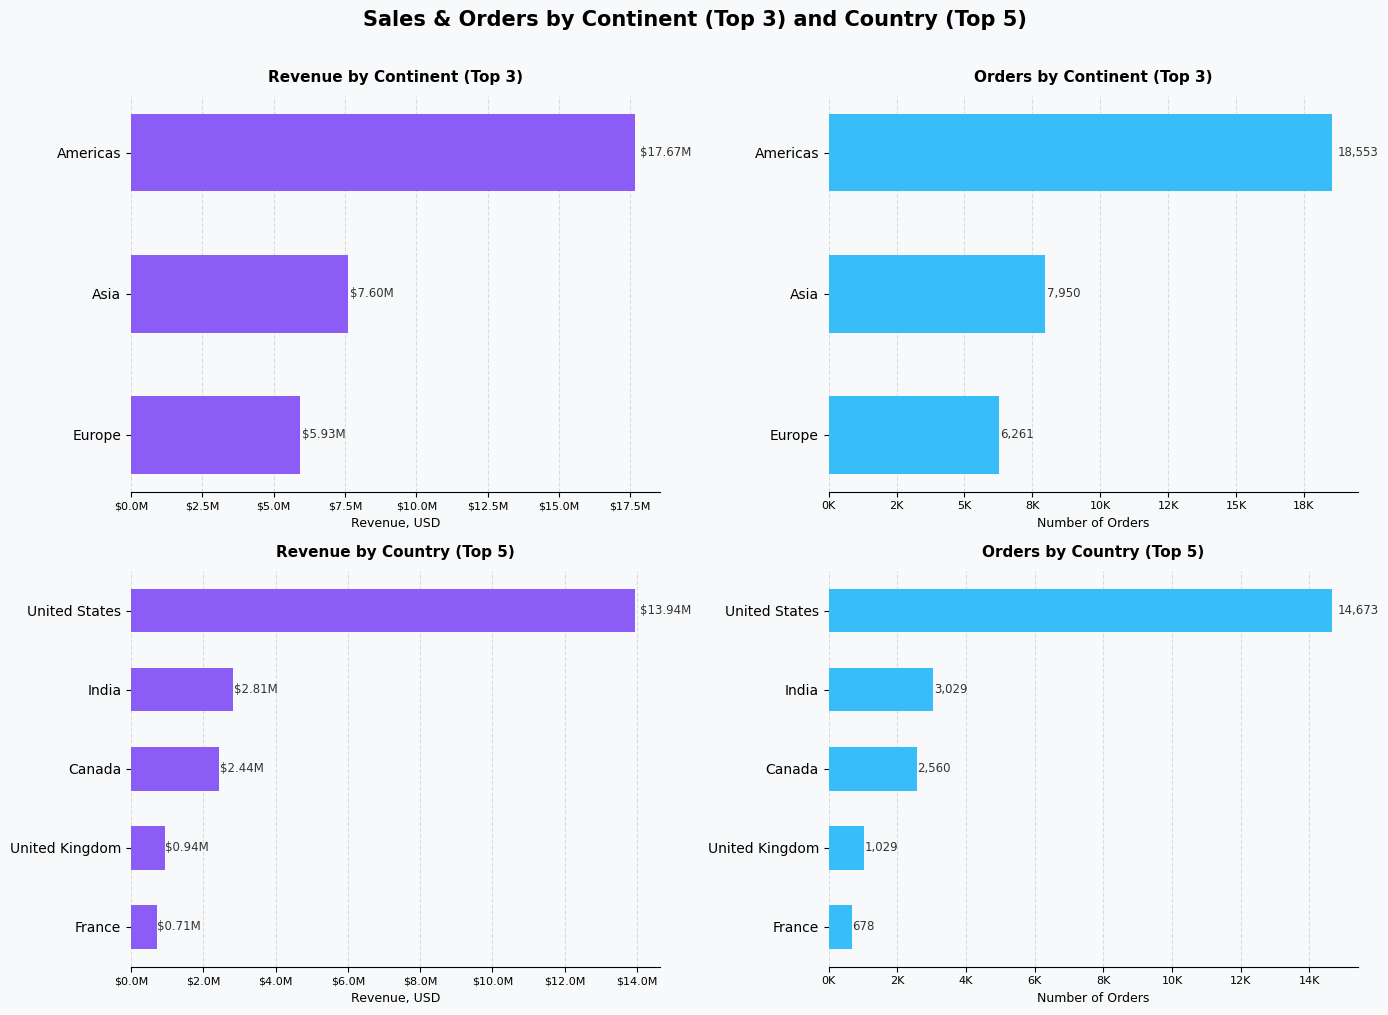

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Кольори проєкту
COLOR_REVENUE = "#8B5CF6"  # фіолетовий Revenue
COLOR_ORDERS  = "#38BDF8"  # блакитний Orders

# Підготовка даних
orders_df = df[df["product_name"].notna()].copy()

continent_sales  = orders_df.groupby("continent")["price"].sum().nlargest(3)
continent_orders = orders_df.groupby("continent")["session_id"].count().loc[continent_sales.index]

country_sales  = orders_df.groupby("country")["price"].sum().nlargest(5)
country_orders = orders_df.groupby("country")["session_id"].count().loc[country_sales.index]

# Фігура
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Sales & Orders by Continent (Top 3) and Country (Top 5)",
             fontsize=15, fontweight="bold", y=1.01)

fig.patch.set_facecolor("#F8F9FA")
for ax in axes.flat:
    ax.set_facecolor("#F8F9FA")

# Хелпер
def hbar(ax, index, values, color, title, xlabel):
    bars = ax.barh(index, values, color=color, height=0.55, zorder=2)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"${x/1e6:.1f}M" if "Revenue" in xlabel else f"{x/1e3:.0f}K"
    ))
    ax.grid(axis="x", linestyle="--", alpha=0.4, zorder=1)
    ax.spines[["top", "right", "left"]].set_visible(False)
    for bar, val in zip(bars, values):
        label = f"${val/1e6:.2f}M" if "Revenue" in xlabel else f"{val:,.0f}"
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                label, va="center", fontsize=8.5, color="#333")

# Графіки
hbar(axes[0, 0], continent_sales.index,  continent_sales.values,
     COLOR_REVENUE, "Revenue by Continent (Top 3)",  "Revenue, USD")

hbar(axes[0, 1], continent_orders.index, continent_orders.values,
     COLOR_ORDERS,  "Orders by Continent (Top 3)",   "Number of Orders")

hbar(axes[1, 0], country_sales.index,    country_sales.values,
     COLOR_REVENUE, "Revenue by Country (Top 5)",    "Revenue, USD")

hbar(axes[1, 1], country_orders.index,   country_orders.values,
     COLOR_ORDERS,  "Orders by Country (Top 5)",     "Number of Orders")

plt.tight_layout()
plt.savefig("sales_geography.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

Географічний розподіл продажів і замовлень демонструє чітку концентрацію активності в межах одного регіону.

На рівні континентів лідируючу позицію займає Америка, яка формує найбільшу частку як за обсягом продажів, так і за кількістю замовлень. Інші континенти суттєво поступаються за цими показниками, що підкреслює нерівномірність географічного попиту.

У розрізі країн топ-5 також очолюють ринки американського регіону, де зосереджені основні продажі та замовлення. Це вказує на високу концентрацію попиту в межах США та суміжних ринків і підтверджує домінуючу роль цього регіону у структурі бізнесу.


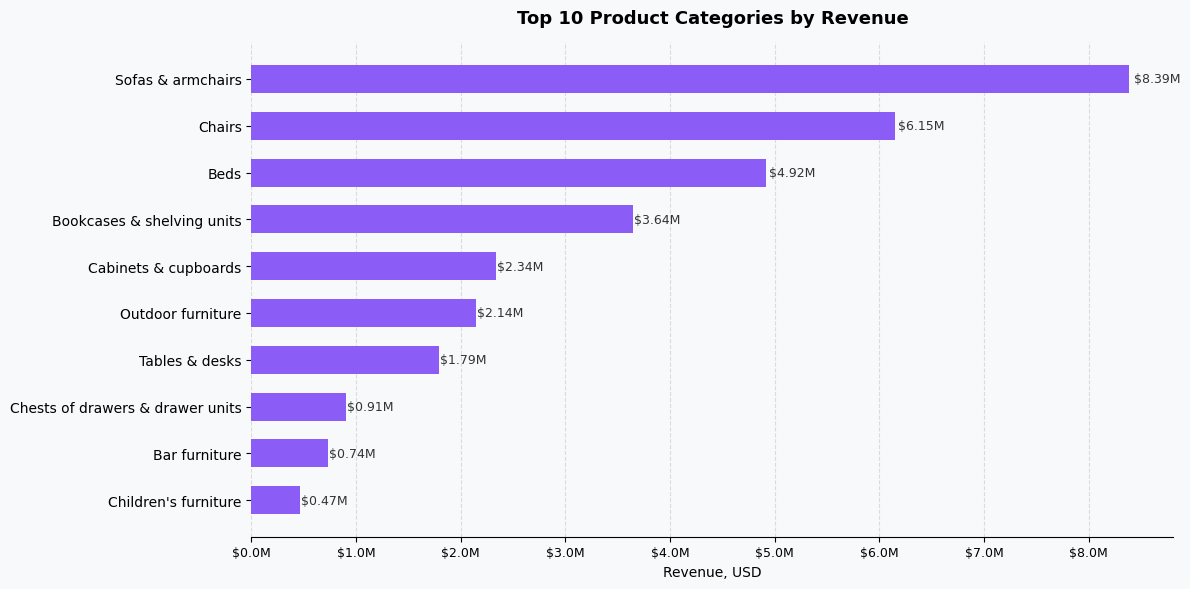

In [ ]:
# Кольори проєкту
COLOR_REVENUE = "#8B5CF6"  # фіолетовий Revenue
COLOR_ORDERS  = "#38BDF8"  # блакитний Orders

# Дані
top10_categories = (
    orders_df.groupby("product_category")["price"]
    .sum()
    .nlargest(10)
    .reset_index()
    .rename(columns={"price": "total_revenue"})
    .sort_values("total_revenue")
)

# Візуалізація
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

bars = ax.barh(top10_categories["product_category"],
               top10_categories["total_revenue"],
               color=COLOR_REVENUE, height=0.6, zorder=2)

ax.set_title("Top 10 Product Categories by Revenue",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Revenue, USD", fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.4, zorder=1)
ax.spines[["top", "right", "left"]].set_visible(False)

for bar, val in zip(bars, top10_categories["total_revenue"]):
    ax.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height() / 2,
            f"${val/1e6:.2f}M", va="center", fontsize=9, color="#333")

plt.tight_layout()
plt.savefig("top10_categories_revenue.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

Структура топ-10 категорій за загальною сумою продажів демонструє виражену концентрацію виручки в категоріях меблевого сегмента.

Лідируючу позицію займають «Дивани та крісла», що може бути пов’язано з високою середньою вартістю одиниці товару. Друге місце посідають «Стільці», а третє — «Ліжка», що формує стабільне ядро попиту в основних меблевих категоріях.

Найменший внесок у загальну виручку демонструє дитяча фурнітура, що може пояснюватися нижчим рівнем попиту або меншою середньою вартістю товарів у цій категорії.


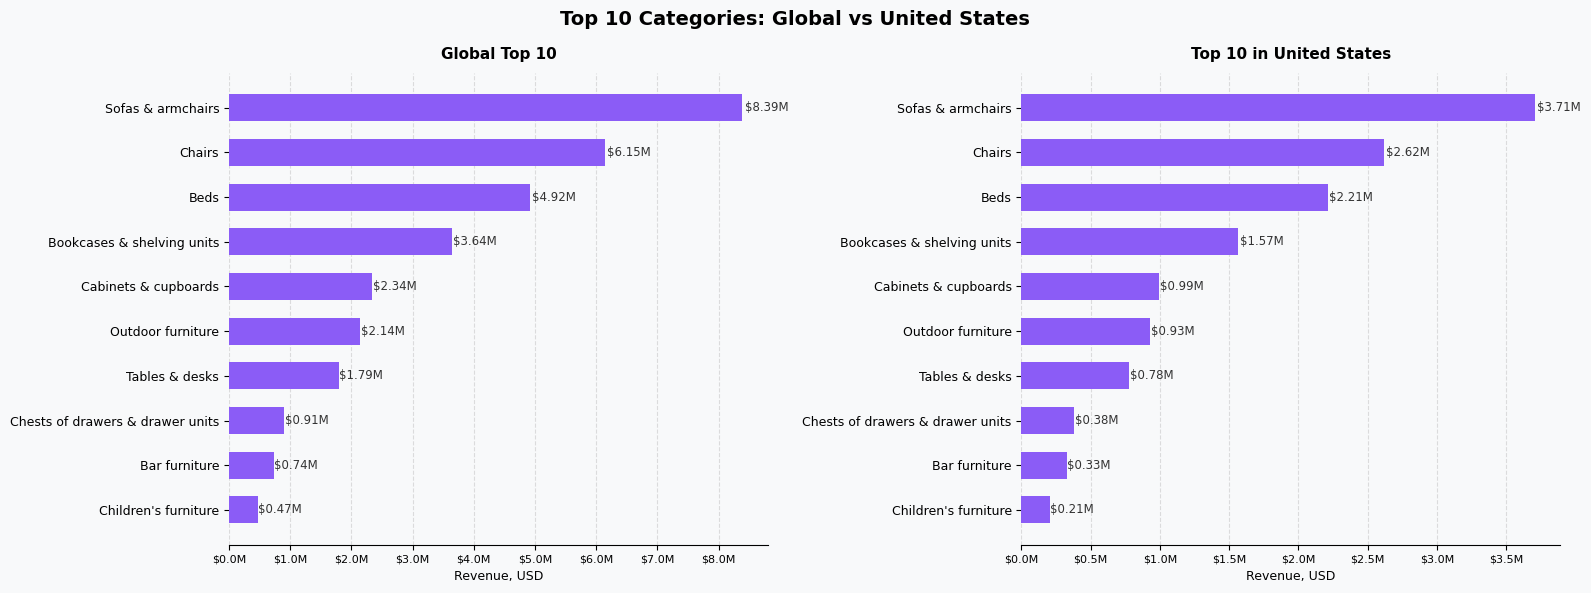

Top country by revenue: United States

Top 10 categories are identical globally and in the top country.


In [ ]:
# Країна з найбільшими продажами
top_country = orders_df.groupby("country")["price"].sum().idxmax()

# Топ-10 категорій: глобально vs топ-країна
global_top10 = (
    orders_df.groupby("product_category")["price"]
    .sum()
    .nlargest(10)
    .reset_index()
    .rename(columns={"price": "revenue"})
    .assign(rank_global=range(1, 11))
)

country_top10 = (
    orders_df[orders_df["country"] == top_country]
    .groupby("product_category")["price"]
    .sum()
    .nlargest(10)
    .reset_index()
    .rename(columns={"price": "revenue"})
    .assign(rank_country=range(1, 11))
)

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Top 10 Categories: Global vs {top_country}",
             fontsize=14, fontweight="bold")
fig.patch.set_facecolor("#F8F9FA")

def hbar_simple(ax, data, color, title):
    data_sorted = data.sort_values("revenue")
    bars = ax.barh(data_sorted["product_category"], data_sorted["revenue"],
                   color=color, height=0.6, zorder=2)
    ax.set_facecolor("#F8F9FA")
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("Revenue, USD", fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="x", linestyle="--", alpha=0.4, zorder=1)
    ax.spines[["top", "right", "left"]].set_visible(False)
    for bar, val in zip(bars, data_sorted["revenue"]):
        ax.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height() / 2,
                f"${val/1e6:.2f}M", va="center", fontsize=8.5, color="#333")

hbar_simple(axes[0], global_top10,  COLOR_REVENUE, "Global Top 10")
hbar_simple(axes[1], country_top10, COLOR_REVENUE, f"Top 10 in {top_country}")

plt.tight_layout()
plt.savefig("top10_categories_comparison.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Текстовий висновок
merged = global_top10[["product_category", "rank_global"]].merge(
    country_top10[["product_category", "rank_country"]],
    on="product_category", how="outer"
)

only_global  = merged[merged["rank_country"].isna()]["product_category"].tolist()
only_country = merged[merged["rank_global"].isna()]["product_category"].tolist()

print(f"Top country by revenue: {top_country}\n")

if only_global:
    print(f"In global top 10 but NOT in {top_country} top 10:")
    for c in only_global:
        print(f"  • {c}")

if only_country:
    print(f"\nIn {top_country} top 10 but NOT in global top 10:")
    for c in only_country:
        print(f"  • {c}")

if not only_global and not only_country:
    print("Top 10 categories are identical globally and in the top country.")

Розподіл топ-10 категорій у країні з найбільшими продажами загалом узгоджується з глобальною структурою попиту, без суттєвих відхилень.

Найбільш маржинальні та популярні категорії залишаються стабільними, і їх позиції у рейтингу не демонструють значних змін порівняно із загальною картиною продажів. Це вказує на те, що локальний ринок у країні-лідері повторює загальні споживчі патерни, а не формує окрему специфічну модель попиту.


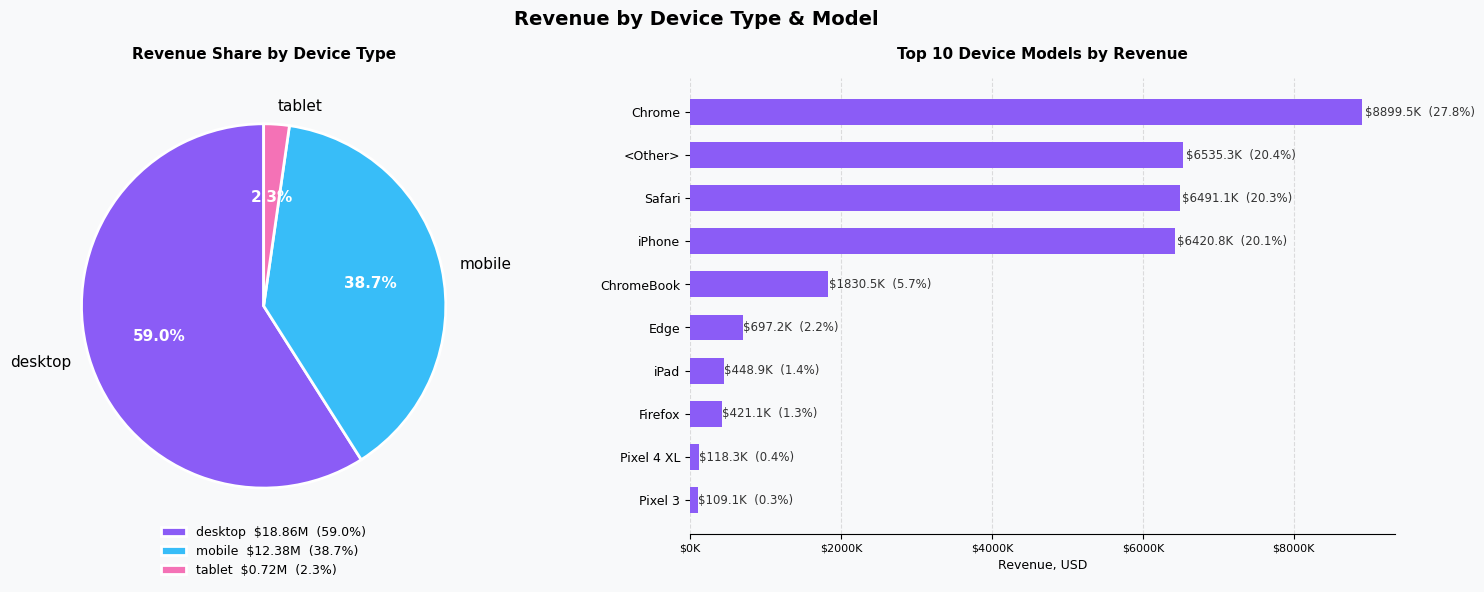

Revenue by device type:
  desktop      $18.86M  (59.0%)
  mobile       $12.38M  (38.7%)
  tablet       $0.72M  (2.3%)


In [ ]:
# Дані
total_revenue = orders_df["price"].sum()

# Продажі по типу девайсу
device_revenue = (
    orders_df.groupby("device")["price"]
    .sum()
    .reset_index()
    .rename(columns={"price": "revenue"})
    .assign(pct=lambda x: x["revenue"] / total_revenue * 100)
    .sort_values("revenue", ascending=False)
)

# Топ-10 моделей девайсів
model_revenue = (
    orders_df[orders_df["mobile_model_name"].notna() & (orders_df["mobile_model_name"] != "(not set)")]
    .groupby("mobile_model_name")["price"]
    .sum()
    .nlargest(10)
    .reset_index()
    .rename(columns={"price": "revenue"})
    .assign(pct=lambda x: x["revenue"] / total_revenue * 100)
    .sort_values("revenue")
)

# Фігура: 1 рядок × 2 колонки
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Revenue by Device Type & Model", fontsize=14, fontweight="bold")
fig.patch.set_facecolor("#F8F9FA")

# Лівий: пай-чарт по типу девайсу
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

pie_colors = [COLOR_REVENUE, COLOR_ORDERS, "#F472B6"]
wedges, texts, autotexts = ax1.pie(
    device_revenue["revenue"],
    labels=device_revenue["device"],
    autopct="%1.1f%%",
    colors=pie_colors[:len(device_revenue)],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
    at.set_color("white")

ax1.set_title("Revenue Share by Device Type", fontsize=11, fontweight="bold", pad=14)

# Легенда з абсолютними значеннями
legend_labels = [f"{row['device']}  ${row['revenue']/1e6:.2f}M  ({row['pct']:.1f}%)"
                 for _, row in device_revenue.iterrows()]
ax1.legend(wedges, legend_labels, loc="lower center",
           bbox_to_anchor=(0.5, -0.12), fontsize=9, frameon=False)

# Правий: горизонтальні бари по моделях
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

bars = ax2.barh(model_revenue["mobile_model_name"], model_revenue["revenue"],
                color=COLOR_REVENUE, height=0.6, zorder=2)

ax2.set_title("Top 10 Device Models by Revenue", fontsize=11, fontweight="bold", pad=14)
ax2.set_xlabel("Revenue, USD", fontsize=9)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax2.tick_params(axis="y", labelsize=9)
ax2.tick_params(axis="x", labelsize=8)
ax2.grid(axis="x", linestyle="--", alpha=0.4, zorder=1)
ax2.spines[["top", "right", "left"]].set_visible(False)

for bar, (_, row) in zip(bars, model_revenue.iterrows()):
    ax2.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height() / 2,
             f"${row['revenue']/1e3:.1f}K  ({row['pct']:.1f}%)",
             va="center", fontsize=8.5, color="#333")

plt.tight_layout()
plt.savefig("revenue_by_device.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Текстовий висновок
print("Revenue by device type:")
for _, row in device_revenue.iterrows():
    print(f"  {row['device']:<12} ${row['revenue']/1e6:.2f}M  ({row['pct']:.1f}%)")

Розподіл продажів за типами та моделями пристроїв залишається стабільним протягом аналізованого періоду. Домінуючу частку формують покупки, здійснені з desktop-пристроїв, що свідчить про їх ключову роль у загальній структурі продажів і відсутність суттєвих змін у поведінці користувачів за цим параметром.


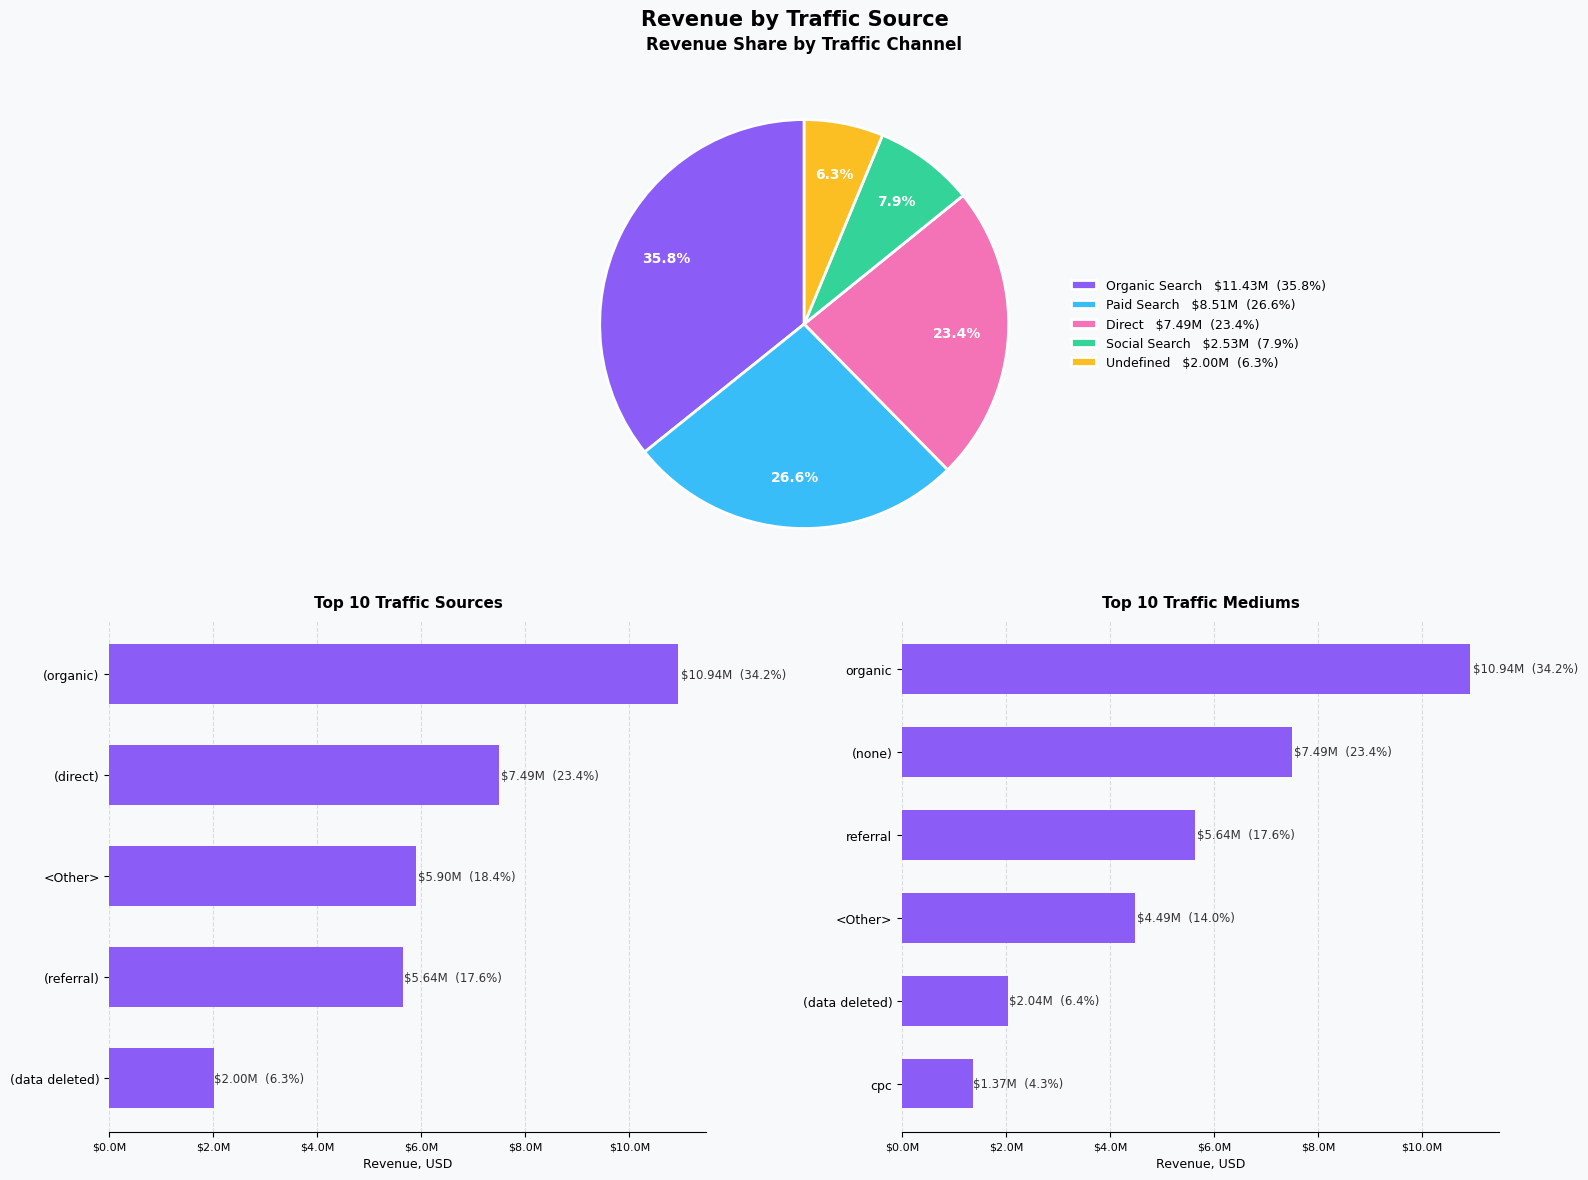

Revenue by traffic channel:
  Organic Search       $11.43M  (35.8%)
  Paid Search          $8.51M  (26.6%)
  Direct               $7.49M  (23.4%)
  Social Search        $2.53M  (7.9%)
  Undefined            $2.00M  (6.3%)


In [ ]:
#  Дані
total_revenue = orders_df["price"].sum()

# По каналу трафіку
channel_revenue = (
    orders_df.groupby("traffic_channel")["price"]
    .sum()
    .reset_index()
    .rename(columns={"price": "revenue"})
    .assign(pct=lambda x: x["revenue"] / total_revenue * 100)
    .sort_values("revenue", ascending=False)
)

# По джерелу трафіку — топ-10
source_revenue = (
    orders_df.groupby("traffic_source")["price"]
    .sum()
    .nlargest(10)
    .reset_index()
    .rename(columns={"price": "revenue"})
    .assign(pct=lambda x: x["revenue"] / total_revenue * 100)
    .sort_values("revenue")
)

# По medium — топ-10
medium_revenue = (
    orders_df.groupby("traffic_medium")["price"]
    .sum()
    .nlargest(10)
    .reset_index()
    .rename(columns={"price": "revenue"})
    .assign(pct=lambda x: x["revenue"] / total_revenue * 100)
    .sort_values("revenue")
)

# Фігура: 2 рядки × 2 колонки
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Revenue by Traffic Source", fontsize=15, fontweight="bold")
fig.patch.set_facecolor("#F8F9FA")

ax_pie    = fig.add_subplot(2, 2, (1, 2))
ax_source = fig.add_subplot(2, 2, 3)
ax_medium = fig.add_subplot(2, 2, 4)

for ax in [ax_pie, ax_source, ax_medium]:
    ax.set_facecolor("#F8F9FA")

# Пай-чарт: канали
n = len(channel_revenue)
pie_colors = [
    "#8B5CF6", "#38BDF8", "#F472B6", "#34D399", "#FBBF24",
    "#F87171", "#A78BFA", "#22D3EE", "#FB923C", "#4ADE80"
][:n]

wedges, texts, autotexts = ax_pie.pie(
    channel_revenue["revenue"],
    labels=None,
    autopct="%1.1f%%",
    colors=pie_colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight("bold")
    at.set_color("white")

ax_pie.set_title("Revenue Share by Traffic Channel", fontsize=12,
                 fontweight="bold", pad=14)

legend_labels = [
    f"{row['traffic_channel']}   ${row['revenue']/1e6:.2f}M  ({row['pct']:.1f}%)"
    for _, row in channel_revenue.iterrows()
]
ax_pie.legend(wedges, legend_labels,
              loc="center left", bbox_to_anchor=(1.0, 0.5),
              fontsize=9, frameon=False)

# Бари: топ-10 джерел
def hbar_pct(ax, data, col_name, title):
    bars = ax.barh(data[col_name], data["revenue"],
                   color=COLOR_REVENUE, height=0.6, zorder=2)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("Revenue, USD", fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="x", linestyle="--", alpha=0.4, zorder=1)
    ax.spines[["top", "right", "left"]].set_visible(False)
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height() / 2,
                f"${row['revenue']/1e6:.2f}M  ({row['pct']:.1f}%)",
                va="center", fontsize=8.5, color="#333")

hbar_pct(ax_source, source_revenue, "traffic_source", "Top 10 Traffic Sources")
hbar_pct(ax_medium, medium_revenue, "traffic_medium", "Top 10 Traffic Mediums")

plt.tight_layout()
plt.savefig("revenue_by_traffic.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Текстовий висновок
print("Revenue by traffic channel:")
for _, row in channel_revenue.iterrows():
    print(f"  {row['traffic_channel']:<20} ${row['revenue']/1e6:.2f}M  ({row['pct']:.1f}%)")

Структура доходів за джерелами трафіку демонструє, що основну частку виручки формує органічний канал, що може включати пошуковий трафік, соціальні мережі, контент або рекомендаційні переходи.

Другим за значущістю є платний трафік, що свідчить про активну присутність performance-маркетингу. Ймовірно, компанія використовує рекламні інструменти Meta (Facebook/Instagram Ads) або інші платформи для залучення аудиторії та масштабування продажів.

У сукупності розподіл каналів вказує на збалансовану модель залучення користувачів, де органічний попит підсилюється платними кампаніями, а контент і реклама працюють у зв’язці.


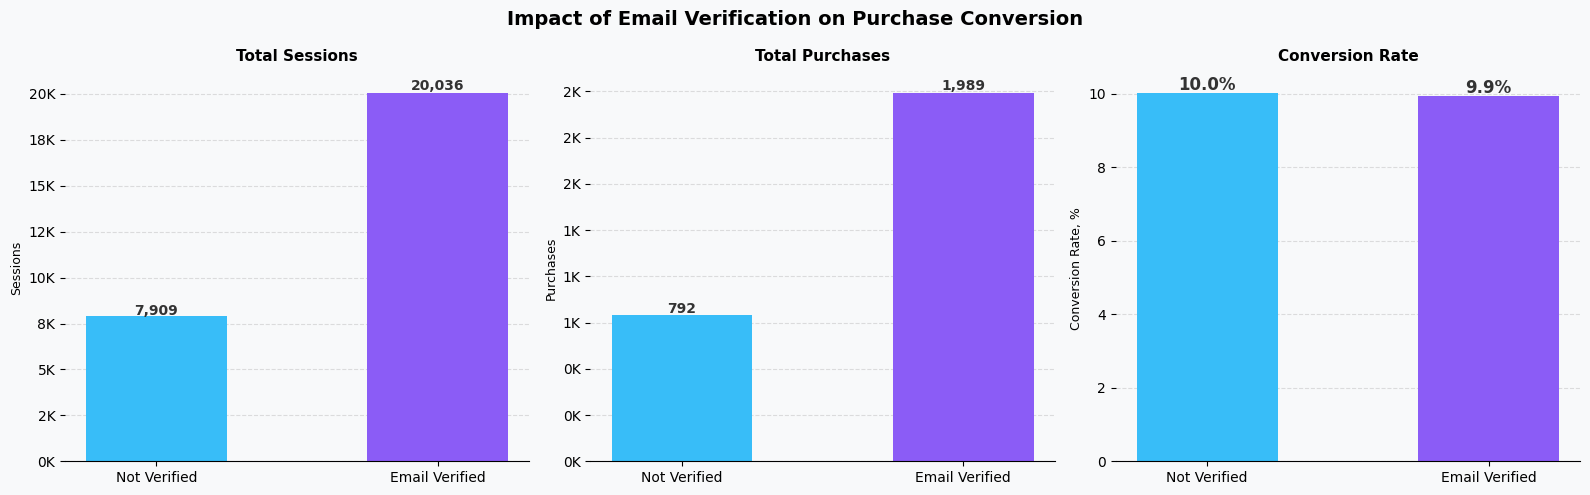

Email Verified   — CR: 9.9%  (1,989 purchases / 20,036 sessions)
Not Verified     — CR: 10.0%  (792 purchases / 7,909 sessions)

Verified users convert 0.1pp less than unverified.


In [ ]:
# Дані
registered = df[df["registered_user_id"].notna()].copy()

conversion = (
    registered.groupby("is_email_verified")
    .agg(
        total_sessions  =("session_id",    "nunique"),
        total_purchases =("product_name",  lambda x: x.notna().sum())
    )
    .reset_index()
    .assign(
        conversion_rate=lambda x: x["total_purchases"] / x["total_sessions"] * 100,
        label=lambda x: x["is_email_verified"].map({1: "Email Verified", 0: "Not Verified"})
    )
)

# Фігура: 1 рядок × 3 колонки
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Impact of Email Verification on Purchase Conversion",
             fontsize=14, fontweight="bold")
fig.patch.set_facecolor("#F8F9FA")
for ax in axes:
    ax.set_facecolor("#F8F9FA")

bar_colors = [COLOR_ORDERS, COLOR_REVENUE]

axes[0].bar(conversion["label"], conversion["total_sessions"],
            color=bar_colors, width=0.5, zorder=2)
axes[0].set_title("Total Sessions", fontsize=11, fontweight="bold", pad=10)
axes[0].set_ylabel("Sessions", fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[0].grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
axes[0].spines[["top", "right", "left"]].set_visible(False)
for i, (_, row) in enumerate(conversion.iterrows()):
    axes[0].text(i, row["total_sessions"] * 1.01,
                 f"{row['total_sessions']:,.0f}",
                 ha="center", fontsize=10, fontweight="bold", color="#333")

axes[1].bar(conversion["label"], conversion["total_purchases"],
            color=bar_colors, width=0.5, zorder=2)
axes[1].set_title("Total Purchases", fontsize=11, fontweight="bold", pad=10)
axes[1].set_ylabel("Purchases", fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[1].grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
axes[1].spines[["top", "right", "left"]].set_visible(False)
for i, (_, row) in enumerate(conversion.iterrows()):
    axes[1].text(i, row["total_purchases"] * 1.01,
                 f"{row['total_purchases']:,.0f}",
                 ha="center", fontsize=10, fontweight="bold", color="#333")

axes[2].bar(conversion["label"], conversion["conversion_rate"],
            color=bar_colors, width=0.5, zorder=2)
axes[2].set_title("Conversion Rate", fontsize=11, fontweight="bold", pad=10)
axes[2].set_ylabel("Conversion Rate, %", fontsize=9)
axes[2].grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
axes[2].spines[["top", "right", "left"]].set_visible(False)
for i, (_, row) in enumerate(conversion.iterrows()):
    axes[2].text(i, row["conversion_rate"] * 1.01,
                 f"{row['conversion_rate']:.1f}%",
                 ha="center", fontsize=12, fontweight="bold", color="#333")

plt.tight_layout()
plt.savefig("email_verification_conversion.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Текстовий висновок
v  = conversion[conversion["is_email_verified"] == 1].iloc[0]
nv = conversion[conversion["is_email_verified"] == 0].iloc[0]
diff = v["conversion_rate"] - nv["conversion_rate"]

print(f"Email Verified   — CR: {v['conversion_rate']:.1f}%  ({v['total_purchases']:,.0f} purchases / {v['total_sessions']:,.0f} sessions)")
print(f"Not Verified     — CR: {nv['conversion_rate']:.1f}%  ({nv['total_purchases']:,.0f} purchases / {nv['total_sessions']:,.0f} sessions)")
print(f"\nVerified users convert {abs(diff):.1f}pp {'more' if diff > 0 else 'less'} than unverified.")

Відсоток зареєстрованих користувачів що підтвердив свою електронну адресу

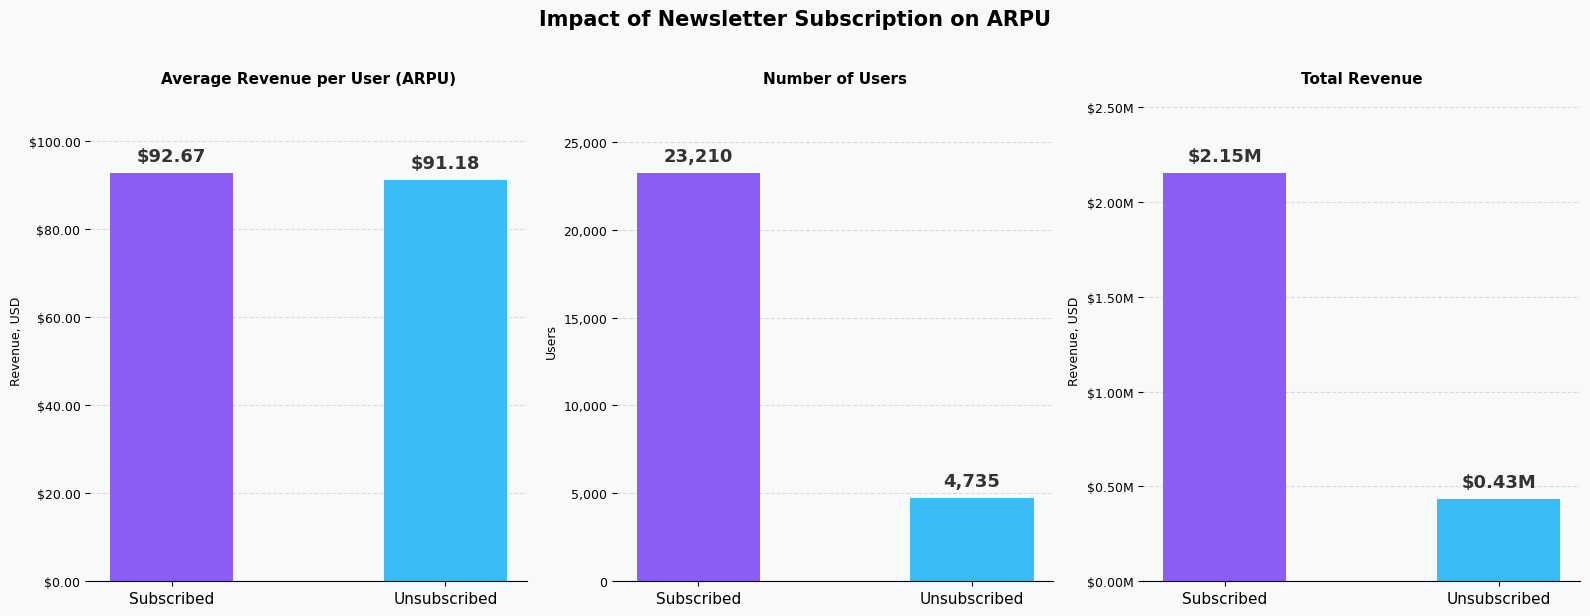

Subscribed   — ARPU: $92.67  |  Users: 23,210  |  Total rev: $2.15M
Unsubscribed — ARPU: $91.18  |  Users: 4,735  |  Total rev: $0.43M

Subscribed users bring 1.6% more revenue per user than unsubscribed.


In [ ]:
# Дані
# Беремо тільки зареєстрованих користувачів
registered_orders = df[df["registered_user_id"].notna()].copy()

arpu = (
    registered_orders.groupby(["registered_user_id", "is_unsubscribed"])
    .agg(total_revenue=("price", "sum"))
    .reset_index()
    .groupby("is_unsubscribed")
    .agg(
        arpu        =("total_revenue", "mean"),
        total_users =("registered_user_id", "nunique"),
        total_rev   =("total_revenue", "sum")
    )
    .reset_index()
    .assign(label=lambda x: x["is_unsubscribed"].map({0: "Subscribed", 1: "Unsubscribed"}))
)

# Фігура
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Impact of Newsletter Subscription on ARPU",
             fontsize=15, fontweight="bold", y=1.02)
fig.patch.set_facecolor("#F8F9FA")
for ax in axes:
    ax.set_facecolor("#F8F9FA")

bar_colors = [COLOR_REVENUE, COLOR_ORDERS]  # subscribed=фіолетовий, unsubscribed=блакитний

def styled_bar(ax, labels, values, colors, title, ylabel, fmt_func):
    bars = ax.bar(labels, values, color=colors, width=0.45, zorder=2)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=12)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_func))
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
    ax.spines[["top", "right", "left"]].set_visible(False)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.02,
                fmt_func(val, None),
                ha="center", va="bottom",
                fontsize=13, fontweight="bold", color="#333")

    ax.set_ylim(0, max(values) * 1.18)

# ARPU
styled_bar(
    axes[0],
    arpu["label"], arpu["arpu"],
    bar_colors,
    "Average Revenue per User (ARPU)",
    "Revenue, USD",
    lambda x, _: f"${x:,.2f}"
)

# Кількість користувачів
styled_bar(
    axes[1],
    arpu["label"], arpu["total_users"],
    bar_colors,
    "Number of Users",
    "Users",
    lambda x, _: f"{x:,.0f}"
)

# Загальний дохід
styled_bar(
    axes[2],
    arpu["label"], arpu["total_rev"],
    bar_colors,
    "Total Revenue",
    "Revenue, USD",
    lambda x, _: f"${x/1e6:.2f}M"
)

plt.tight_layout()
plt.savefig("arpu_subscription.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Текстовий висновок
sub   = arpu[arpu["is_unsubscribed"] == 0].iloc[0]
unsub = arpu[arpu["is_unsubscribed"] == 1].iloc[0]
diff  = sub["arpu"] - unsub["arpu"]
diff_pct = diff / unsub["arpu"] * 100

print(f"Subscribed   — ARPU: ${sub['arpu']:,.2f}  |  Users: {sub['total_users']:,.0f}  |  Total rev: ${sub['total_rev']/1e6:.2f}M")
print(f"Unsubscribed — ARPU: ${unsub['arpu']:,.2f}  |  Users: {unsub['total_users']:,.0f}  |  Total rev: ${unsub['total_rev']/1e6:.2f}M")
print(f"\nSubscribed users bring {abs(diff_pct):.1f}% {'more' if diff > 0 else 'less'} revenue per user than unsubscribed.")

Аналіз показує наявність зв’язку між підпискою на розсилку та середнім доходом користувача (ARPU). Користувачі, які підписані на розсилку, демонструють вищі значення ARPU порівняно з тими, хто не має підписки, що свідчить про позитивний вплив комунікації через email-канал на монетизацію аудиторії.


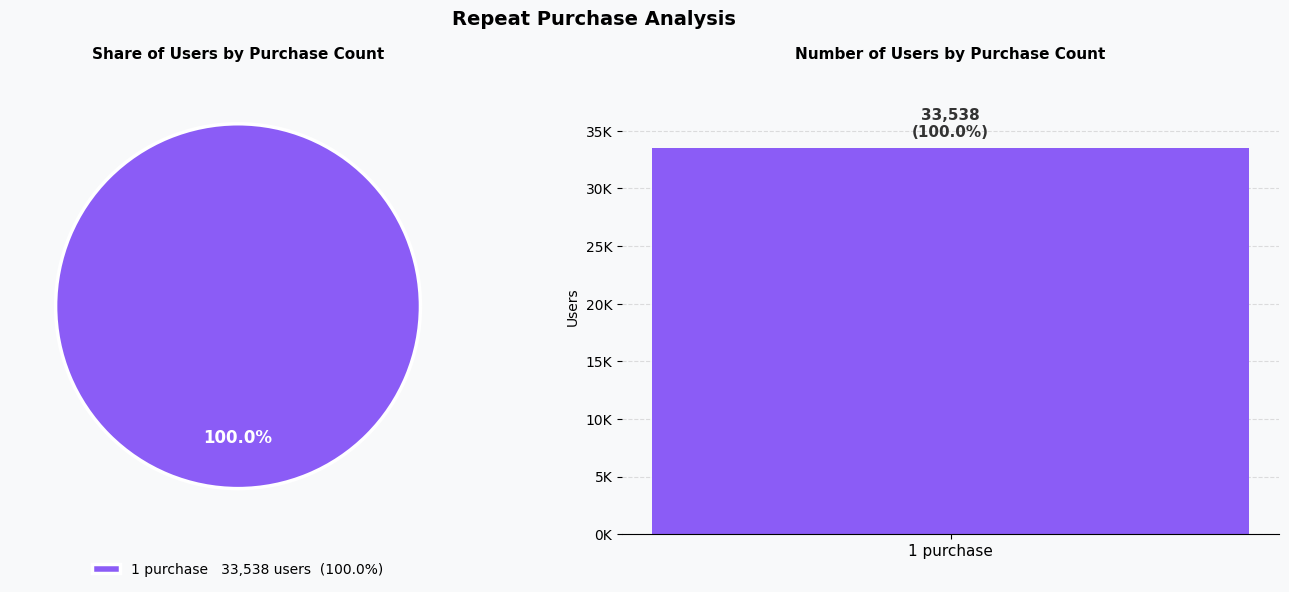

Total sessions with purchases : 33,538
Sessions with repeat purchases: 0  (0.0%)


In [ ]:
# Дані
user_purchases = (
    df[df["product_name"].notna()]
    .groupby("session_id")["product_name"]
    .count()
    .reset_index()
    .rename(columns={"product_name": "purchase_count"})
)

purchase_segments = user_purchases["purchase_count"].apply(
    lambda x: "1 purchase" if x == 1 else "2 purchases" if x == 2 else "3+ purchases"
)

segments = purchase_segments.value_counts().reset_index()
segments.columns = ["segment", "users"]
segments["pct"] = segments["users"] / segments["users"].sum() * 100

order_map = {"1 purchase": 0, "2 purchases": 1, "3+ purchases": 2}
segments = segments.sort_values("segment", key=lambda x: x.map(order_map))

# Фігура
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Repeat Purchase Analysis", fontsize=14, fontweight="bold")
fig.patch.set_facecolor("#F8F9FA")
for ax in axes:
    ax.set_facecolor("#F8F9FA")

pie_colors = [COLOR_REVENUE, COLOR_ORDERS, "#F472B6"]

# Лівий: пай-чарт
wedges, texts, autotexts = axes[0].pie(
    segments["pct"],
    labels=None,
    autopct="%1.1f%%",
    colors=pie_colors[:len(segments)],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2.5},
    pctdistance=0.72
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")
    at.set_color("white")

axes[0].set_title("Share of Users by Purchase Count",
                  fontsize=11, fontweight="bold", pad=14)

legend_labels = [
    f"{row['segment']}   {row['users']:,} users  ({row['pct']:.1f}%)"
    for _, row in segments.iterrows()
]
axes[0].legend(wedges, legend_labels,
               loc="lower center", bbox_to_anchor=(0.5, -0.12),
               fontsize=10, frameon=False)

# Правий: бари з абсолютними значеннями
bars = axes[1].bar(segments["segment"], segments["users"],
                   color=pie_colors[:len(segments)], width=0.5, zorder=2)

axes[1].set_title("Number of Users by Purchase Count",
                  fontsize=11, fontweight="bold", pad=14)
axes[1].set_ylabel("Users", fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[1].tick_params(axis="x", labelsize=11)
axes[1].grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
axes[1].spines[["top", "right", "left"]].set_visible(False)
axes[1].set_ylim(0, segments["users"].max() * 1.18)

for bar, (_, row) in zip(bars, segments.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + segments["users"].max() * 0.02,
                 f"{row['users']:,}\n({row['pct']:.1f}%)",
                 ha="center", va="bottom",
                 fontsize=11, fontweight="bold", color="#333")

plt.tight_layout()
plt.savefig("repeat_purchases.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Текстовий висновок
repeat = segments[segments["segment"] != "1 purchase"]["users"].sum()
total  = segments["users"].sum()
print(f"Total sessions with purchases : {total:,}")
print(f"Sessions with repeat purchases: {repeat:,}  ({repeat/total*100:.1f}%)")

Частка повторних покупок у вибірці становить 0%. Дані свідчать про відсутність повторної активності з боку клієнтів, що може вказувати на недостатній рівень утримання аудиторії та обмежену ефективність механік, спрямованих на стимулювання повторних транзакцій.


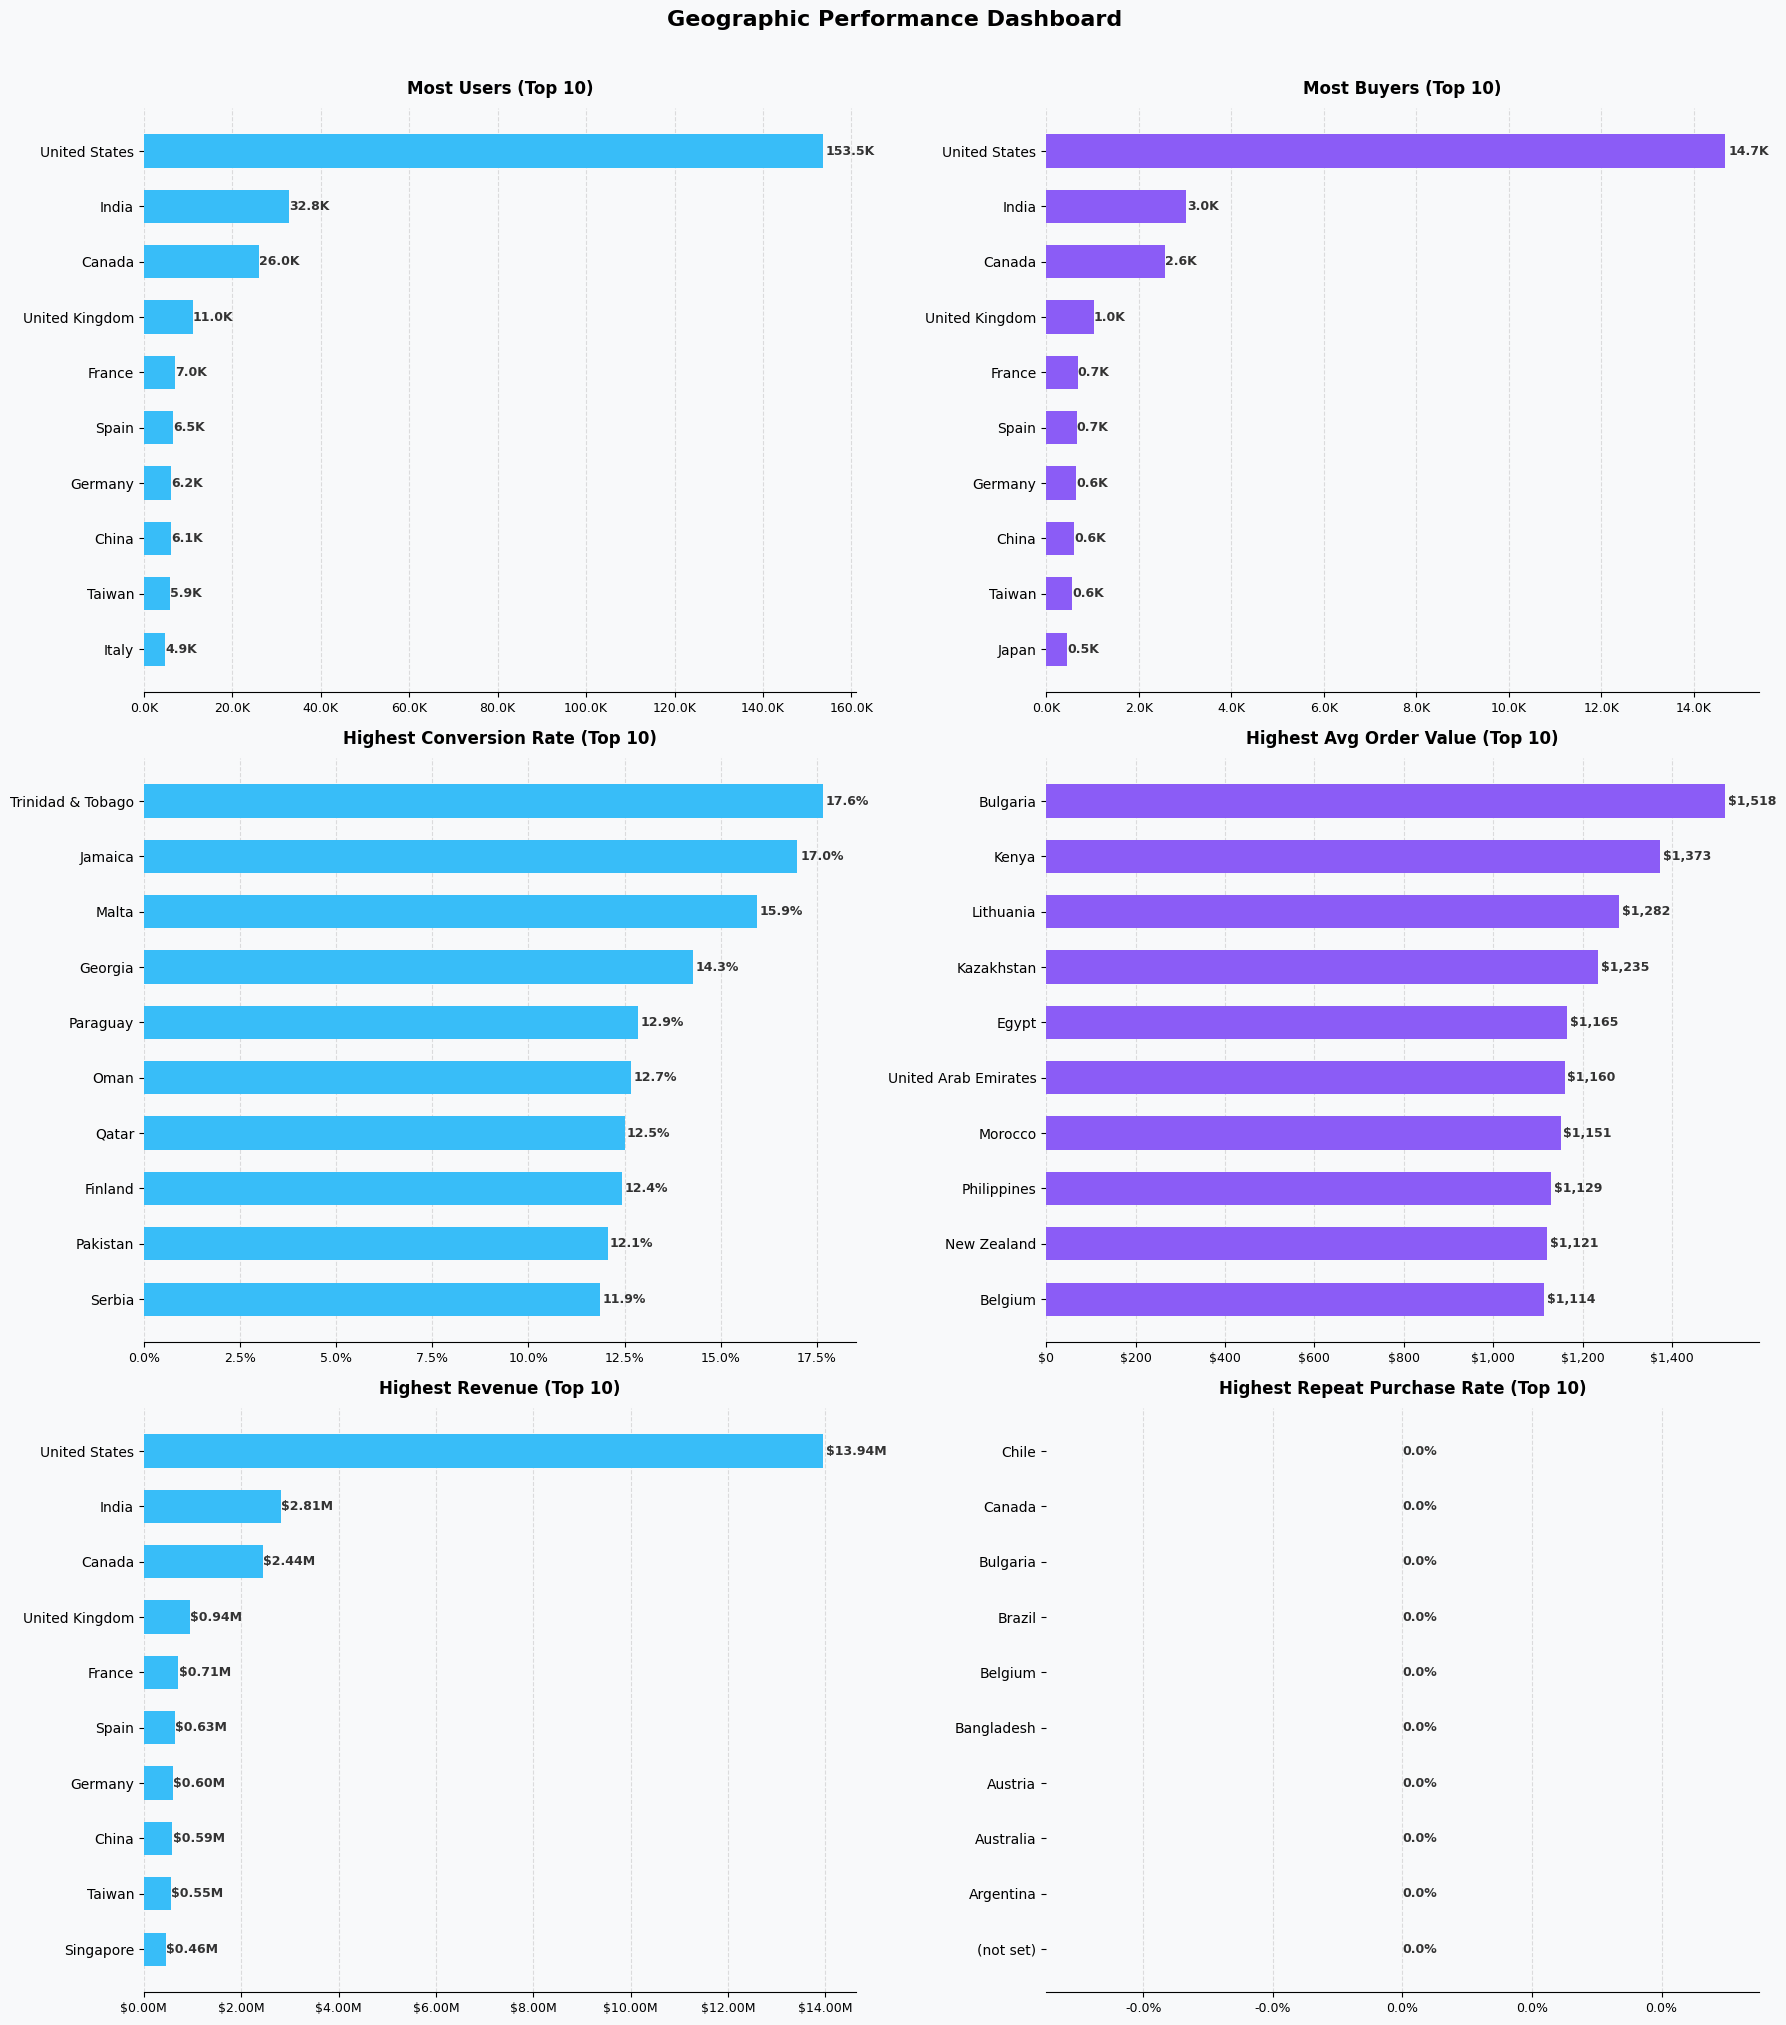

In [ ]:
# Дані
total_sessions = df["session_id"].nunique()

geo = (
    df.groupby("country")
    .agg(
        users      =("session_id",    "nunique"),
        buyers     =("product_name",  lambda x: x.notna().sum()),
        revenue    =("price",         "sum"),
        avg_check  =("price",         "mean")
    )
    .reset_index()
    .assign(
        conversion =lambda x: x["buyers"]  / x["users"] * 100,
        users_pct  =lambda x: x["users"]   / total_sessions * 100,
    )
)

# Топ-10 по кожній метриці
top_users      = geo.nlargest(10, "users")
top_buyers     = geo.nlargest(10, "buyers")
top_conversion = geo[geo["users"] >= 50].nlargest(10, "conversion")  # фільтр щоб не було 100% з 1 сесії
top_avg_check  = geo[geo["buyers"] >= 20].nlargest(10, "avg_check")
top_revenue    = geo.nlargest(10, "revenue")

# Повторні покупці на рівні країни
repeat = (
    df[df["product_name"].notna()]
    .groupby(["country", "session_id"])["product_name"]
    .count()
    .reset_index()
    .rename(columns={"product_name": "items"})
    .groupby("country")
    .agg(
        total_sessions  =("session_id", "nunique"),
        repeat_sessions =("items",      lambda x: (x > 1).sum())
    )
    .reset_index()
    .assign(repeat_pct=lambda x: x["repeat_sessions"] / x["total_sessions"] * 100)
    .query("total_sessions >= 20")
    .nlargest(10, "repeat_pct")
)

# Фігура: 3×2
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.suptitle("Geographic Performance Dashboard", fontsize=16, fontweight="bold", y=1.01)
fig.patch.set_facecolor("#F8F9FA")
for ax in axes.flat:
    ax.set_facecolor("#F8F9FA")

def geo_bar(ax, data, col, title, fmt_func, color):
    data_s = data.sort_values(col)
    bars = ax.barh(data_s["country"], data_s[col], color=color, height=0.6, zorder=2)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_func))
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=9)
    ax.grid(axis="x", linestyle="--", alpha=0.4, zorder=1)
    ax.spines[["top", "right", "left"]].set_visible(False)
    for bar, (_, row) in zip(bars, data_s.iterrows()):
        ax.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height() / 2,
                fmt_func(row[col], None),
                va="center", fontsize=9, fontweight="bold", color="#333")

geo_bar(axes[0, 0], top_users,      "users",      "Most Users (Top 10)",
        lambda x, _: f"{x/1e3:.1f}K",   COLOR_ORDERS)

geo_bar(axes[0, 1], top_buyers,     "buyers",     "Most Buyers (Top 10)",
        lambda x, _: f"{x/1e3:.1f}K",   COLOR_REVENUE)

geo_bar(axes[1, 0], top_conversion, "conversion", "Highest Conversion Rate (Top 10)",
        lambda x, _: f"{x:.1f}%",        COLOR_ORDERS)

geo_bar(axes[1, 1], top_avg_check,  "avg_check",  "Highest Avg Order Value (Top 10)",
        lambda x, _: f"${x:,.0f}",       COLOR_REVENUE)

geo_bar(axes[2, 0], top_revenue,    "revenue",    "Highest Revenue (Top 10)",
        lambda x, _: f"${x/1e6:.2f}M",  COLOR_ORDERS)

geo_bar(axes[2, 1], repeat,         "repeat_pct", "Highest Repeat Purchase Rate (Top 10)",
        lambda x, _: f"{x:.1f}%",        COLOR_REVENUE)

plt.tight_layout()
plt.savefig("geo_dashboard.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

Географічний аналіз показав виражену концентрацію ключових метрик у різних регіонах.

Найбільша кількість користувачів та покупців зафіксована у США, які також формують основний обсяг виручки компанії. Водночас найвищий рівень конверсії в покупку спостерігається в Тринідаді і Тобаго, що може свідчити про невелику, але дуже ефективну аудиторію.

Максимальний середній чек характерний для Болгарії, що вказує на високу цінність окремих транзакцій у цьому регіоні.

Дані щодо повторних покупок відсутні, тому оцінити лояльність клієнтів у часовому вимірі наразі неможливо.


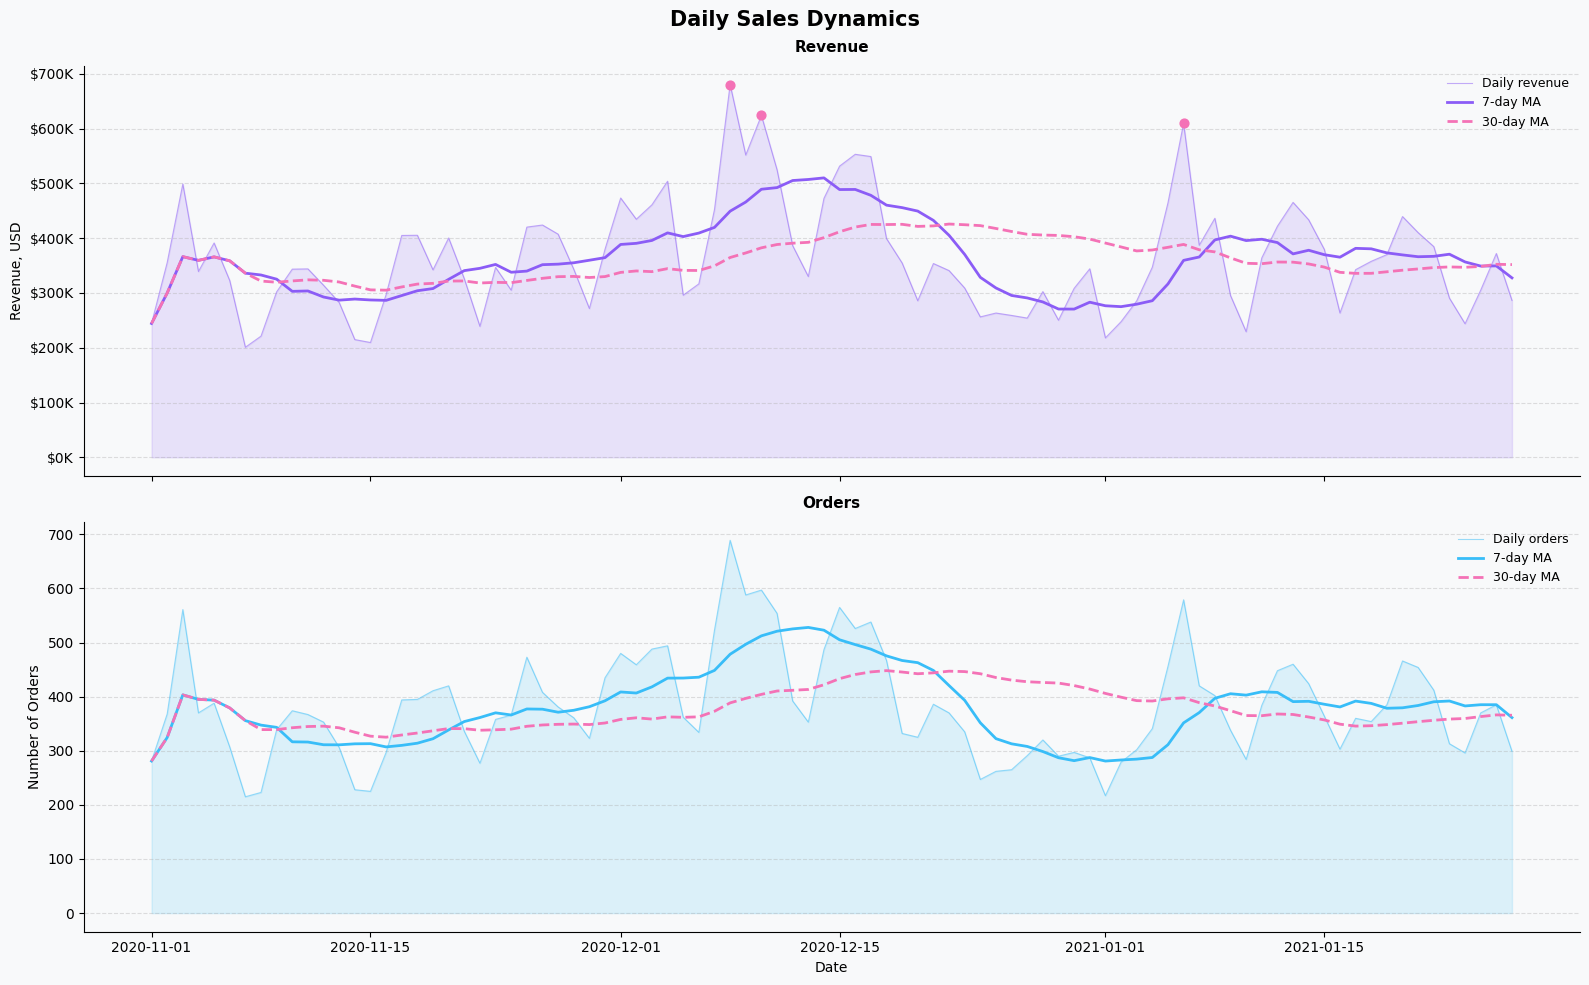

Period       : 2020-11-01 → 2021-01-27
Total days   : 88
Total revenue: $31.97M
Avg daily rev: $363,315  |  std: $100,327
Best day     : 2020-12-08  —  $680,510
Worst day    : 2020-11-07  —  $200,892
Spike days   : 3 days above mean + 2σ


In [ ]:
# Дані
daily_sales = (
    orders_df.groupby("order_date")
    .agg(
        revenue =("price",      "sum"),
        orders  =("session_id", "nunique")
    )
    .reset_index()
    .sort_values("order_date")
    .assign(
        revenue_7d =lambda x: x["revenue"].rolling(7,  min_periods=1).mean(),
        revenue_30d=lambda x: x["revenue"].rolling(30, min_periods=1).mean(),
    )
)

# Фігура: 2 рядки
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle("Daily Sales Dynamics", fontsize=15, fontweight="bold")
fig.patch.set_facecolor("#F8F9FA")
for ax in axes:
    ax.set_facecolor("#F8F9FA")

# Верхній: виручка
axes[0].fill_between(daily_sales["order_date"], daily_sales["revenue"],
                     alpha=0.15, color=COLOR_REVENUE)
axes[0].plot(daily_sales["order_date"], daily_sales["revenue"],
             color=COLOR_REVENUE, linewidth=0.8, alpha=0.5, label="Daily revenue")
axes[0].plot(daily_sales["order_date"], daily_sales["revenue_7d"],
             color=COLOR_REVENUE, linewidth=2, label="7-day MA")
axes[0].plot(daily_sales["order_date"], daily_sales["revenue_30d"],
             color="#F472B6", linewidth=2, linestyle="--", label="30-day MA")

axes[0].set_title("Revenue", fontsize=11, fontweight="bold", pad=10)
axes[0].set_ylabel("Revenue, USD", fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].legend(fontsize=9, frameon=False)

# Аномалії — дні з виручкою вище 2σ
mean_r = daily_sales["revenue"].mean()
std_r  = daily_sales["revenue"].std()
spikes = daily_sales[daily_sales["revenue"] > mean_r + 2 * std_r]
axes[0].scatter(spikes["order_date"], spikes["revenue"],
                color="#F472B6", zorder=5, s=40, label="Spike (>2σ)")

# Нижній: кількість замовлень
axes[1].fill_between(daily_sales["order_date"], daily_sales["orders"],
                     alpha=0.15, color=COLOR_ORDERS)
axes[1].plot(daily_sales["order_date"], daily_sales["orders"],
             color=COLOR_ORDERS, linewidth=0.8, alpha=0.5, label="Daily orders")
axes[1].plot(daily_sales["order_date"],
             daily_sales["orders"].rolling(7, min_periods=1).mean(),
             color=COLOR_ORDERS, linewidth=2, label="7-day MA")
axes[1].plot(daily_sales["order_date"],
             daily_sales["orders"].rolling(30, min_periods=1).mean(),
             color="#F472B6", linewidth=2, linestyle="--", label="30-day MA")

axes[1].set_title("Orders", fontsize=11, fontweight="bold", pad=10)
axes[1].set_ylabel("Number of Orders", fontsize=10)
axes[1].set_xlabel("Date", fontsize=10)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("daily_sales_dynamics.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Текстовий висновок
print(f"Period       : {daily_sales['order_date'].min()} → {daily_sales['order_date'].max()}")
print(f"Total days   : {len(daily_sales):,}")
print(f"Total revenue: ${daily_sales['revenue'].sum()/1e6:.2f}M")
print(f"Avg daily rev: ${mean_r:,.0f}  |  std: ${std_r:,.0f}")
print(f"Best day     : {daily_sales.loc[daily_sales['revenue'].idxmax(), 'order_date']}  —  ${daily_sales['revenue'].max():,.0f}")
print(f"Worst day    : {daily_sales.loc[daily_sales['revenue'].idxmin(), 'order_date']}  —  ${daily_sales['revenue'].min():,.0f}")
print(f"Spike days   : {len(spikes)} days above mean + 2σ")

Динаміка загальних продажів у розрізі дат не демонструє системних відхилень або стійких трендів. Значення коливаються в межах типового діапазону без виражених пікових навантажень чи тривалих спадів, що свідчить про рівномірний розподіл продажів у часі.


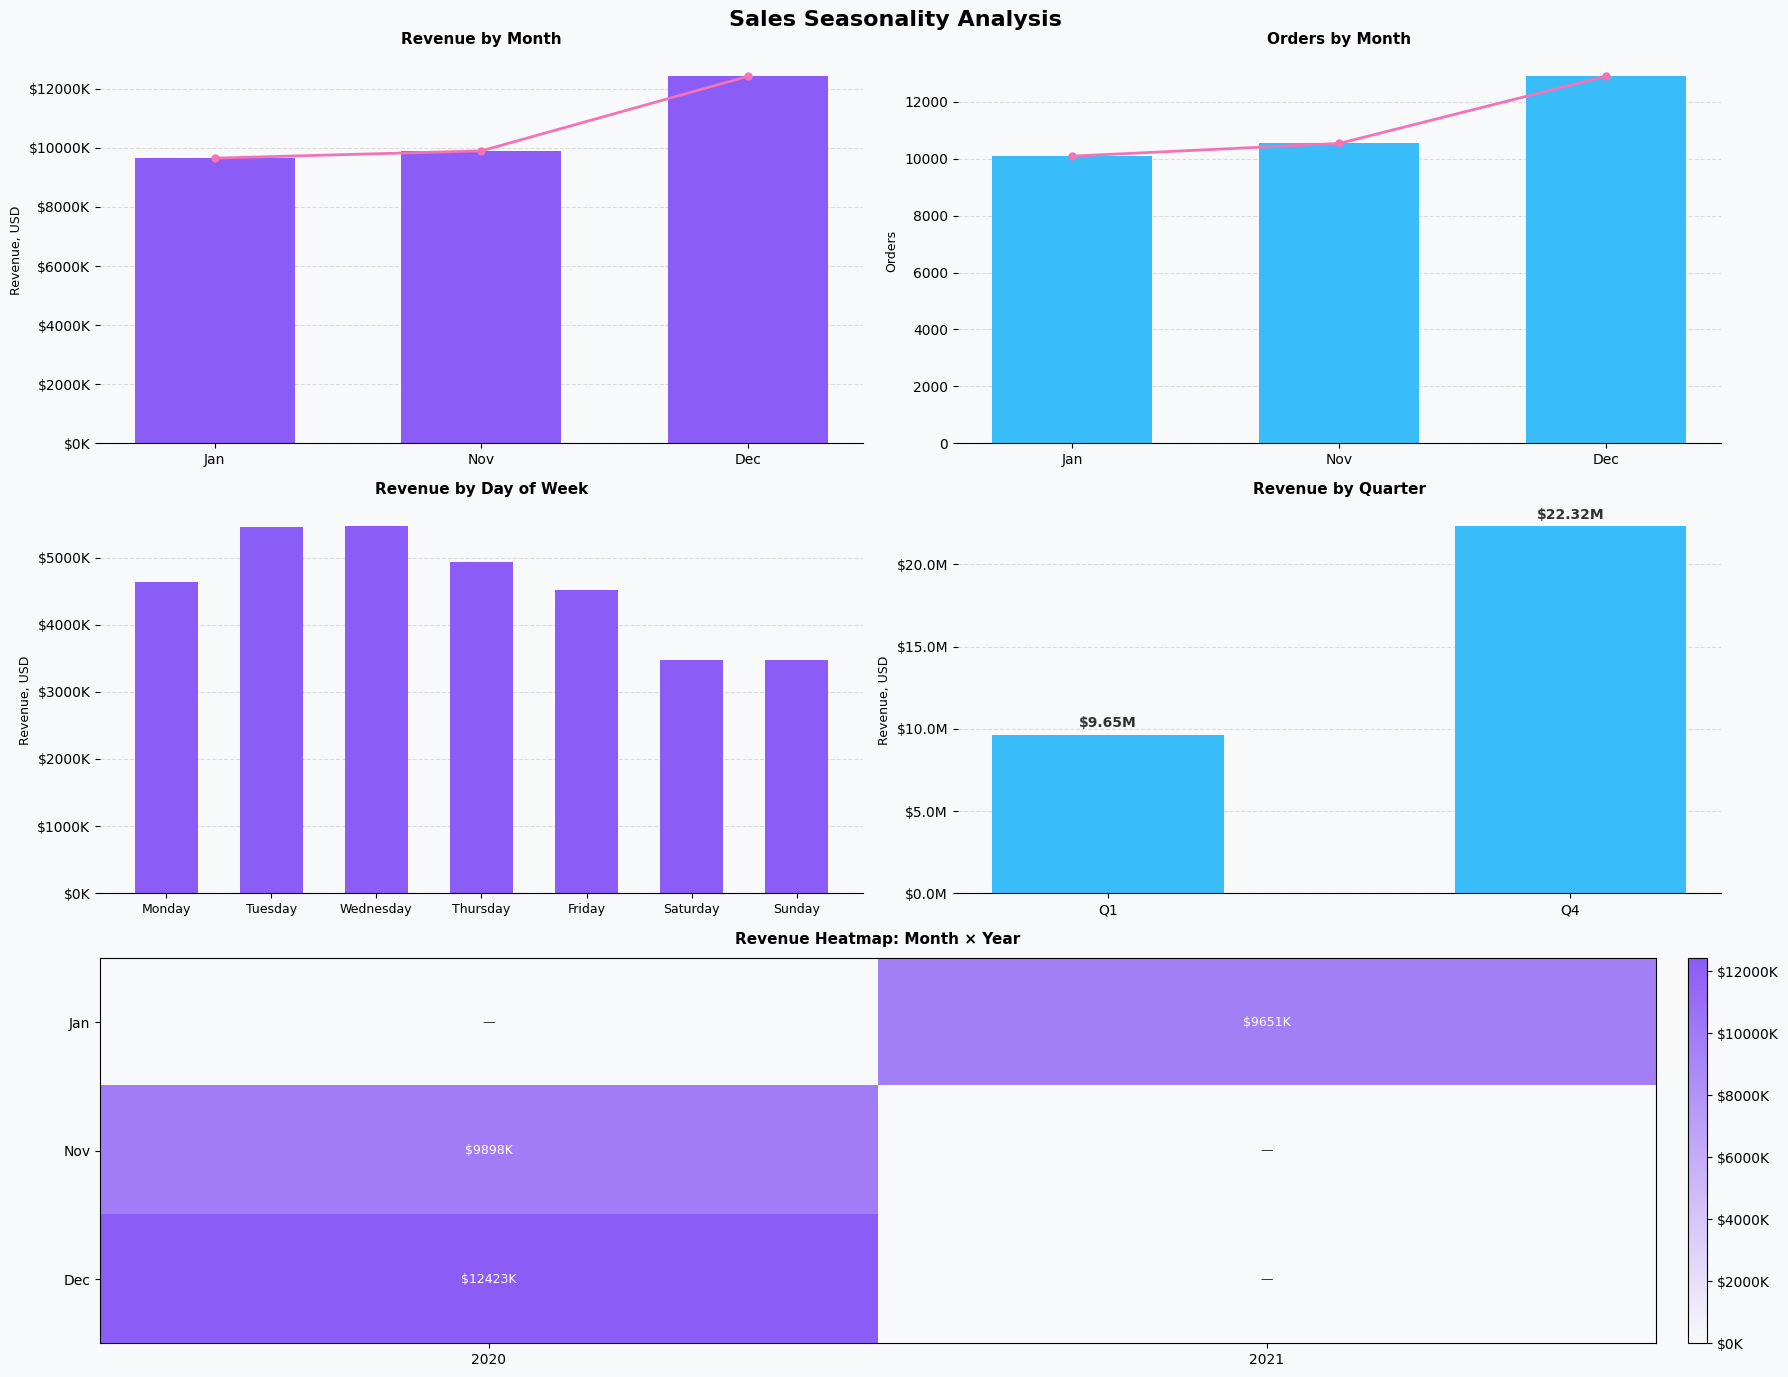

Best month  : Dec  — $12423.4K
Worst month : Jan  — $9650.8K
Best weekday: Wednesday  — $5466.5K
Best quarter: Q4  — $22.32M


In [ ]:
import calendar

orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])

# Дані
orders_df["month"]      = orders_df["order_date"].dt.month
orders_df["month_name"] = orders_df["order_date"].dt.month.apply(lambda x: calendar.month_abbr[x])
orders_df["weekday"]    = orders_df["order_date"].dt.dayofweek
orders_df["weekday_name"] = orders_df["order_date"].dt.day_name()
orders_df["quarter"]    = orders_df["order_date"].dt.quarter.apply(lambda x: f"Q{x}")
orders_df["year"]       = orders_df["order_date"].dt.year

# По місяцях
monthly = (
    orders_df.groupby(["month", "month_name"])
    .agg(revenue=("price", "sum"), orders=("session_id", "nunique"))
    .reset_index()
    .sort_values("month")
)

# По кварталах
quarterly = (
    orders_df.groupby("quarter")
    .agg(revenue=("price", "sum"), orders=("session_id", "nunique"))
    .reset_index()
    .sort_values("quarter")
)

# По днях тижня
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekly = (
    orders_df.groupby(["weekday", "weekday_name"])
    .agg(revenue=("price", "sum"), orders=("session_id", "nunique"))
    .reset_index()
    .sort_values("weekday")
)

# Місяць × рік (heatmap)
pivot = (
    orders_df.groupby(["year", "month"])["price"]
    .sum()
    .unstack(level=0)
    .fillna(0)
)

# Фігура: 2×2 + heatmap
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Sales Seasonality Analysis", fontsize=16, fontweight="bold")
fig.patch.set_facecolor("#F8F9FA")

ax1 = fig.add_subplot(3, 2, 1)
ax2 = fig.add_subplot(3, 2, 2)
ax3 = fig.add_subplot(3, 2, 3)
ax4 = fig.add_subplot(3, 2, 4)
ax5 = fig.add_subplot(3, 1, 3)

for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.set_facecolor("#F8F9FA")

# Місяці: виручка
ax1.bar(monthly["month_name"], monthly["revenue"],
        color=COLOR_REVENUE, width=0.6, zorder=2)
ax1.plot(monthly["month_name"], monthly["revenue"],
         color="#F472B6", linewidth=2, marker="o", markersize=5, zorder=3)
ax1.set_title("Revenue by Month", fontsize=11, fontweight="bold", pad=10)
ax1.set_ylabel("Revenue, USD", fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
ax1.spines[["top", "right", "left"]].set_visible(False)

# Місяці: замовлення
ax2.bar(monthly["month_name"], monthly["orders"],
        color=COLOR_ORDERS, width=0.6, zorder=2)
ax2.plot(monthly["month_name"], monthly["orders"],
         color="#F472B6", linewidth=2, marker="o", markersize=5, zorder=3)
ax2.set_title("Orders by Month", fontsize=11, fontweight="bold", pad=10)
ax2.set_ylabel("Orders", fontsize=9)
ax2.grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
ax2.spines[["top", "right", "left"]].set_visible(False)

# Дні тижня
ax3.bar(weekly["weekday_name"], weekly["revenue"],
        color=COLOR_REVENUE, width=0.6, zorder=2)
ax3.set_title("Revenue by Day of Week", fontsize=11, fontweight="bold", pad=10)
ax3.set_ylabel("Revenue, USD", fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax3.tick_params(axis="x", labelsize=9)
ax3.grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
ax3.spines[["top", "right", "left"]].set_visible(False)

# Квартали
bars = ax4.bar(quarterly["quarter"], quarterly["revenue"],
               color=COLOR_ORDERS, width=0.5, zorder=2)
ax4.set_title("Revenue by Quarter", fontsize=11, fontweight="bold", pad=10)
ax4.set_ylabel("Revenue, USD", fontsize=9)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax4.grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
ax4.spines[["top", "right", "left"]].set_visible(False)
for bar, (_, row) in zip(bars, quarterly.iterrows()):
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + quarterly["revenue"].max() * 0.02,
             f"${row['revenue']/1e6:.2f}M",
             ha="center", fontsize=10, fontweight="bold", color="#333")

# Heatmap: місяць × рік
import matplotlib.colors as mcolors

cmap = mcolors.LinearSegmentedColormap.from_list("custom", ["#F8F9FA", COLOR_REVENUE])
im   = ax5.imshow(pivot.values, aspect="auto", cmap=cmap)

ax5.set_xticks(range(len(pivot.columns)))
ax5.set_xticklabels(pivot.columns, fontsize=10)
ax5.set_yticks(range(len(pivot.index)))
ax5.set_yticklabels([calendar.month_abbr[m] for m in pivot.index], fontsize=10)
ax5.set_title("Revenue Heatmap: Month × Year", fontsize=11, fontweight="bold", pad=10)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax5.text(j, i, f"${val/1e3:.0f}K" if val > 0 else "—",
                 ha="center", va="center",
                 fontsize=9, color="white" if val > pivot.values.max() * 0.5 else "#333")

plt.colorbar(im, ax=ax5, orientation="vertical",
             format=mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"),
             fraction=0.02, pad=0.02)

plt.tight_layout()
plt.savefig("seasonality.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Текстовий висновок
best_month  = monthly.loc[monthly["revenue"].idxmax()]
worst_month = monthly.loc[monthly["revenue"].idxmin()]
best_day    = weekly.loc[weekly["revenue"].idxmax()]
best_q      = quarterly.loc[quarterly["revenue"].idxmax()]

print(f"Best month  : {best_month['month_name']}  — ${best_month['revenue']/1e3:.1f}K")
print(f"Worst month : {worst_month['month_name']}  — ${worst_month['revenue']/1e3:.1f}K")
print(f"Best weekday: {best_day['weekday_name']}  — ${best_day['revenue']/1e3:.1f}K")
print(f"Best quarter: {best_q['quarter']}  — ${best_q['revenue']/1e6:.2f}M")

Сезонні коливання в динаміці продажів не виявлені. Показники залишаються відносно стабільними протягом усього аналізованого періоду, без виражених піків або спадів, характерних для сезонного попиту.


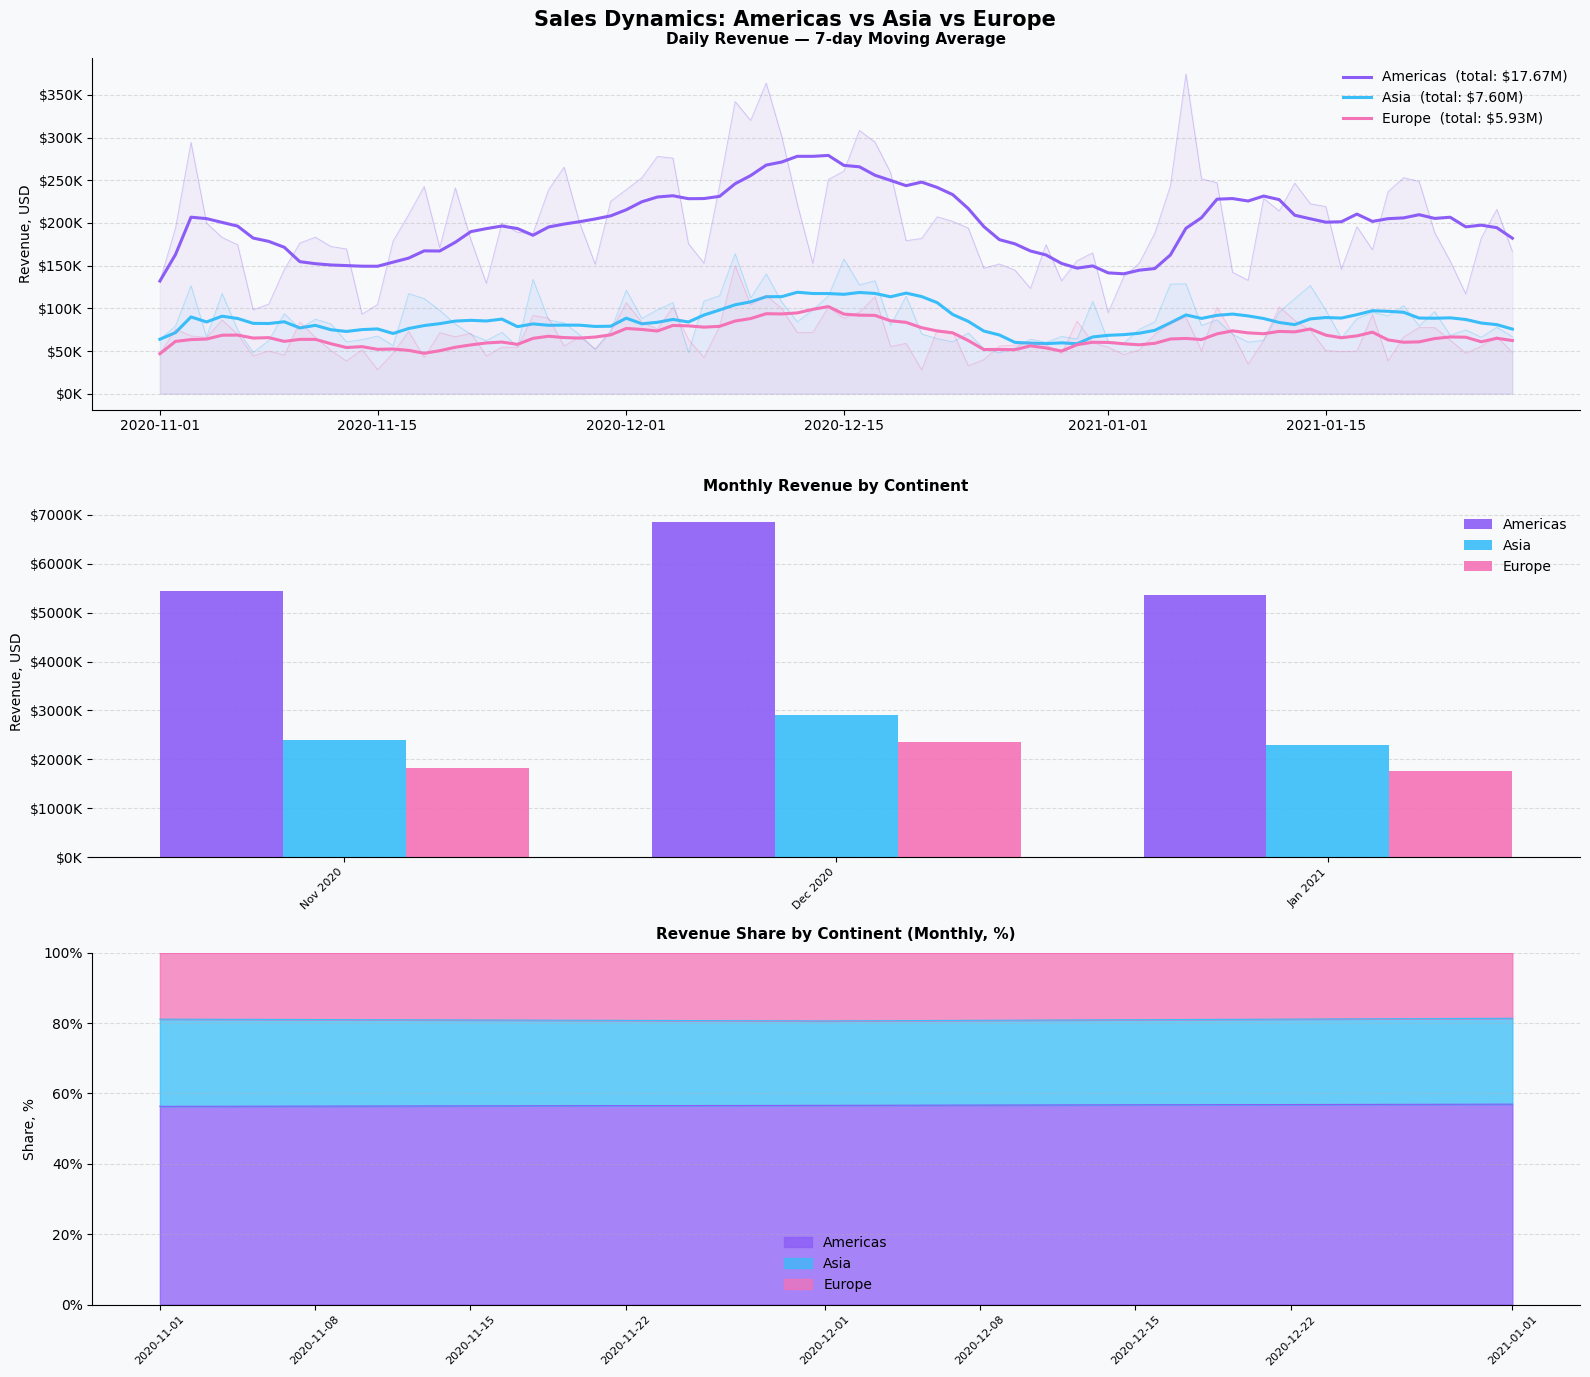

Total revenue by continent:
  Americas   $17.67M  (56.6%)
  Asia       $7.60M  (24.4%)
  Europe     $5.93M  (19.0%)


In [ ]:
# Дані
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])

target_continents = ["Americas", "Asia", "Europe"]
continent_colors  = {
    "Americas": COLOR_REVENUE,   # фіолетовий
    "Asia"    : COLOR_ORDERS,    # блакитний
    "Europe"  : "#F472B6"        # рожевий
}

continent_daily = (
    orders_df[orders_df["continent"].isin(target_continents)]
    .groupby(["order_date", "continent"])
    .agg(revenue=("price", "sum"), orders=("session_id", "nunique"))
    .reset_index()
    .sort_values("order_date")
)

# Ковзна середня 7 днів по кожному континенту
continent_daily["revenue_7d"] = (
    continent_daily.groupby("continent")["revenue"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)
continent_daily["orders_7d"] = (
    continent_daily.groupby("continent")["orders"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

# Місячний агрегат
continent_monthly = (
    orders_df[orders_df["continent"].isin(target_continents)]
    .groupby([orders_df["order_date"].dt.to_period("M"), "continent"])
    .agg(revenue=("price", "sum"), orders=("session_id", "nunique"))
    .reset_index()
    .rename(columns={"order_date": "month"})
    .assign(month=lambda x: x["month"].dt.to_timestamp())
    .sort_values("month")
)

# Загальна виручка по континентах для підписів
totals = (
    orders_df[orders_df["continent"].isin(target_continents)]
    .groupby("continent")["price"].sum()
)

# Фігура: 3 рядки
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=False)
fig.suptitle("Sales Dynamics: Americas vs Asia vs Europe",
             fontsize=15, fontweight="bold")
fig.patch.set_facecolor("#F8F9FA")
for ax in axes:
    ax.set_facecolor("#F8F9FA")

# Верхній: щоденна виручка (7d MA)
for continent in target_continents:
    data  = continent_daily[continent_daily["continent"] == continent]
    color = continent_colors[continent]
    axes[0].fill_between(data["order_date"], data["revenue"],
                         alpha=0.07, color=color)
    axes[0].plot(data["order_date"], data["revenue"],
                 color=color, linewidth=0.6, alpha=0.3)
    axes[0].plot(data["order_date"], data["revenue_7d"],
                 color=color, linewidth=2.2,
                 label=f"{continent}  (total: ${totals[continent]/1e6:.2f}M)")

axes[0].set_title("Daily Revenue — 7-day Moving Average", fontsize=11,
                  fontweight="bold", pad=10)
axes[0].set_ylabel("Revenue, USD", fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].legend(fontsize=10, frameon=False)

# Середній: місячна виручка (grouped bar)
months     = sorted(continent_monthly["month"].unique())
month_lbls = [m.strftime("%b %Y") for m in months]
n_months   = len(months)
n_groups   = len(target_continents)
width      = 0.25
x          = np.arange(n_months)

for i, continent in enumerate(target_continents):
    data = continent_monthly[continent_monthly["continent"] == continent]
    data = data.set_index("month").reindex(months).fillna(0).reset_index()
    axes[1].bar(x + i * width, data["revenue"],
                width=width, color=continent_colors[continent],
                label=continent, zorder=2, alpha=0.9)

axes[1].set_title("Monthly Revenue by Continent", fontsize=11,
                  fontweight="bold", pad=10)
axes[1].set_ylabel("Revenue, USD", fontsize=10)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(month_lbls, rotation=45, ha="right", fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[1].grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
axes[1].spines[["top", "right", "left"]].set_visible(False)
axes[1].legend(fontsize=10, frameon=False)

# Нижній: частка виручки по місяцях (stacked area)
pivot_pct = (
    continent_monthly.pivot(index="month", columns="continent", values="revenue")
    .fillna(0)
    .apply(lambda row: row / row.sum() * 100, axis=1)
)

bottom = np.zeros(len(pivot_pct))
for continent in target_continents:
    if continent in pivot_pct.columns:
        vals = pivot_pct[continent].values
        axes[2].fill_between(pivot_pct.index, bottom, bottom + vals,
                             alpha=0.75, color=continent_colors[continent],
                             label=continent)
        axes[2].plot(pivot_pct.index, bottom + vals,
                     color=continent_colors[continent], linewidth=0.8)
        bottom += vals

axes[2].set_title("Revenue Share by Continent (Monthly, %)",
                  fontsize=11, fontweight="bold", pad=10)
axes[2].set_ylabel("Share, %", fontsize=10)
axes[2].set_ylim(0, 100)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[2].tick_params(axis="x", rotation=45, labelsize=8)
axes[2].grid(axis="y", linestyle="--", alpha=0.4)
axes[2].spines[["top", "right"]].set_visible(False)
axes[2].legend(fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig("continent_dynamics.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Текстовий висновок
print("Total revenue by continent:")
for c in target_continents:
    pct = totals[c] / totals.sum() * 100
    print(f"  {c:<10} ${totals[c]/1e6:.2f}M  ({pct:.1f}%)")

Графік підтверджує попередній аналіз, найбільші продажі спостегіраються у Америці

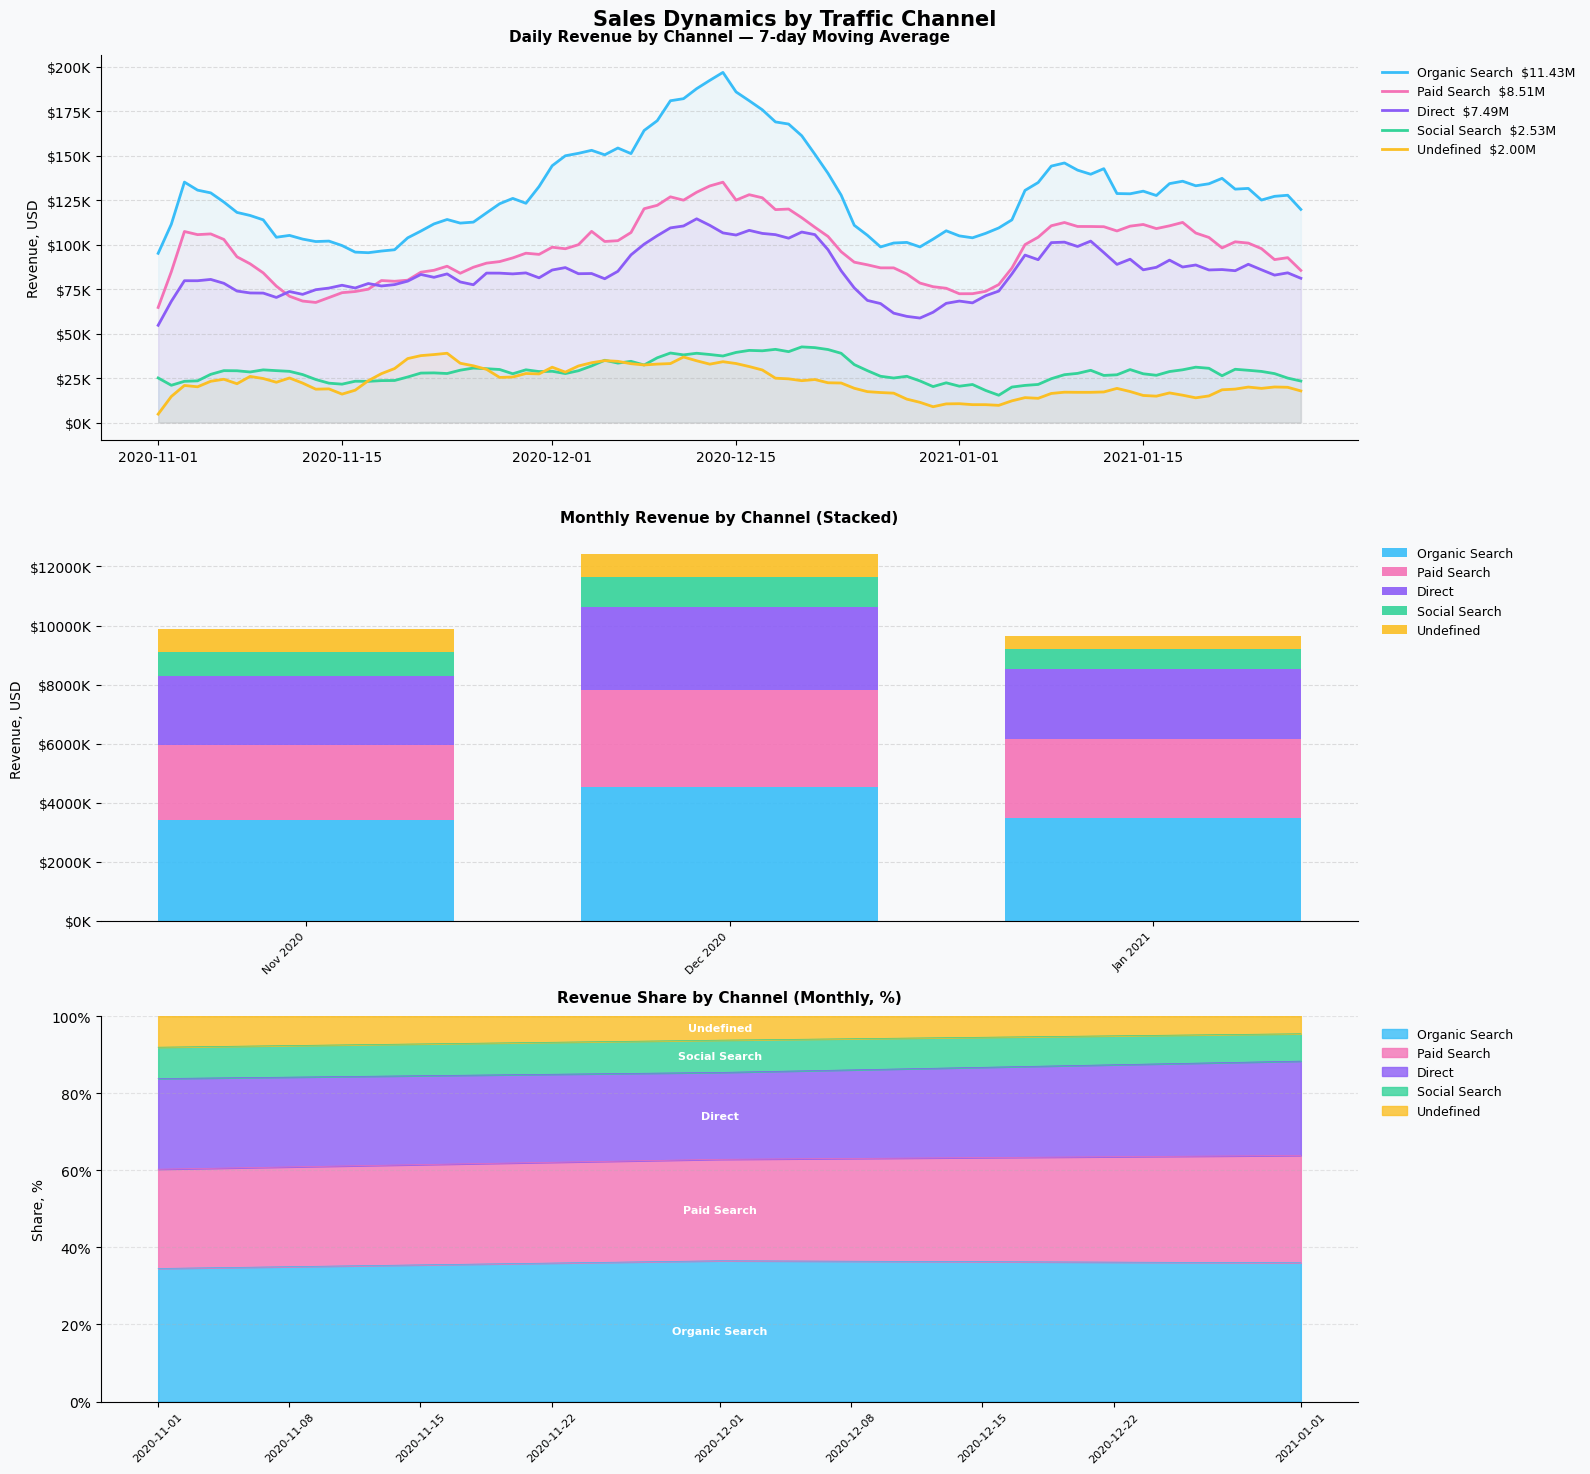

Total revenue by channel:
  Organic Search            $11.43M  (35.8%)
  Paid Search               $8.51M  (26.6%)
  Direct                    $7.49M  (23.4%)
  Social Search             $2.53M  (7.9%)
  Undefined                 $2.00M  (6.3%)


In [ ]:
# Дані
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])

# Визначаємо канали та кольори
channels = orders_df["traffic_channel"].dropna().unique().tolist()

channel_palette = [
    COLOR_REVENUE, COLOR_ORDERS, "#F472B6", "#34D399",
    "#FBBF24", "#F87171", "#A78BFA", "#22D3EE", "#FB923C", "#4ADE80"
]
channel_colors = {ch: channel_palette[i % len(channel_palette)]
                  for i, ch in enumerate(sorted(channels))}

# Щоденний агрегат по каналах
channel_daily = (
    orders_df[orders_df["traffic_channel"].notna()]
    .groupby(["order_date", "traffic_channel"])
    .agg(revenue=("price", "sum"), orders=("session_id", "nunique"))
    .reset_index()
    .sort_values("order_date")
)

channel_daily["revenue_7d"] = (
    channel_daily.groupby("traffic_channel")["revenue"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

# Місячний агрегат
channel_monthly = (
    orders_df[orders_df["traffic_channel"].notna()]
    .groupby([orders_df["order_date"].dt.to_period("M"), "traffic_channel"])
    .agg(revenue=("price", "sum"), orders=("session_id", "nunique"))
    .reset_index()
    .rename(columns={"order_date": "month"})
    .assign(month=lambda x: x["month"].dt.to_timestamp())
    .sort_values("month")
)

# Загальна виручка по каналах
totals = (
    orders_df[orders_df["traffic_channel"].notna()]
    .groupby("traffic_channel")["price"].sum()
    .sort_values(ascending=False)
)
channels_sorted = totals.index.tolist()

# Фігура: 3 рядки
fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=False)
fig.suptitle("Sales Dynamics by Traffic Channel",
             fontsize=15, fontweight="bold")
fig.patch.set_facecolor("#F8F9FA")
for ax in axes:
    ax.set_facecolor("#F8F9FA")

# Верхній: 7d MA щоденної виручки
for channel in channels_sorted:
    data  = channel_daily[channel_daily["traffic_channel"] == channel]
    color = channel_colors[channel]
    axes[0].fill_between(data["order_date"], data["revenue_7d"],
                         alpha=0.06, color=color)
    axes[0].plot(data["order_date"], data["revenue_7d"],
                 color=color, linewidth=2,
                 label=f"{channel}  ${totals[channel]/1e6:.2f}M")

axes[0].set_title("Daily Revenue by Channel — 7-day Moving Average",
                  fontsize=11, fontweight="bold", pad=10)
axes[0].set_ylabel("Revenue, USD", fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].legend(fontsize=9, frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")

# Середній: місячна виручка stacked bar
months     = sorted(channel_monthly["month"].unique())
month_lbls = [m.strftime("%b %Y") for m in months]
x          = np.arange(len(months))
bottom     = np.zeros(len(months))

for channel in channels_sorted:
    data = (
        channel_monthly[channel_monthly["traffic_channel"] == channel]
        .set_index("month")
        .reindex(months)
        .fillna(0)
        .reset_index()
    )
    axes[1].bar(x, data["revenue"], bottom=bottom,
                color=channel_colors[channel], label=channel,
                width=0.7, zorder=2, alpha=0.9)
    bottom += data["revenue"].values

axes[1].set_title("Monthly Revenue by Channel (Stacked)",
                  fontsize=11, fontweight="bold", pad=10)
axes[1].set_ylabel("Revenue, USD", fontsize=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(month_lbls, rotation=45, ha="right", fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[1].grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
axes[1].spines[["top", "right", "left"]].set_visible(False)
axes[1].legend(fontsize=9, frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")

# Нижній: частка каналів по місяцях (stacked area 100%)
pivot_pct = (
    channel_monthly.pivot(index="month", columns="traffic_channel", values="revenue")
    .fillna(0)
    .apply(lambda row: row / row.sum() * 100, axis=1)
)

bottom = np.zeros(len(pivot_pct))
for channel in channels_sorted:
    if channel in pivot_pct.columns:
        vals = pivot_pct[channel].values
        axes[2].fill_between(pivot_pct.index, bottom, bottom + vals,
                             alpha=0.8, color=channel_colors[channel],
                             label=channel)
        axes[2].plot(pivot_pct.index, bottom + vals,
                     color=channel_colors[channel], linewidth=0.5)
        mid_idx = len(pivot_pct) // 2
        mid_val = bottom[mid_idx] + vals[mid_idx] / 2
        if vals[mid_idx] > 5:
            axes[2].text(pivot_pct.index[mid_idx], mid_val,
                         channel, ha="center", va="center",
                         fontsize=8, fontweight="bold", color="white")
        bottom += vals

axes[2].set_title("Revenue Share by Channel (Monthly, %)",
                  fontsize=11, fontweight="bold", pad=10)
axes[2].set_ylabel("Share, %", fontsize=10)
axes[2].set_ylim(0, 100)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[2].tick_params(axis="x", rotation=45, labelsize=8)
axes[2].grid(axis="y", linestyle="--", alpha=0.3)
axes[2].spines[["top", "right"]].set_visible(False)
axes[2].legend(fontsize=9, frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig("channel_dynamics.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Текстовий висновок
print("Total revenue by channel:")
for ch in channels_sorted:
    pct = totals[ch] / totals.sum() * 100
    print(f"  {ch:<25} ${totals[ch]/1e6:.2f}M  ({pct:.1f}%)")

Аналіз розподілу продажів між каналами трафіку підтверджує стабільну домінантну роль органічного пошуку в загальній структурі виручки. Частка Organic Search становить 35.8% від загального обсягу продажів, що робить його ключовим джерелом доходу в розрізі каналів залучення.

Direct та Paid Search формують значну, але менш домінуючу частку продажів, забезпечуючи суттєвий внесок у загальну динаміку. Водночас Social Search та Undefined залишаються другорядними каналами з обмеженим впливом на загальний результат.

Отримані результати свідчать про концентровану структуру трафіку з вираженою залежністю від органічного каналу та відносно рівномірним, але меншим внеском інших джерел залучення.


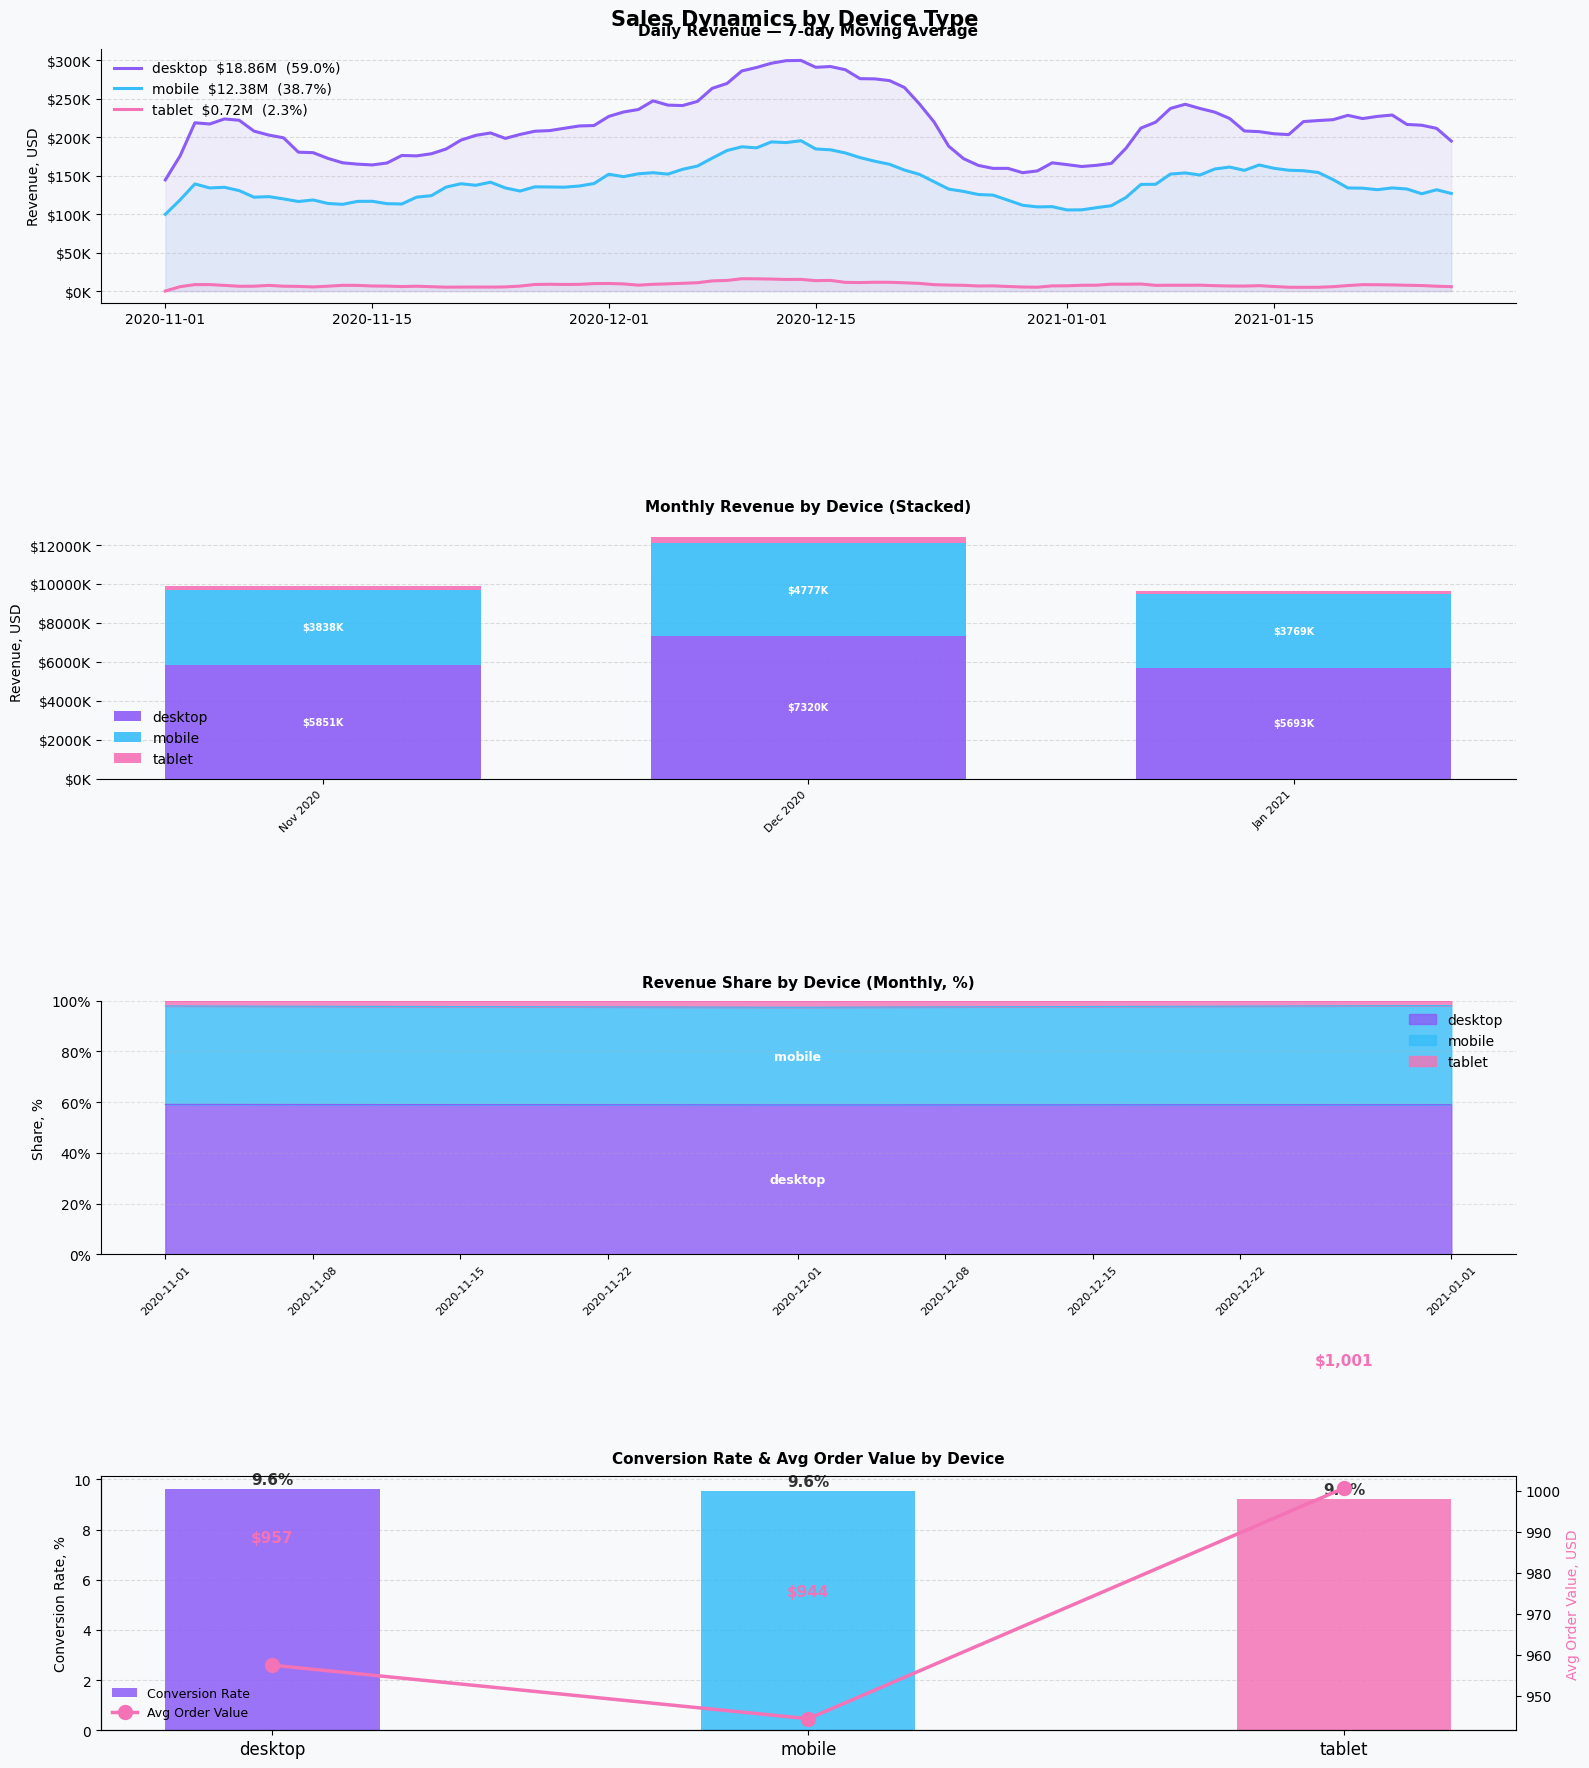

Total revenue by device:
  desktop    $18.86M  (59.0%)
  mobile     $12.38M  (38.7%)
  tablet     $0.72M  (2.3%)

Conversion & Avg order value:
  desktop    CR: 9.6%  |  AOV: $957.47
  mobile     CR: 9.6%  |  AOV: $944.42
  tablet     CR: 9.2%  |  AOV: $1,000.64


In [ ]:
# Дані
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])

device_colors = {
    "desktop": COLOR_REVENUE,  # фіолетовий
    "mobile" : COLOR_ORDERS,   # блакитний
    "tablet" : "#F472B6"       # рожевий
}

devices = orders_df["device"].dropna().unique().tolist()

# Щоденний агрегат
device_daily = (
    orders_df[orders_df["device"].notna()]
    .groupby(["order_date", "device"])
    .agg(revenue=("price", "sum"), orders=("session_id", "nunique"))
    .reset_index()
    .sort_values("order_date")
)

device_daily["revenue_7d"] = (
    device_daily.groupby("device")["revenue"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

# Місячний агрегат
device_monthly = (
    orders_df[orders_df["device"].notna()]
    .groupby([orders_df["order_date"].dt.to_period("M"), "device"])
    .agg(revenue=("price", "sum"), orders=("session_id", "nunique"))
    .reset_index()
    .rename(columns={"order_date": "month"})
    .assign(month=lambda x: x["month"].dt.to_timestamp())
    .sort_values("month")
)

# Загальна виручка
totals = (
    orders_df[orders_df["device"].notna()]
    .groupby("device")["price"].sum()
    .sort_values(ascending=False)
)
devices_sorted = totals.index.tolist()

# Конверсія по девайсах
device_conv = (
    df.groupby("device")
    .agg(
        sessions  =("session_id",   "nunique"),
        purchases =("product_name", lambda x: x.notna().sum())
    )
    .reset_index()
    .assign(conversion=lambda x: x["purchases"] / x["sessions"] * 100)
)

# Фігура: 4 рядки
fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=False)
fig.suptitle("Sales Dynamics by Device Type", fontsize=15, fontweight="bold")
fig.patch.set_facecolor("#F8F9FA")
for ax in axes:
    ax.set_facecolor("#F8F9FA")

# 1: 7d MA щоденної виручки
for device in devices_sorted:
    data  = device_daily[device_daily["device"] == device]
    color = device_colors.get(device, "#999")
    axes[0].fill_between(data["order_date"], data["revenue_7d"],
                         alpha=0.08, color=color)
    axes[0].plot(data["order_date"], data["revenue_7d"],
                 color=color, linewidth=2.2,
                 label=f"{device}  ${totals[device]/1e6:.2f}M  ({totals[device]/totals.sum()*100:.1f}%)")

axes[0].set_title("Daily Revenue — 7-day Moving Average",
                  fontsize=11, fontweight="bold", pad=10)
axes[0].set_ylabel("Revenue, USD", fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].legend(fontsize=10, frameon=False)

# 2: місячна виручка stacked bar
months     = sorted(device_monthly["month"].unique())
month_lbls = [m.strftime("%b %Y") for m in months]
x          = np.arange(len(months))
bottom     = np.zeros(len(months))

for device in devices_sorted:
    data = (
        device_monthly[device_monthly["device"] == device]
        .set_index("month").reindex(months).fillna(0).reset_index()
    )
    axes[1].bar(x, data["revenue"], bottom=bottom,
                color=device_colors.get(device, "#999"),
                label=device, width=0.65, zorder=2, alpha=0.9)

    for i, val in enumerate(data["revenue"].values):
        if val > totals.sum() / len(months) * 0.05:
            axes[1].text(i, bottom[i] + val / 2, f"${val/1e3:.0f}K",
                         ha="center", va="center", fontsize=7,
                         fontweight="bold", color="white")
    bottom += data["revenue"].values

axes[1].set_title("Monthly Revenue by Device (Stacked)",
                  fontsize=11, fontweight="bold", pad=10)
axes[1].set_ylabel("Revenue, USD", fontsize=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(month_lbls, rotation=45, ha="right", fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[1].grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
axes[1].spines[["top", "right", "left"]].set_visible(False)
axes[1].legend(fontsize=10, frameon=False)

# 3: частка девайсів по місяцях (100% stacked area)
pivot_pct = (
    device_monthly.pivot(index="month", columns="device", values="revenue")
    .fillna(0)
    .apply(lambda row: row / row.sum() * 100, axis=1)
)

bottom = np.zeros(len(pivot_pct))
for device in devices_sorted:
    if device in pivot_pct.columns:
        vals  = pivot_pct[device].values
        color = device_colors.get(device, "#999")
        axes[2].fill_between(pivot_pct.index, bottom, bottom + vals,
                             alpha=0.8, color=color, label=device)
        axes[2].plot(pivot_pct.index, bottom + vals,
                     color=color, linewidth=0.8)
        mid_idx = len(pivot_pct) // 2
        if vals[mid_idx] > 5:
            axes[2].text(pivot_pct.index[mid_idx],
                         bottom[mid_idx] + vals[mid_idx] / 2,
                         device, ha="center", va="center",
                         fontsize=9, fontweight="bold", color="white")
        bottom += vals

axes[2].set_title("Revenue Share by Device (Monthly, %)",
                  fontsize=11, fontweight="bold", pad=10)
axes[2].set_ylabel("Share, %", fontsize=10)
axes[2].set_ylim(0, 100)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[2].tick_params(axis="x", rotation=45, labelsize=8)
axes[2].grid(axis="y", linestyle="--", alpha=0.3)
axes[2].spines[["top", "right"]].set_visible(False)
axes[2].legend(fontsize=10, frameon=False)

# 4: конверсія та середній чек по девайсах
ax4a = axes[3]
ax4b = ax4a.twinx()

bars = ax4a.bar(device_conv["device"], device_conv["conversion"],
                color=[device_colors.get(d, "#999") for d in device_conv["device"]],
                width=0.4, zorder=2, alpha=0.85, label="Conversion Rate")

avg_check = (
    orders_df.groupby("device")["price"].mean()
    .reindex(device_conv["device"].values)
    .values
)
ax4b.plot(device_conv["device"], avg_check,
          color="#F472B6", linewidth=2.5, marker="o",
          markersize=10, zorder=3, label="Avg Order Value")

for i, (d, cr, ac) in enumerate(zip(device_conv["device"],
                                     device_conv["conversion"], avg_check)):
    ax4a.text(i, cr + device_conv["conversion"].max() * 0.02,
              f"{cr:.1f}%", ha="center", fontsize=11,
              fontweight="bold", color="#333")
    ax4b.text(i, ac + avg_check.max() * 0.03,
              f"${ac:,.0f}", ha="center", fontsize=11,
              fontweight="bold", color="#F472B6")

ax4a.set_title("Conversion Rate & Avg Order Value by Device",
               fontsize=11, fontweight="bold", pad=10)
ax4a.set_ylabel("Conversion Rate, %", fontsize=10)
ax4b.set_ylabel("Avg Order Value, USD", fontsize=10, color="#F472B6")
ax4a.tick_params(axis="x", labelsize=12)
ax4a.grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
ax4a.spines[["top", "right"]].set_visible(False)

lines1, labels1 = ax4a.get_legend_handles_labels()
lines2, labels2 = ax4b.get_legend_handles_labels()
ax4a.legend(lines1 + lines2, labels1 + labels2, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("device_dynamics.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Текстовий висновок
print("Total revenue by device:")
for d in devices_sorted:
    pct = totals[d] / totals.sum() * 100
    print(f"  {d:<10} ${totals[d]/1e6:.2f}M  ({pct:.1f}%)")

print("\nConversion & Avg order value:")
for _, row in device_conv.iterrows():
    ac = orders_df[orders_df["device"] == row["device"]]["price"].mean()
    print(f"  {row['device']:<10} CR: {row['conversion']:.1f}%  |  AOV: ${ac:,.2f}")

Аналіз розподілу продажів за типами пристроїв показує чітке домінування desktop-сегмента. Близько 59% усіх замовлень було здійснено з десктопних пристроїв, що робить його основним каналом конверсії.

Крім найбільшої частки замовлень, desktop також демонструє найвищий рівень конверсії серед усіх типів пристроїв. Це свідчить про більш усвідомлений характер покупок у цьому сегменті, де користувачі, ймовірно, витрачають більше часу на вибір товару та прийняття рішення.

Отримані результати вказують на те, що основна комерційна активність концентрується в desktop-каналі, тоді як інші пристрої відіграють допоміжну роль у формуванні загального обсягу продажів.

In [ ]:
pivot_table = (
    df[df["traffic_channel"].notna() & df["device"].notna()]
    .pivot_table(
        index="traffic_channel",
        columns="device",
        values="session_id",
        aggfunc="nunique",
        margins=True,
        margins_name="Total"
    )
    .fillna(0)
    .astype(int)
)

print(pivot_table.to_string())

device           desktop  mobile  tablet   Total
traffic_channel                                 
Direct             47825   31745    1812   81382
Organic Search     72622   49014    2789  124425
Paid Search        55167   37034    2140   94341
Social Search      16288   10988     638   27914
Undefined          12527    8486     470   21483
Total             204429  137267    7849  349545


In [ ]:
# Топ-5 країн і топ-10 категорій за виручкою
top5_countries  = orders_df.groupby("country")["price"].sum().nlargest(5).index.tolist()
top10_categories = orders_df.groupby("product_category")["price"].sum().nlargest(10).index.tolist()

# Зведена таблиця
pivot = (
    orders_df[
        orders_df["country"].isin(top5_countries) &
        orders_df["product_category"].isin(top10_categories)
    ]
    .pivot_table(
        index="product_category",
        columns="country",
        values="price",
        aggfunc="sum",
        margins=True,
        margins_name="Total"
    )
    .fillna(0)
    .astype(int)
)

# Сортування по Total за спаданням (без рядка Total)
pivot = pd.concat([
    pivot.drop("Total").sort_values("Total", ascending=False),
    pivot.loc[["Total"]]
])

# Вивід
print(pivot.to_string())

country                            Canada  France    India  United Kingdom  United States     Total
product_category                                                                                   
Sofas & armchairs                  692427  187735   788430          234812        3707144   5610549
Chairs                             417740  134029   544309          188519        2619773   3904372
Beds                               354772  116414   358319          133816        2213058   3176379
Bookcases & shelving units         278981   73830   364507          113987        1567606   2398913
Cabinets & cupboards               181802   59101   191888           71684         994545   1499021
Outdoor furniture                  185322   40486   162289           57002         929245   1374346
Tables & desks                     132678   42299   186157           49374         777865   1188373
Chests of drawers & drawer units    71952   21544    73111           36784         382388    585779


In [ ]:
# Зведена таблиця 2: середній чек по континентах та категоріях товарів
top8_categories = orders_df.groupby("product_category")["price"].sum().nlargest(8).index.tolist()

pivot_aov = (
    orders_df[
        orders_df["continent"].notna() &
        orders_df["product_category"].isin(top8_categories)
    ]
    .pivot_table(
        index="product_category",
        columns="continent",
        values="price",
        aggfunc="mean",
        margins=True,
        margins_name="Avg"
    )
    .round(2)
)

pivot_aov = pd.concat([
    pivot_aov.drop("Avg").sort_values("Avg", ascending=False),
    pivot_aov.loc[["Avg"]]
])

print("═" * 60)
print("  Avg Order Value ($) by Continent & Product Category")
print("═" * 60)
print(pivot_aov.to_string())

pivot_aov.style\
    .background_gradient(cmap="Purples", subset=pivot_aov.columns[:-1])\
    .format("${:.2f}")

════════════════════════════════════════════════════════════
  Avg Order Value ($) by Continent & Product Category
════════════════════════════════════════════════════════════
continent                         (not set)   Africa  Americas     Asia   Europe  Oceania      Avg
product_category                                                                                  
Sofas & armchairs                   2334.50  2703.00   1971.41  1946.13  1857.07  1819.44  1950.30
Beds                                1913.00  1644.79   1685.77  1634.79  1688.04  2268.40  1681.38
Chairs                              1317.77   787.32   1004.01  1074.42  1064.66  1222.60  1032.89
Cabinets & cupboards                 732.43   844.24   1003.59  1030.94  1014.40   861.75  1007.98
Outdoor furniture                    521.90   710.60    968.94   950.60   974.52   894.62   961.07
Chests of drawers & drawer units     670.00   607.83    623.28   604.55   644.11   759.06   624.35
Tables & desks                  

continent,(not set),Africa,Americas,Asia,Europe,Oceania,Avg
product_category,,,,,,,
Sofas & armchairs,$2334.50,$2703.00,$1971.41,$1946.13,$1857.07,$1819.44,$1950.30
Beds,$1913.00,$1644.79,$1685.77,$1634.79,$1688.04,$2268.40,$1681.38
Chairs,$1317.77,$787.32,$1004.01,$1074.42,$1064.66,$1222.60,$1032.89
Cabinets & cupboards,$732.43,$844.24,$1003.59,$1030.94,$1014.40,$861.75,$1007.98
Outdoor furniture,$521.90,$710.60,$968.94,$950.60,$974.52,$894.62,$961.07
Chests of drawers & drawer units,$670.00,$607.83,$623.28,$604.55,$644.11,$759.06,$624.35
Tables & desks,$888.44,$555.33,$615.47,$653.79,$536.79,$560.18,$608.74
Bookcases & shelving units,$199.77,$507.64,$465.36,$499.14,$483.93,$488.37,$477.17
Avg,$1074.28,$1038.44,$1017.12,$1018.50,$1012.78,$1072.74,$1017.59


In [ ]:
# Зведена таблиця 1: конверсія по каналах трафіку та девайсах
sessions = (
    df[df["traffic_channel"].notna() & df["device"].notna()]
    .groupby(["traffic_channel", "device"])["session_id"]
    .nunique()
    .reset_index()
    .rename(columns={"session_id": "sessions"})
)

purchases = (
    df[df["traffic_channel"].notna() & df["device"].notna() & df["product_name"].notna()]
    .groupby(["traffic_channel", "device"])["session_id"]
    .nunique()
    .reset_index()
    .rename(columns={"session_id": "purchases"})
)

conv_data = sessions.merge(purchases, on=["traffic_channel", "device"], how="left").fillna(0)
conv_data["conversion"] = (conv_data["purchases"] / conv_data["sessions"] * 100).round(1)

pivot_conv = conv_data.pivot_table(
    index="traffic_channel",
    columns="device",
    values="conversion",
    aggfunc="mean"
).round(1)

print("═" * 60)
print("  Conversion Rate (%) by Traffic Channel & Device")
print("═" * 60)
print(pivot_conv.to_string())

pivot_conv.style\
    .background_gradient(cmap="Purples")\
    .format("{:.1f}%")

════════════════════════════════════════════════════════════
  Conversion Rate (%) by Traffic Channel & Device
════════════════════════════════════════════════════════════
device           desktop  mobile  tablet
traffic_channel                         
Direct               9.7     9.4     8.8
Organic Search       9.7     9.5     9.1
Paid Search          9.5     9.7     9.7
Social Search        9.8     9.7     8.9
Undefined            9.4     9.8     9.4


device,desktop,mobile,tablet
traffic_channel,,,
Direct,9.7%,9.4%,8.8%
Organic Search,9.7%,9.5%,9.1%
Paid Search,9.5%,9.7%,9.7%
Social Search,9.8%,9.7%,8.9%
Undefined,9.4%,9.8%,9.4%


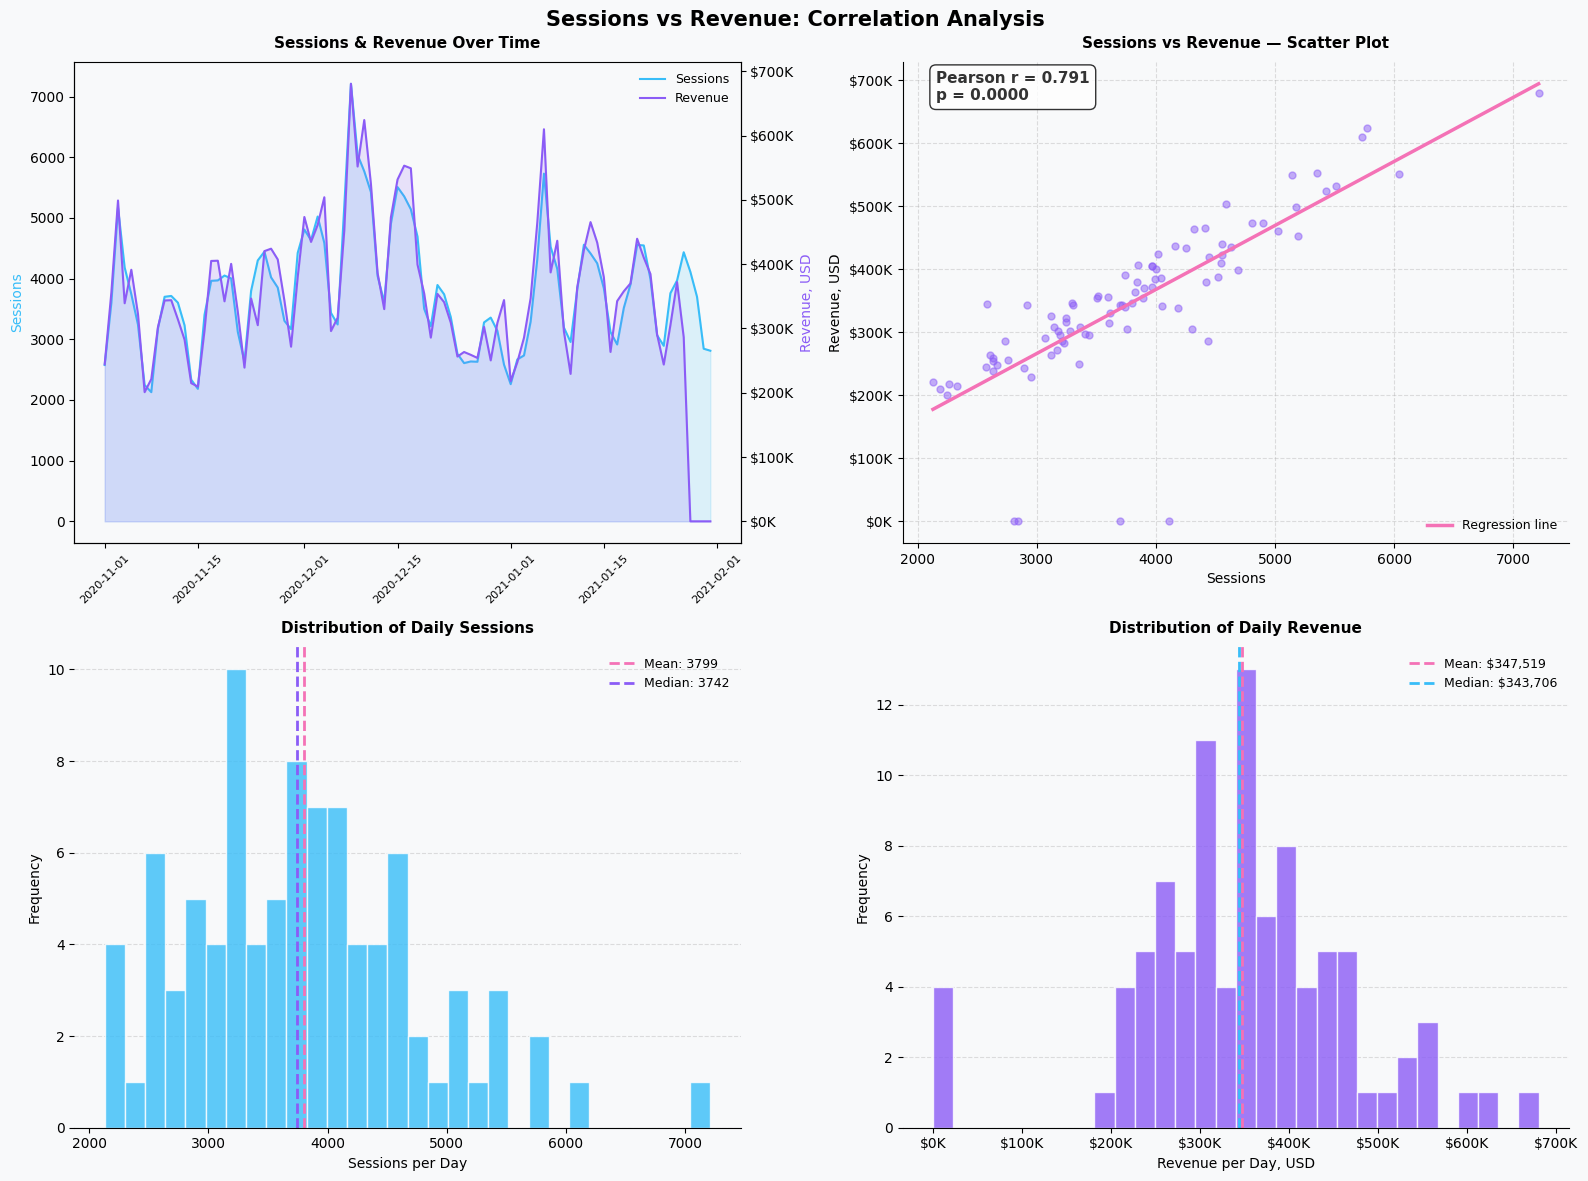

═══════════════════════════════════════════════════════
  Correlation Analysis: Sessions vs Revenue
═══════════════════════════════════════════════════════
  Pearson  r = 0.7911  |  p-value = 0.000000
  Spearman r = 0.8653  |  p-value = 0.000000
───────────────────────────────────────────────────────
  Strength    : strong positive correlation
  Significant : Yes ✓  (p < 0.05)
  R²          : 0.6258  →  sessions explain 62.6% of revenue variance
───────────────────────────────────────────────────────
  Daily sessions : min 2,129  |  max 7,212  |  mean 3,799
  Daily revenue  : min $0  |  max $680,510  |  mean $347,519
═══════════════════════════════════════════════════════


In [ ]:
from scipy import stats

# Дані
daily = (
    df.groupby("order_date")
    .agg(
        sessions=("session_id", "nunique"),
        revenue =("price",      "sum")
    )
    .reset_index()
    .sort_values("order_date")
)

# Кореляція
pearson_r,  pearson_p  = stats.pearsonr(daily["sessions"],  daily["revenue"])
spearman_r, spearman_p = stats.spearmanr(daily["sessions"], daily["revenue"])

# Фігура: 2×2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Sessions vs Revenue: Correlation Analysis",
             fontsize=15, fontweight="bold")
fig.patch.set_facecolor("#F8F9FA")
for ax in axes.flat:
    ax.set_facecolor("#F8F9FA")

# 1: подвійна вісь — сесії та виручка по датах
ax1b = axes[0, 0].twinx()

axes[0, 0].fill_between(daily["order_date"], daily["sessions"],
                         alpha=0.15, color=COLOR_ORDERS)
axes[0, 0].plot(daily["order_date"], daily["sessions"],
                color=COLOR_ORDERS, linewidth=1.5, label="Sessions")

ax1b.fill_between(daily["order_date"], daily["revenue"],
                  alpha=0.15, color=COLOR_REVENUE)
ax1b.plot(daily["order_date"], daily["revenue"],
          color=COLOR_REVENUE, linewidth=1.5, label="Revenue")

axes[0, 0].set_title("Sessions & Revenue Over Time",
                      fontsize=11, fontweight="bold", pad=10)
axes[0, 0].set_ylabel("Sessions", fontsize=10, color=COLOR_ORDERS)
ax1b.set_ylabel("Revenue, USD", fontsize=10, color=COLOR_REVENUE)
ax1b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[0, 0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0, 0].spines[["top"]].set_visible(False)

lines1, labels1 = axes[0, 0].get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
axes[0, 0].legend(lines1 + lines2, labels1 + labels2, fontsize=9, frameon=False)

# 2: scatter plot з лінією регресії
axes[0, 1].scatter(daily["sessions"], daily["revenue"],
                   color=COLOR_REVENUE, alpha=0.5, s=25, zorder=2)

# Лінія регресії
slope, intercept, *_ = stats.linregress(daily["sessions"], daily["revenue"])
x_line = np.linspace(daily["sessions"].min(), daily["sessions"].max(), 100)
axes[0, 1].plot(x_line, slope * x_line + intercept,
                color="#F472B6", linewidth=2.5, zorder=3, label="Regression line")

axes[0, 1].set_title("Sessions vs Revenue — Scatter Plot",
                      fontsize=11, fontweight="bold", pad=10)
axes[0, 1].set_xlabel("Sessions", fontsize=10)
axes[0, 1].set_ylabel("Revenue, USD", fontsize=10)
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[0, 1].grid(linestyle="--", alpha=0.4)
axes[0, 1].spines[["top", "right"]].set_visible(False)

# Підпис з коефіцієнтом
axes[0, 1].text(0.05, 0.92,
                f"Pearson r = {pearson_r:.3f}\np = {pearson_p:.4f}",
                transform=axes[0, 1].transAxes,
                fontsize=11, fontweight="bold", color="#333",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))
axes[0, 1].legend(fontsize=9, frameon=False)

# 3: розподіл сесій
axes[1, 0].hist(daily["sessions"], bins=30, color=COLOR_ORDERS,
                alpha=0.8, edgecolor="white", zorder=2)
axes[1, 0].axvline(daily["sessions"].mean(), color="#F472B6",
                   linewidth=2, linestyle="--", label=f"Mean: {daily['sessions'].mean():.0f}")
axes[1, 0].axvline(daily["sessions"].median(), color=COLOR_REVENUE,
                   linewidth=2, linestyle="--", label=f"Median: {daily['sessions'].median():.0f}")
axes[1, 0].set_title("Distribution of Daily Sessions",
                      fontsize=11, fontweight="bold", pad=10)
axes[1, 0].set_xlabel("Sessions per Day", fontsize=10)
axes[1, 0].set_ylabel("Frequency", fontsize=10)
axes[1, 0].grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
axes[1, 0].spines[["top", "right", "left"]].set_visible(False)
axes[1, 0].legend(fontsize=9, frameon=False)

# 4: розподіл виручки
axes[1, 1].hist(daily["revenue"], bins=30, color=COLOR_REVENUE,
                alpha=0.8, edgecolor="white", zorder=2)
axes[1, 1].axvline(daily["revenue"].mean(), color="#F472B6",
                   linewidth=2, linestyle="--",
                   label=f"Mean: ${daily['revenue'].mean():,.0f}")
axes[1, 1].axvline(daily["revenue"].median(), color=COLOR_ORDERS,
                   linewidth=2, linestyle="--",
                   label=f"Median: ${daily['revenue'].median():,.0f}")
axes[1, 1].set_title("Distribution of Daily Revenue",
                      fontsize=11, fontweight="bold", pad=10)
axes[1, 1].set_xlabel("Revenue per Day, USD", fontsize=10)
axes[1, 1].set_ylabel("Frequency", fontsize=10)
axes[1, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[1, 1].grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
axes[1, 1].spines[["top", "right", "left"]].set_visible(False)
axes[1, 1].legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("sessions_revenue_correlation.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Текстовий висновок
print(f"{'═' * 55}")
print(f"  Correlation Analysis: Sessions vs Revenue")
print(f"{'═' * 55}")
print(f"  Pearson  r = {pearson_r:.4f}  |  p-value = {pearson_p:.6f}")
print(f"  Spearman r = {spearman_r:.4f}  |  p-value = {spearman_p:.6f}")
print(f"{'─' * 55}")

# Інтерпретація сили
if abs(pearson_r) >= 0.7:
    strength = "strong"
elif abs(pearson_r) >= 0.4:
    strength = "moderate"
else:
    strength = "weak"

direction = "positive" if pearson_r > 0 else "negative"
significant = pearson_p < 0.05

print(f"  Strength    : {strength} {direction} correlation")
print(f"  Significant : {'Yes ✓  (p < 0.05)' if significant else 'No ✗  (p ≥ 0.05)'}")
print(f"  R²          : {pearson_r**2:.4f}  →  sessions explain {pearson_r**2*100:.1f}% of revenue variance")
print(f"{'─' * 55}")
print(f"  Daily sessions : min {daily['sessions'].min():,}  |  max {daily['sessions'].max():,}  |  mean {daily['sessions'].mean():,.0f}")
print(f"  Daily revenue  : min ${daily['revenue'].min():,.0f}  |  max ${daily['revenue'].max():,.0f}  |  mean ${daily['revenue'].mean():,.0f}")
print(f"{'═' * 55}")

Було сформовано щоденні вибірки за кількістю сесій та загальним обсягом продажів із подальшим візуальним аналізом їхнього взаємозв’язку. На діаграмі розсіювання спостерігається чітка позитивна залежність між показниками: зі зростанням кількості сесій зростає і рівень продажів.

Для оцінки сили зв’язку використано коефіцієнт кореляції Пірсона. Отримане значення свідчить про статистично значущу позитивну кореляцію між змінними (p < 0.05), що підтверджує ненульовий лінійний зв’язок між трафіком і продажами.

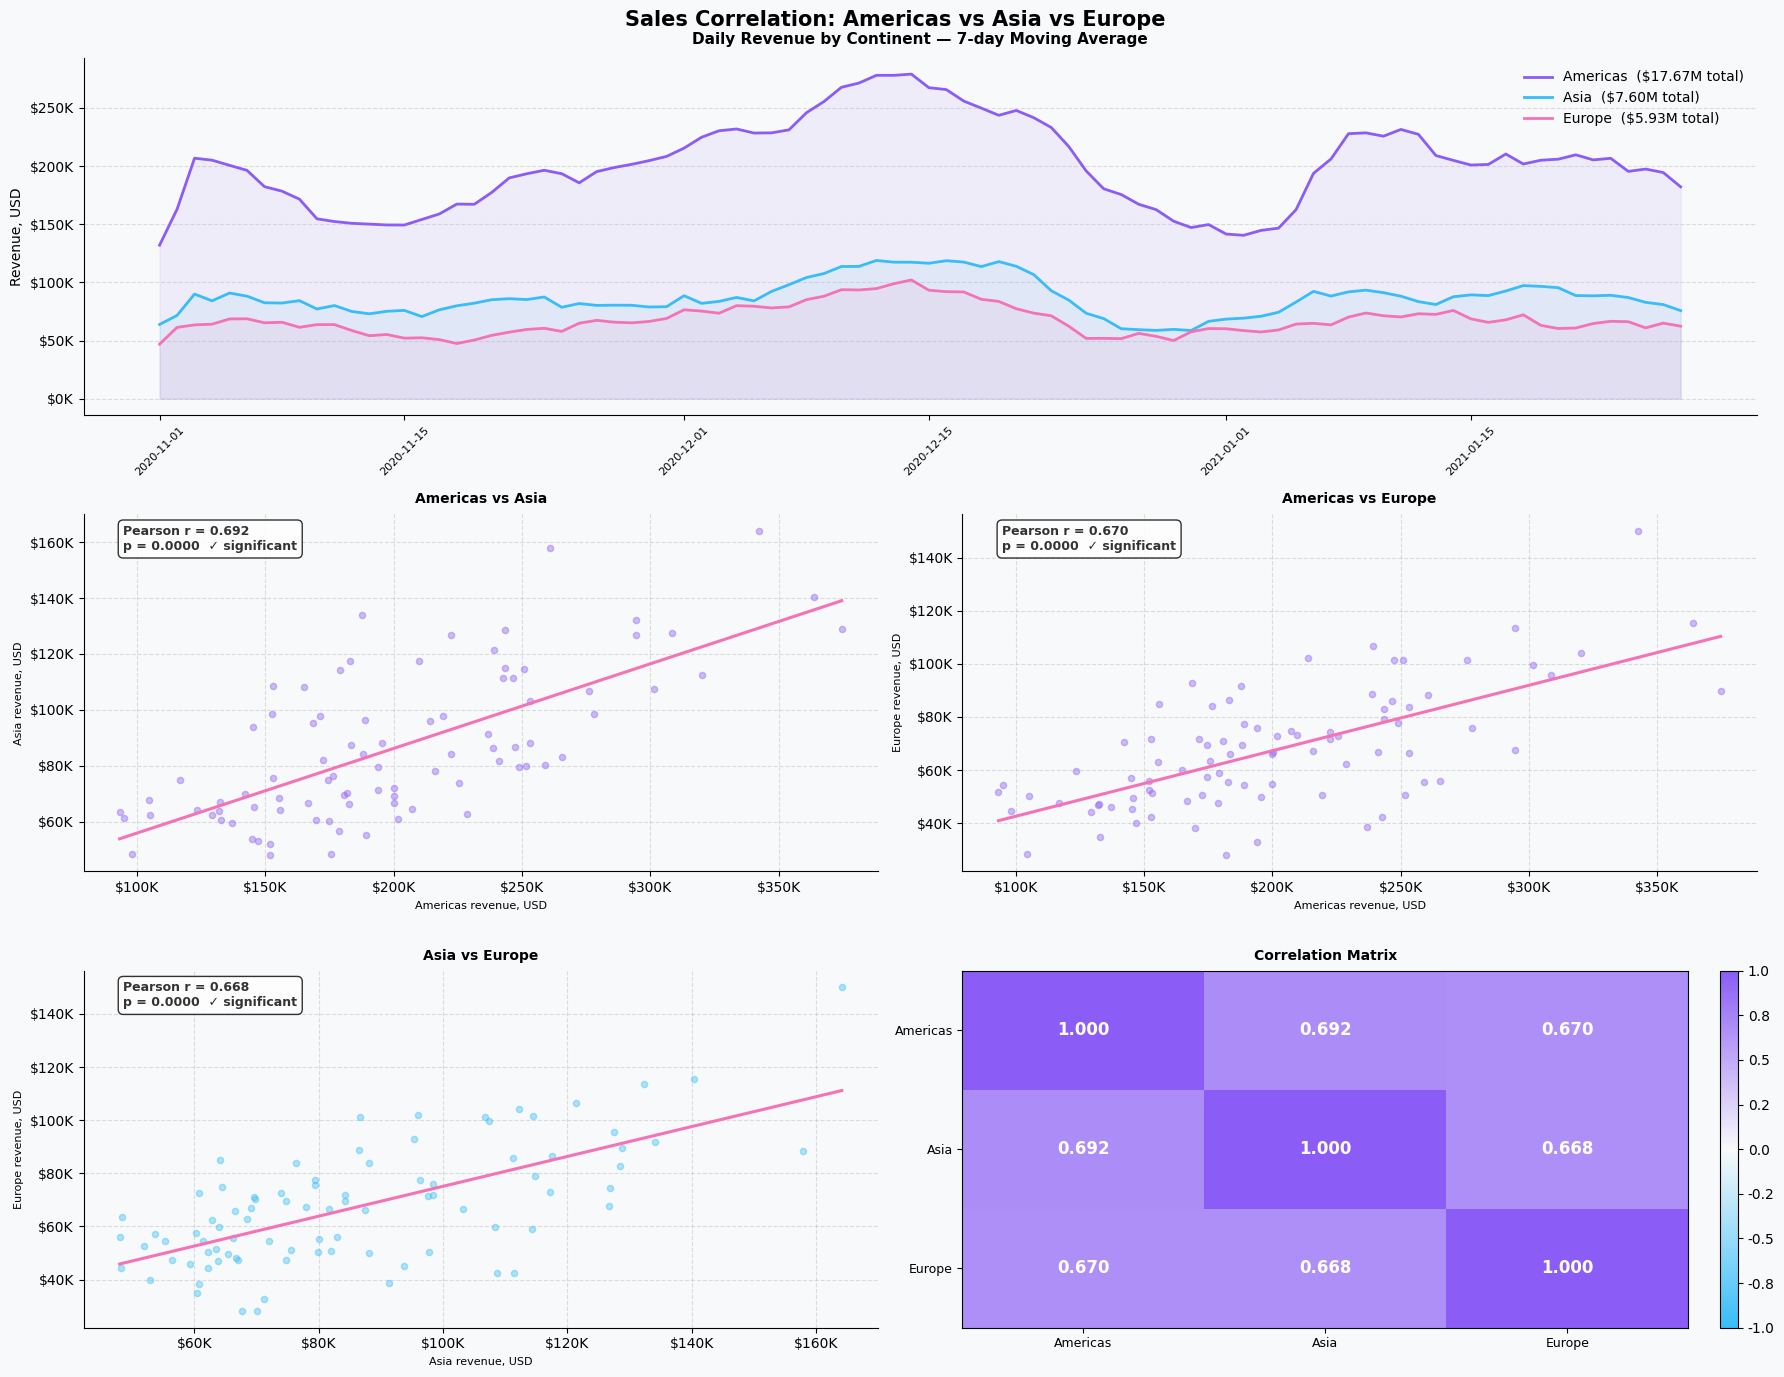

══════════════════════════════════════════════════════════════
  Correlation Analysis: Americas | Asia | Europe
══════════════════════════════════════════════════════════════

  Americas ↔ Asia
    Pearson  r = +0.6923  |  p = 0.000000  |  significant ✓
    Spearman r = +0.6685  |  p = 0.000000
    → moderate positive correlation  |  R² = 0.4792

  Americas ↔ Europe
    Pearson  r = +0.6695  |  p = 0.000000  |  significant ✓
    Spearman r = +0.6259  |  p = 0.000000
    → moderate positive correlation  |  R² = 0.4483

  Asia ↔ Europe
    Pearson  r = +0.6678  |  p = 0.000000  |  significant ✓
    Spearman r = +0.6082  |  p = 0.000000
    → moderate positive correlation  |  R² = 0.4459
══════════════════════════════════════════════════════════════


In [ ]:
# Дані
top3_continents = (
    orders_df.groupby("continent")["price"]
    .sum()
    .nlargest(3)
    .index.tolist()
)

continent_daily = (
    orders_df[orders_df["continent"].isin(top3_continents)]
    .groupby(["order_date", "continent"])["price"]
    .sum()
    .unstack(level="continent")
    .fillna(0)
    .reset_index()
)
continent_daily["order_date"] = pd.to_datetime(continent_daily["order_date"])
continent_daily = continent_daily.sort_values("order_date")

c1, c2, c3 = top3_continents

# Кореляції
pairs = [(c1, c2), (c1, c3), (c2, c3)]
corr_results = {}

for a, b in pairs:
    pearson_r,  pearson_p  = stats.pearsonr(continent_daily[a],  continent_daily[b])
    spearman_r, spearman_p = stats.spearmanr(continent_daily[a], continent_daily[b])
    corr_results[(a, b)] = {
        "pearson_r" : pearson_r,  "pearson_p" : pearson_p,
        "spearman_r": spearman_r, "spearman_p": spearman_p
    }

# Кореляційна матриця
corr_matrix = continent_daily[[c1, c2, c3]].corr()

# Фігура
fig = plt.figure(figsize=(18, 14))
fig.suptitle(f"Sales Correlation: {c1} vs {c2} vs {c3}",
             fontsize=15, fontweight="bold")
fig.patch.set_facecolor("#F8F9FA")

ax_time   = fig.add_subplot(3, 2, (1, 2))
ax_s1     = fig.add_subplot(3, 2, 3)
ax_s2     = fig.add_subplot(3, 2, 4)
ax_s3     = fig.add_subplot(3, 2, 5)
ax_heatmap= fig.add_subplot(3, 2, 6)

for ax in [ax_time, ax_s1, ax_s2, ax_s3, ax_heatmap]:
    ax.set_facecolor("#F8F9FA")

cont_colors = {c1: COLOR_REVENUE, c2: COLOR_ORDERS, c3: "#F472B6"}

# 1: часовий ряд 7d MA
for c in top3_continents:
    ma = continent_daily[c].rolling(7, min_periods=1).mean()
    ax_time.fill_between(continent_daily["order_date"], ma,
                         alpha=0.08, color=cont_colors[c])
    ax_time.plot(continent_daily["order_date"], ma,
                 color=cont_colors[c], linewidth=2,
                 label=f"{c}  (${continent_daily[c].sum()/1e6:.2f}M total)")

ax_time.set_title("Daily Revenue by Continent — 7-day Moving Average",
                  fontsize=11, fontweight="bold", pad=10)
ax_time.set_ylabel("Revenue, USD", fontsize=10)
ax_time.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax_time.tick_params(axis="x", rotation=45, labelsize=8)
ax_time.grid(axis="y", linestyle="--", alpha=0.4)
ax_time.spines[["top", "right"]].set_visible(False)
ax_time.legend(fontsize=10, frameon=False)

# 2–4: scatter plots для кожної пари
def scatter_pair(ax, x_col, y_col):
    r  = corr_results[(x_col, y_col)]
    pr = r["pearson_r"]
    pp = r["pearson_p"]

    ax.scatter(continent_daily[x_col], continent_daily[y_col],
               color=cont_colors[x_col], alpha=0.4, s=20, zorder=2)

    slope, intercept, *_ = stats.linregress(continent_daily[x_col],
                                             continent_daily[y_col])
    x_line = np.linspace(continent_daily[x_col].min(),
                         continent_daily[x_col].max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            color="#F472B6" if x_col != c3 else "#FBBF24",
            linewidth=2.2, zorder=3)

    sig = "✓ significant" if pp < 0.05 else "✗ not significant"
    ax.text(0.05, 0.90,
            f"Pearson r = {pr:.3f}\np = {pp:.4f}  {sig}",
            transform=ax.transAxes, fontsize=9, fontweight="bold",
            color="#333",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

    ax.set_title(f"{x_col} vs {y_col}", fontsize=10, fontweight="bold", pad=8)
    ax.set_xlabel(f"{x_col} revenue, USD", fontsize=8)
    ax.set_ylabel(f"{y_col} revenue, USD", fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
    ax.grid(linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

scatter_pair(ax_s1, c1, c2)
scatter_pair(ax_s2, c1, c3)
scatter_pair(ax_s3, c2, c3)

# 5: heatmap кореляційної матриці
import matplotlib.colors as mcolors

cmap = mcolors.LinearSegmentedColormap.from_list(
    "corr", ["#38BDF8", "#F8F9FA", "#8B5CF6"]
)
im = ax_heatmap.imshow(corr_matrix.values, cmap=cmap, vmin=-1, vmax=1, aspect="auto")

ax_heatmap.set_xticks(range(3))
ax_heatmap.set_yticks(range(3))
ax_heatmap.set_xticklabels(top3_continents, fontsize=9)
ax_heatmap.set_yticklabels(top3_continents, fontsize=9)
ax_heatmap.set_title("Correlation Matrix", fontsize=10, fontweight="bold", pad=8)

for i in range(3):
    for j in range(3):
        val = corr_matrix.values[i, j]
        ax_heatmap.text(j, i, f"{val:.3f}",
                        ha="center", va="center", fontsize=12,
                        fontweight="bold",
                        color="white" if abs(val) > 0.5 else "#333")

plt.colorbar(im, ax=ax_heatmap, fraction=0.046, pad=0.04,
             format=mticker.FuncFormatter(lambda x, _: f"{x:.1f}"))

plt.tight_layout()
plt.savefig("continent_correlation.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Текстовий висновок
print(f"{'═' * 62}")
print(f"  Correlation Analysis: {c1} | {c2} | {c3}")
print(f"{'═' * 62}")
for (a, b), r in corr_results.items():
    sig  = "significant ✓" if r["pearson_p"] < 0.05 else "not significant ✗"
    if abs(r["pearson_r"]) >= 0.7:   strength = "strong"
    elif abs(r["pearson_r"]) >= 0.4: strength = "moderate"
    else:                             strength = "weak"
    direction = "positive" if r["pearson_r"] > 0 else "negative"
    print(f"\n  {a} ↔ {b}")
    print(f"    Pearson  r = {r['pearson_r']:+.4f}  |  p = {r['pearson_p']:.6f}  |  {sig}")
    print(f"    Spearman r = {r['spearman_r']:+.4f}  |  p = {r['spearman_p']:.6f}")
    print(f"    → {strength} {direction} correlation  |  R² = {r['pearson_r']**2:.4f}")
print(f"{'═' * 62}")

Між продажами на всіх трьох континентах спостерігається позитивна та статистично значуща кореляція. Усі пари демонструють стабільні зв’язки на рівні p≈0.000000, що виключає випадковий характер виявлених залежностей.

Найсильніший взаємозв’язок зафіксовано між Americas та Asia (r=0.69, R²=0.48). Пари Americas–Europe та Asia–Europe мають дещо слабші, але дуже близькі значення кореляції (r≈0.67, R²≈0.45). Це свідчить про помірну синхронізацію динаміки продажів між регіонами.

Отримані результати вказують на наявність спільних глобальних факторів, які впливають на попит одночасно в різних регіонах і пояснюють приблизно половину варіації продажів. Водночас значна частина змін залишається локальною, що підтверджує роль регіональних особливостей ринків у формуванні загальної динаміки продажів.

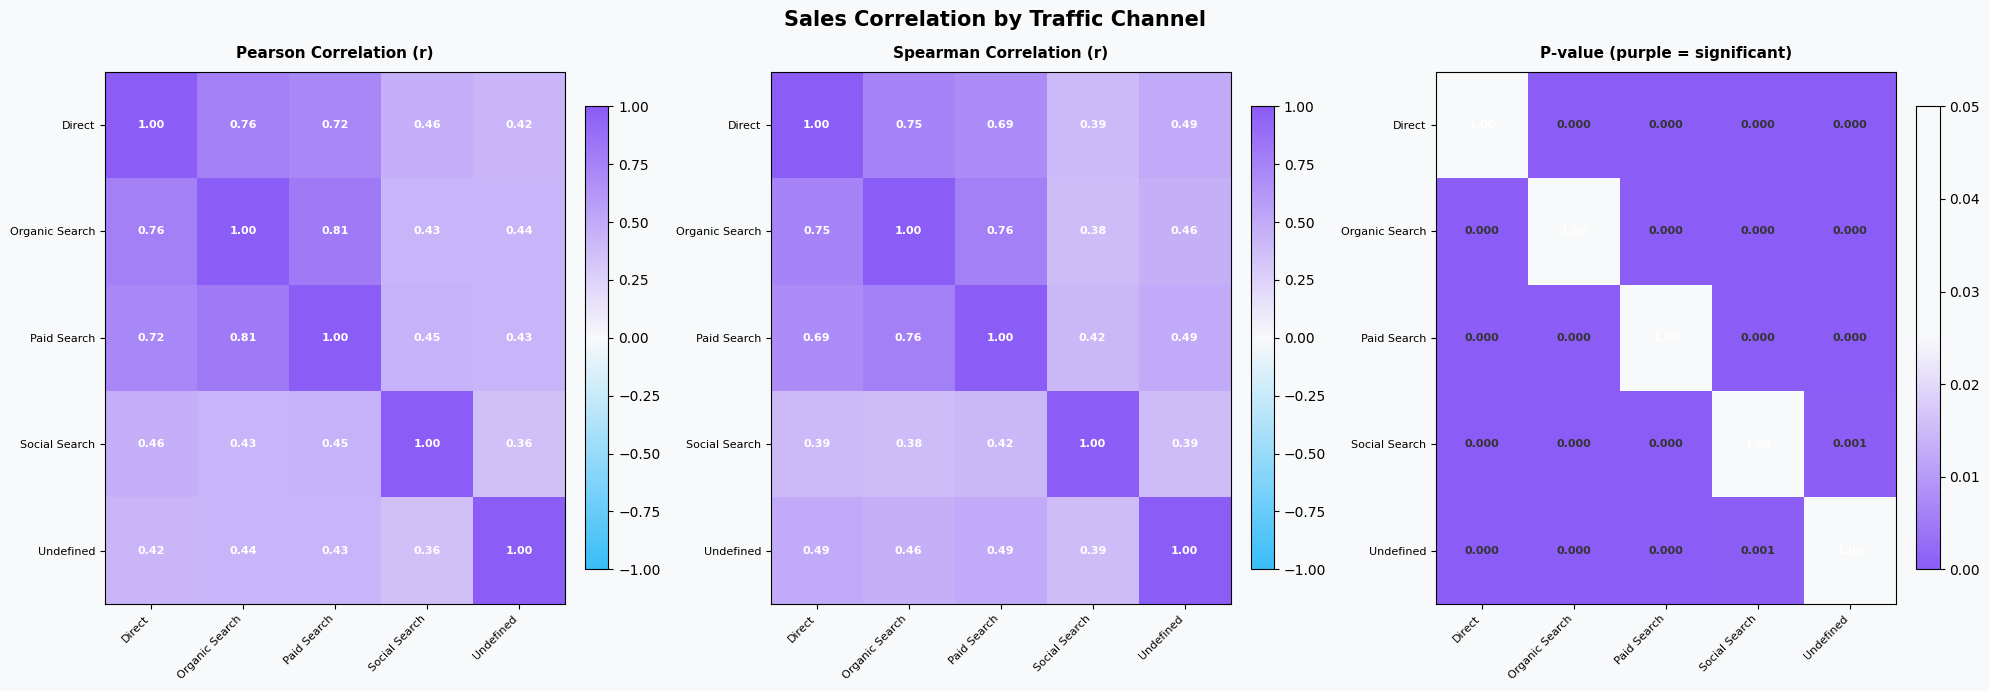

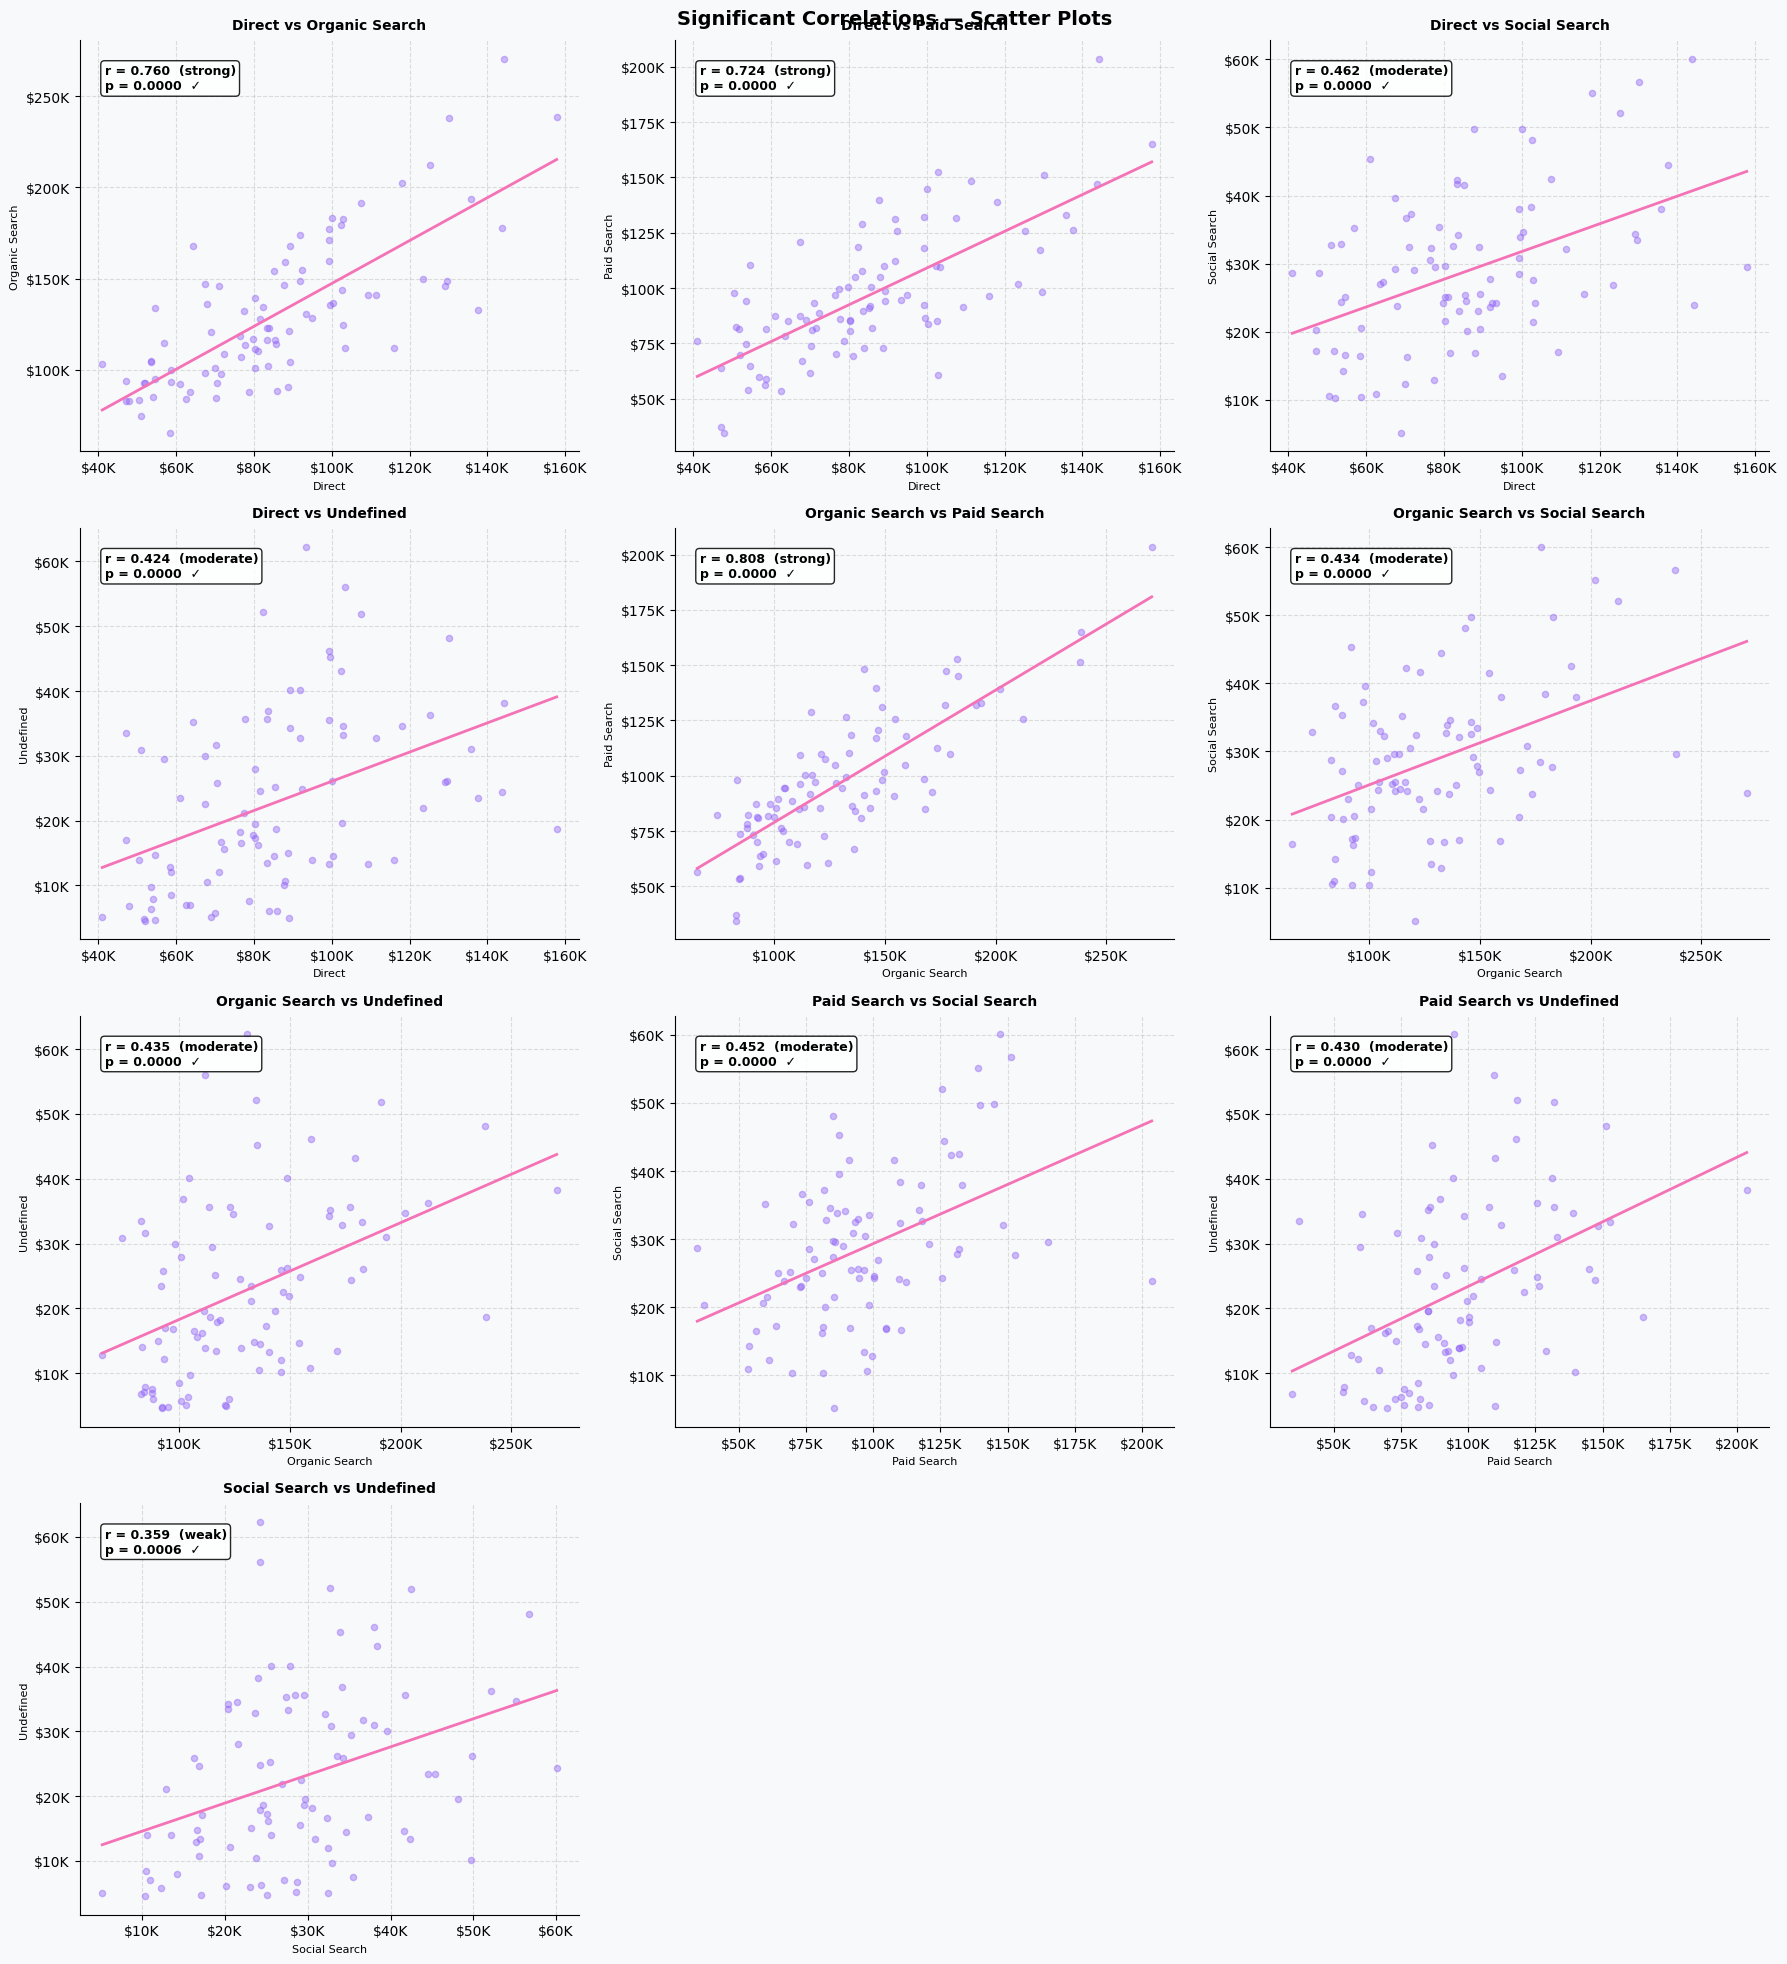

In [ ]:
# Дані
channel_daily_pivot = (
    orders_df[orders_df["traffic_channel"].notna()]
    .groupby(["order_date", "traffic_channel"])["price"]
    .sum()
    .unstack(level="traffic_channel")
    .fillna(0)
    .sort_index()
)

channels = channel_daily_pivot.columns.tolist()
n        = len(channels)

# Кореляційні матриці
corr_matrix  = channel_daily_pivot.corr(method="pearson")
pvalue_matrix = pd.DataFrame(np.ones((n, n)), index=channels, columns=channels)
spear_matrix  = pd.DataFrame(np.ones((n, n)), index=channels, columns=channels)

for i, a in enumerate(channels):
    for j, b in enumerate(channels):
        if i != j:
            pr, pp              = stats.pearsonr(channel_daily_pivot[a], channel_daily_pivot[b])
            sr, sp              = stats.spearmanr(channel_daily_pivot[a], channel_daily_pivot[b])
            pvalue_matrix.loc[a, b] = pp
            spear_matrix.loc[a, b]  = sr

# Фігура
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Sales Correlation by Traffic Channel", fontsize=15, fontweight="bold")
fig.patch.set_facecolor("#F8F9FA")
for ax in axes:
    ax.set_facecolor("#F8F9FA")

cmap_corr = mcolors.LinearSegmentedColormap.from_list(
    "corr", ["#38BDF8", "#F8F9FA", "#8B5CF6"]
)
cmap_pval = mcolors.LinearSegmentedColormap.from_list(
    "pval", ["#8B5CF6", "#F8F9FA", "#F8F9FA"]
)

def draw_heatmap(ax, matrix, title, cmap, vmin, vmax, fmt):
    im = ax.imshow(matrix.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(channels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(channels, fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    for i in range(n):
        for j in range(n):
            val = matrix.values[i, j]
            ax.text(j, i, fmt(val),
                    ha="center", va="center", fontsize=8, fontweight="bold",
                    color="white" if abs(val) > (vmax - vmin) * 0.5 + vmin else "#333")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Pearson r
draw_heatmap(axes[0], corr_matrix,
             "Pearson Correlation (r)",
             cmap_corr, -1, 1,
             lambda v: f"{v:.2f}")

# Spearman r
draw_heatmap(axes[1], spear_matrix,
             "Spearman Correlation (r)",
             cmap_corr, -1, 1,
             lambda v: f"{v:.2f}")

# P-value — з маскою значущості
sig_mask = pvalue_matrix.copy()
draw_heatmap(axes[2], sig_mask,
             "P-value (purple = significant)",
             cmap_pval, 0, 0.05,
             lambda v: f"{v:.3f}" if v < 0.05 else f"{v:.2f}")

plt.tight_layout()
plt.savefig("channel_correlation.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Scatter plots для значущих пар
sig_pairs = [
    (a, b) for i, a in enumerate(channels)
    for j, b in enumerate(channels)
    if i < j and pvalue_matrix.loc[a, b] < 0.05
]

if sig_pairs:
    cols = 3
    rows = (len(sig_pairs) + cols - 1) // cols
    fig2, axes2 = plt.subplots(rows, cols, figsize=(18, rows * 5))
    fig2.suptitle("Significant Correlations — Scatter Plots", fontsize=14, fontweight="bold")
    fig2.patch.set_facecolor("#F8F9FA")


    axes2_flat = np.array(axes2).flatten()

    for idx, (a, b) in enumerate(sig_pairs):
        ax = axes2_flat[idx]
        ax.set_facecolor("#F8F9FA")
        pr, pp = stats.pearsonr(channel_daily_pivot[a], channel_daily_pivot[b])

        ax.scatter(channel_daily_pivot[a], channel_daily_pivot[b],
                   color=COLOR_REVENUE, alpha=0.4, s=20, zorder=2)

        slope, intercept, *_ = stats.linregress(channel_daily_pivot[a],
                                                  channel_daily_pivot[b])
        x_line = np.linspace(channel_daily_pivot[a].min(),
                              channel_daily_pivot[a].max(), 100)
        ax.plot(x_line, slope * x_line + intercept,
                color="#F472B6", linewidth=2, zorder=3)

        if abs(pr) >= 0.7:   strength = "strong"
        elif abs(pr) >= 0.4: strength = "moderate"
        else:                 strength = "weak"

        ax.text(0.05, 0.88,
                f"r = {pr:.3f}  ({strength})\np = {pp:.4f}  ✓",
                transform=ax.transAxes, fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

        ax.set_title(f"{a} vs {b}", fontsize=10, fontweight="bold", pad=8)
        ax.set_xlabel(a, fontsize=8)
        ax.set_ylabel(b, fontsize=8)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
        ax.grid(linestyle="--", alpha=0.4)
        ax.spines[["top", "right"]].set_visible(False)

    # прибираємо порожні субплоти
    for idx in range(len(sig_pairs), rows * cols):
        axes2_flat[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig("channel_correlation_scatter.png", dpi=150,
                bbox_inches="tight", facecolor=fig2.get_facecolor())
    plt.show()

else:
    print("No statistically significant correlations found (p < 0.05).")
    print("This means channel sales move independently of each other.")

Між усіма каналами трафіку спостерігається позитивна та статистично значуща кореляція продажів. У більшості пар значущість підтверджується на рівні p≈0.000, що вказує на стабільність взаємозв’язків між каналами.

Найсильніші зв’язки зафіксовано між Organic Search і Paid Search (r=0.81), а також між Direct та Organic Search (r=0.76) і Direct та Paid Search (r=0.72). Це свідчить про синхронний характер поведінки основних каналів залучення, які, ймовірно, реагують на спільні фактори попиту та маркетингової активності.

Social та Undefined демонструють слабші, але все ще статистично значущі кореляції з іншими каналами (r=0.36–0.46). Це вказує на часткову залежність від загальних ринкових трендів при одночасному збереженні власної динаміки, менш пов’язаної з пошуковими каналами.

У цілому структура взаємозв’язків підтверджує наявність єдиного макротренду попиту, який впливає на всі канали, але з різною силою залежно від їхньої природи та механіки залучення користувачів.

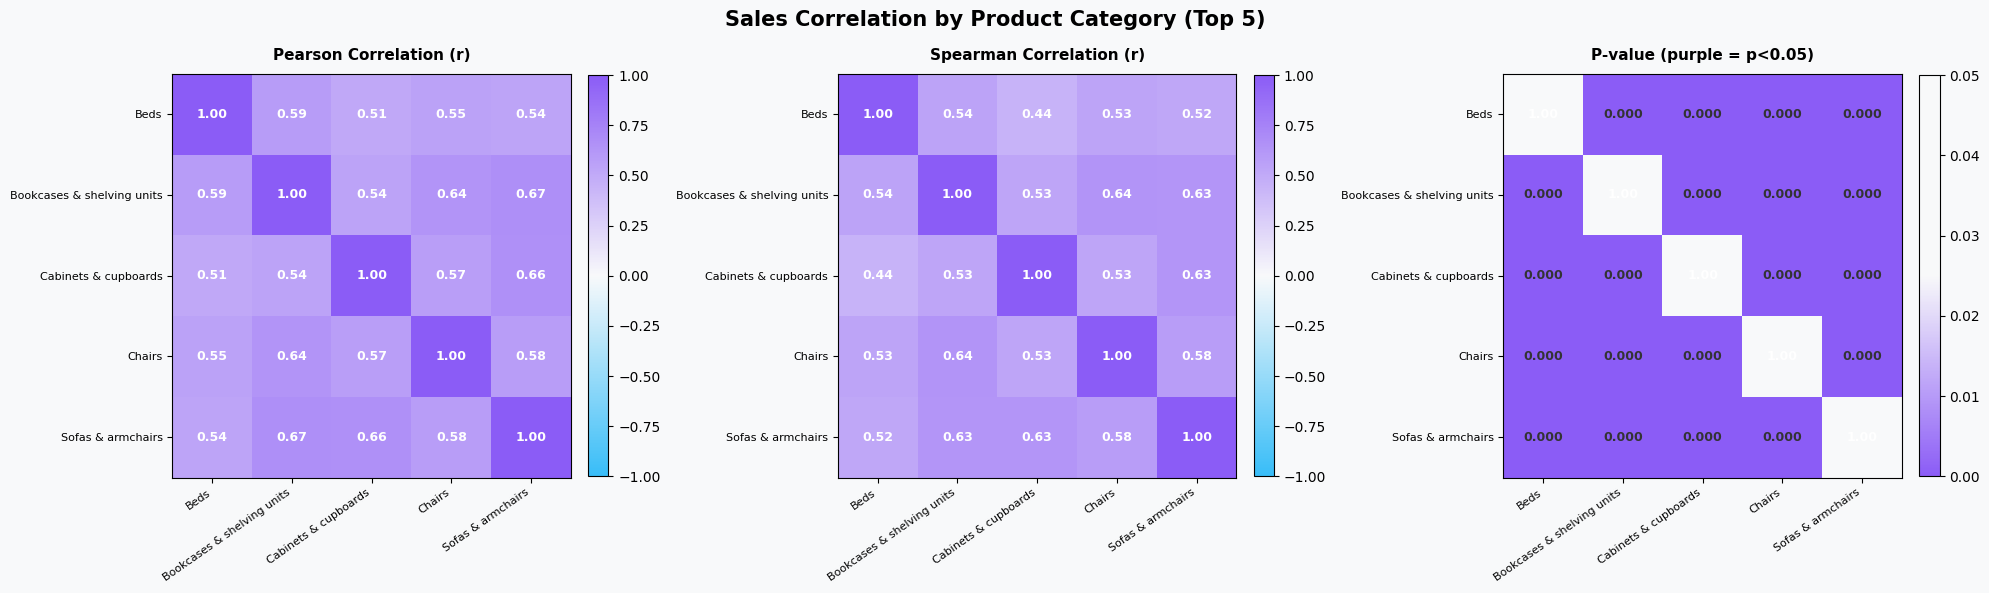

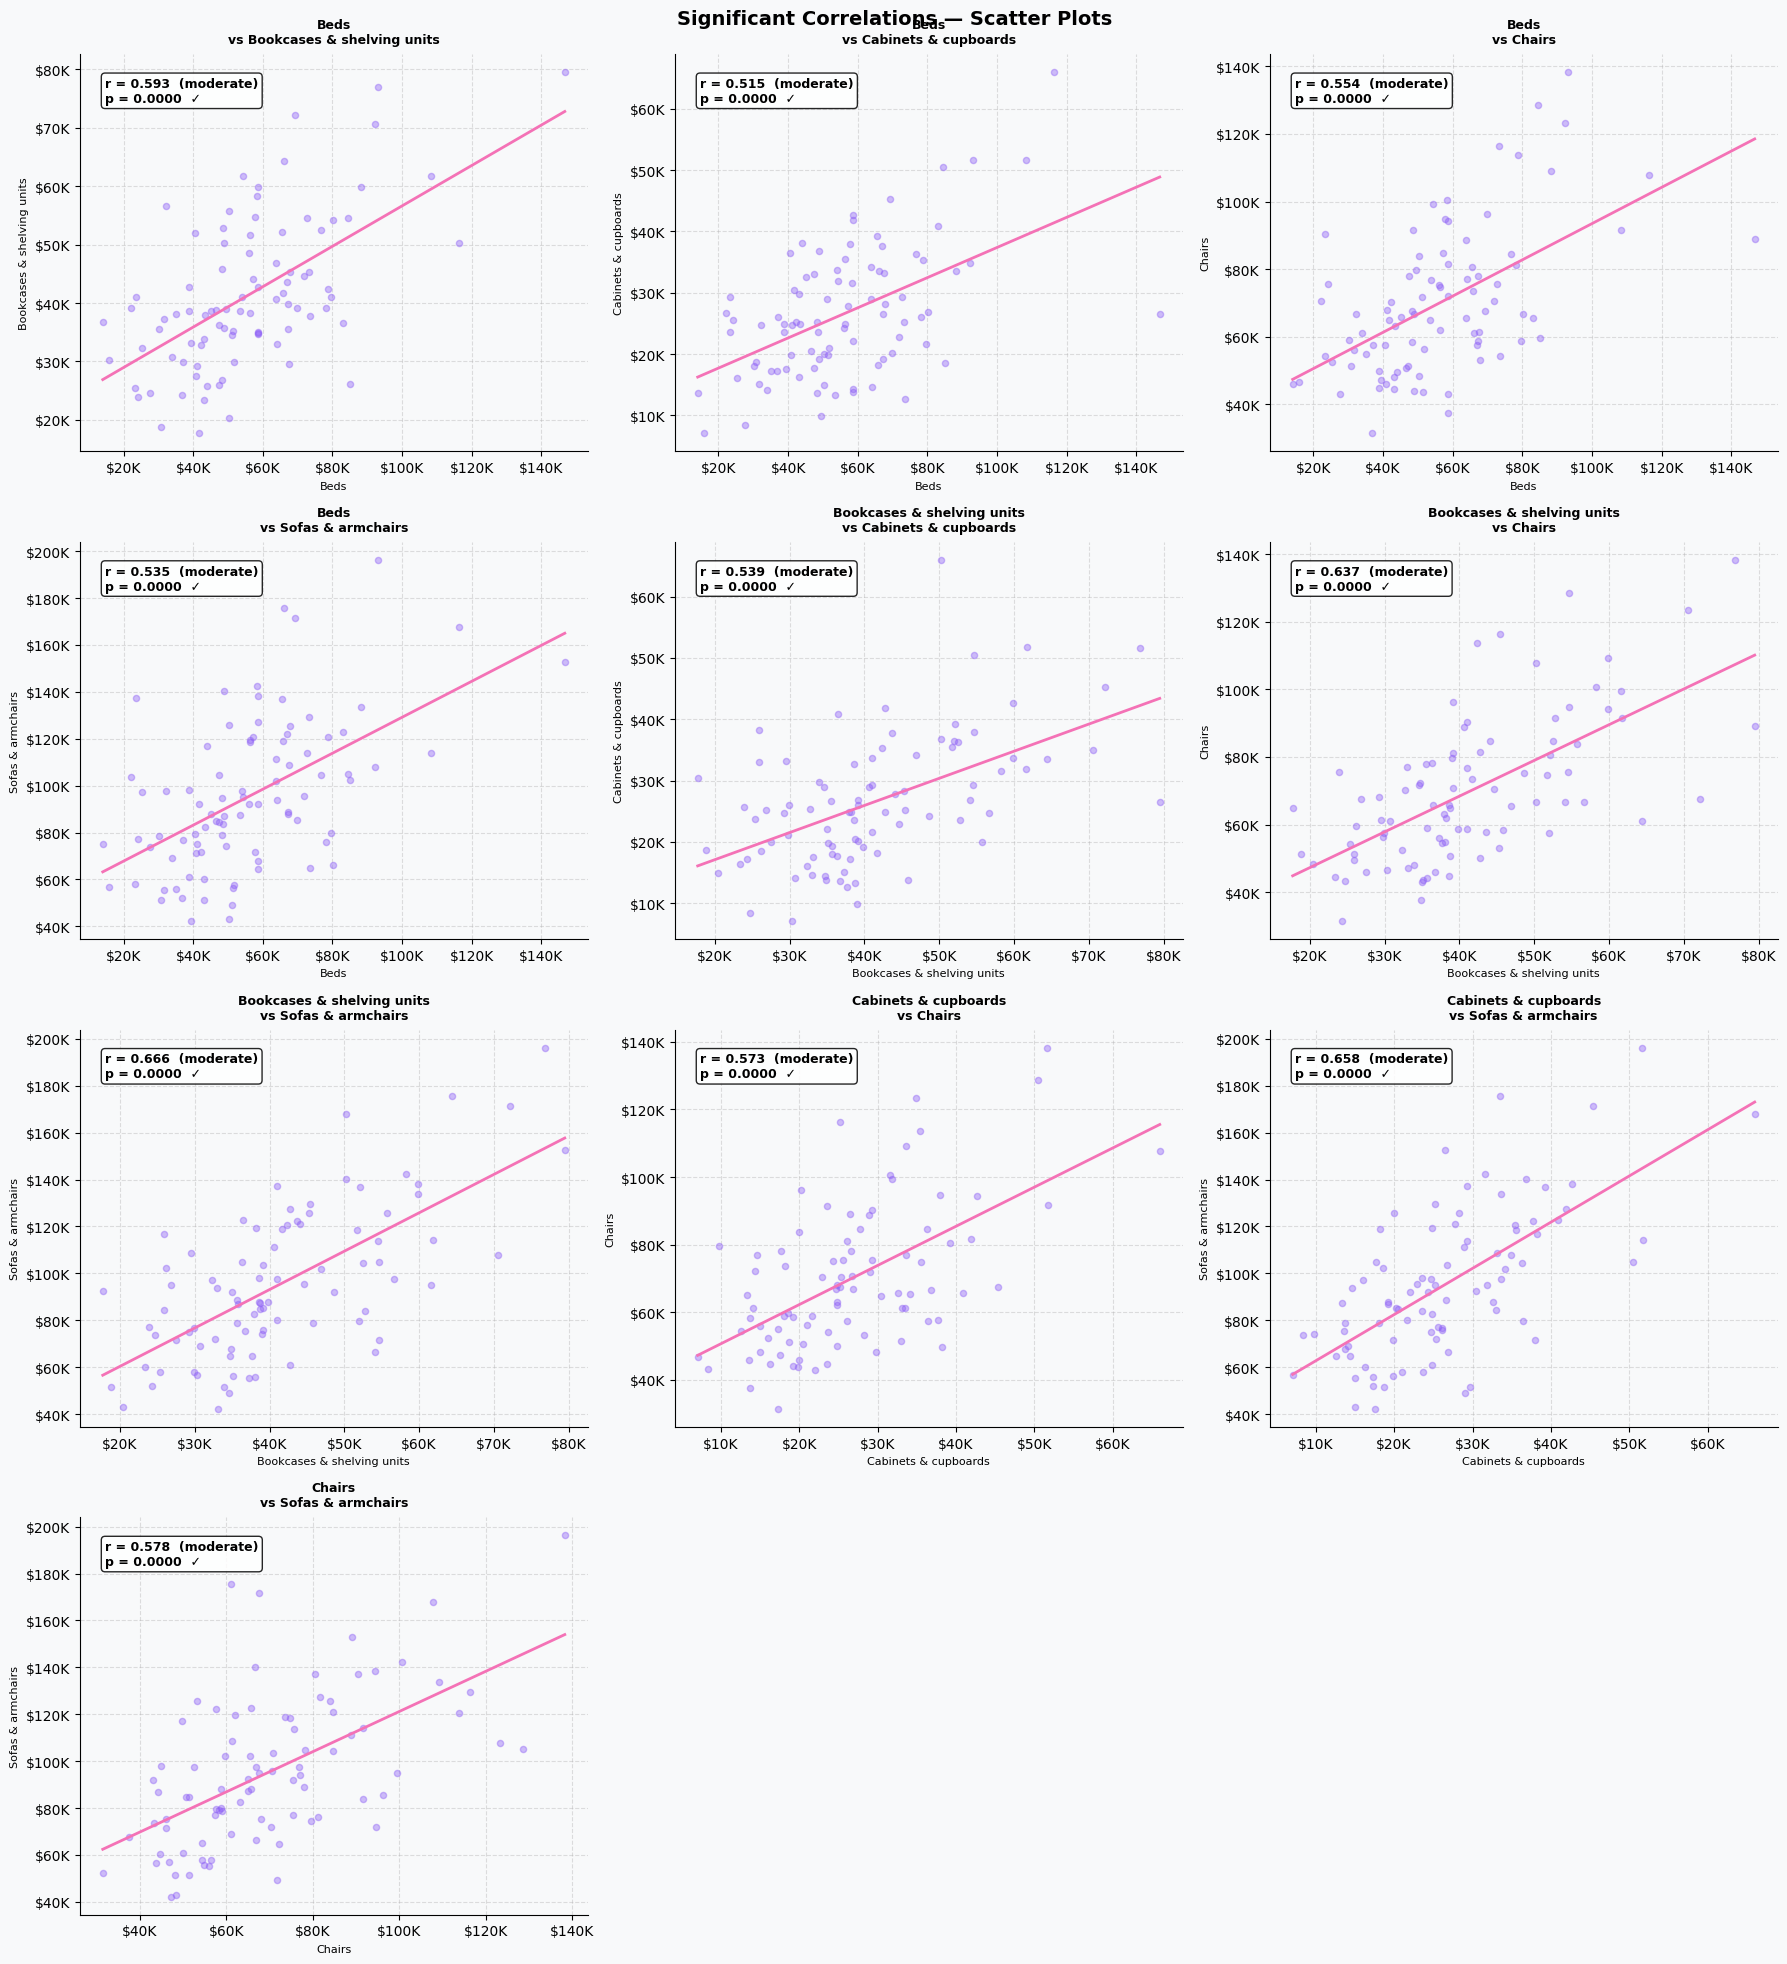

═════════════════════════════════════════════════════════════════
  Category Correlation Summary (Top 5)
═════════════════════════════════════════════════════════════════

  Beds ↔ Bookcases & shelving units
    Pearson  r = +0.5929  |  p = 0.0000  ✓
    Spearman r = +0.5427
    → moderate positive correlation

  Beds ↔ Cabinets & cupboards
    Pearson  r = +0.5146  |  p = 0.0000  ✓
    Spearman r = +0.4404
    → moderate positive correlation

  Beds ↔ Chairs
    Pearson  r = +0.5545  |  p = 0.0000  ✓
    Spearman r = +0.5349
    → moderate positive correlation

  Beds ↔ Sofas & armchairs
    Pearson  r = +0.5354  |  p = 0.0000  ✓
    Spearman r = +0.5217
    → moderate positive correlation

  Bookcases & shelving units ↔ Cabinets & cupboards
    Pearson  r = +0.5394  |  p = 0.0000  ✓
    Spearman r = +0.5287
    → moderate positive correlation

  Bookcases & shelving units ↔ Chairs
    Pearson  r = +0.6371  |  p = 0.0000  ✓
    Spearman r = +0.6368
    → moderate positive correlation


In [ ]:
# Дані
top5_cats = (
    orders_df.groupby("product_category")["price"]
    .sum()
    .nlargest(5)
    .index.tolist()
)

category_daily_pivot = (
    orders_df[orders_df["product_category"].isin(top5_cats)]
    .groupby(["order_date", "product_category"])["price"]
    .sum()
    .unstack(level="product_category")
    .fillna(0)
    .sort_index()
)

cats = category_daily_pivot.columns.tolist()
n    = len(cats)

# Кореляційні матриці
corr_matrix   = category_daily_pivot.corr(method="pearson")
pvalue_matrix = pd.DataFrame(np.ones((n, n)), index=cats, columns=cats)
spear_matrix  = pd.DataFrame(np.ones((n, n)), index=cats, columns=cats)

for i, a in enumerate(cats):
    for j, b in enumerate(cats):
        if i != j:
            pr, pp              = stats.pearsonr(category_daily_pivot[a],  category_daily_pivot[b])
            sr, _               = stats.spearmanr(category_daily_pivot[a], category_daily_pivot[b])
            pvalue_matrix.loc[a, b] = pp
            spear_matrix.loc[a, b]  = sr

sig_pairs = [
    (a, b) for i, a in enumerate(cats)
    for j, b in enumerate(cats)
    if i < j and pvalue_matrix.loc[a, b] < 0.05
]

# Фігура 1: три heatmaps
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Sales Correlation by Product Category (Top 5)",
             fontsize=15, fontweight="bold")
fig.patch.set_facecolor("#F8F9FA")
for ax in axes:
    ax.set_facecolor("#F8F9FA")

cmap_corr = mcolors.LinearSegmentedColormap.from_list(
    "corr", ["#38BDF8", "#F8F9FA", "#8B5CF6"]
)
cmap_pval = mcolors.LinearSegmentedColormap.from_list(
    "pval", ["#8B5CF6", "#F8F9FA", "#F8F9FA"]
)

def draw_heatmap(ax, matrix, title, cmap, vmin, vmax, fmt):
    im = ax.imshow(matrix.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(cats, rotation=35, ha="right", fontsize=8)
    ax.set_yticklabels(cats, fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    for i in range(n):
        for j in range(n):
            val = matrix.values[i, j]
            ax.text(j, i, fmt(val), ha="center", va="center",
                    fontsize=9, fontweight="bold",
                    color="white" if abs(val) > (vmax - vmin) * 0.5 + vmin else "#333")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

draw_heatmap(axes[0], corr_matrix,
             "Pearson Correlation (r)",   cmap_corr, -1,   1,    lambda v: f"{v:.2f}")
draw_heatmap(axes[1], spear_matrix,
             "Spearman Correlation (r)",  cmap_corr, -1,   1,    lambda v: f"{v:.2f}")
draw_heatmap(axes[2], pvalue_matrix,
             "P-value (purple = p<0.05)", cmap_pval,  0,  0.05,  lambda v: f"{v:.3f}" if v < 0.05 else f"{v:.2f}")

plt.tight_layout()
plt.savefig("category_correlation_heatmap.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Фігура 2: scatter plots для значущих пар
if sig_pairs:
    cols       = 3
    rows       = (len(sig_pairs) + cols - 1) // cols
    fig2, axes2 = plt.subplots(rows, cols, figsize=(18, rows * 5))
    fig2.suptitle("Significant Correlations — Scatter Plots",
                  fontsize=14, fontweight="bold")
    fig2.patch.set_facecolor("#F8F9FA")
    axes2_flat = np.array(axes2).flatten()

    for idx, (a, b) in enumerate(sig_pairs):
        ax     = axes2_flat[idx]
        ax.set_facecolor("#F8F9FA")
        pr, pp = stats.pearsonr(category_daily_pivot[a], category_daily_pivot[b])

        ax.scatter(category_daily_pivot[a], category_daily_pivot[b],
                   color=COLOR_REVENUE, alpha=0.4, s=20, zorder=2)

        slope, intercept, *_ = stats.linregress(category_daily_pivot[a],
                                                  category_daily_pivot[b])
        x_line = np.linspace(category_daily_pivot[a].min(),
                              category_daily_pivot[a].max(), 100)
        ax.plot(x_line, slope * x_line + intercept,
                color="#F472B6", linewidth=2, zorder=3)

        if abs(pr) >= 0.7:   strength = "strong"
        elif abs(pr) >= 0.4: strength = "moderate"
        else:                 strength = "weak"

        ax.text(0.05, 0.88,
                f"r = {pr:.3f}  ({strength})\np = {pp:.4f}  ✓",
                transform=ax.transAxes, fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

        ax.set_title(f"{a}\nvs {b}", fontsize=9, fontweight="bold", pad=8)
        ax.set_xlabel(a, fontsize=8)
        ax.set_ylabel(b, fontsize=8)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
        ax.grid(linestyle="--", alpha=0.4)
        ax.spines[["top", "right"]].set_visible(False)

    for idx in range(len(sig_pairs), rows * cols):
        axes2_flat[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig("category_correlation_scatter.png", dpi=150,
                bbox_inches="tight", facecolor=fig2.get_facecolor())
    plt.show()

else:
    print("No statistically significant correlations found (p < 0.05).")

# Текстовий висновок
print(f"{'═' * 65}")
print(f"  Category Correlation Summary (Top 5)")
print(f"{'═' * 65}")
for i, a in enumerate(cats):
    for j, b in enumerate(cats):
        if i < j:
            pr  = corr_matrix.loc[a, b]
            pp  = pvalue_matrix.loc[a, b]
            sr  = spear_matrix.loc[a, b]
            sig = "✓" if pp < 0.05 else "✗"
            if abs(pr) >= 0.7:   strength = "strong"
            elif abs(pr) >= 0.4: strength = "moderate"
            else:                 strength = "weak"
            direction = "positive" if pr > 0 else "negative"
            print(f"\n  {a} ↔ {b}")
            print(f"    Pearson  r = {pr:+.4f}  |  p = {pp:.4f}  {sig}")
            print(f"    Spearman r = {sr:+.4f}")
            print(f"    → {strength} {direction} correlation")
print(f"{'═' * 65}")
print(f"\n  Significant pairs (p < 0.05): {len(sig_pairs)} of {n*(n-1)//2}")

Між усіма топ-5 категоріями товарів зафіксовано помірну позитивну кореляцію продажів. Значення коефіцієнта Пірсона знаходяться в діапазоні 0.51–0.67, що вказує на синхронний рух продажів між категоріями.

Найсильніші зв’язки спостерігаються між категоріями Sofas & Armchairs та Bookcases (r=0.67), а також Sofas & Armchairs та Cabinets (r=0.66). Найслабша, але все ще помірна кореляція зафіксована між Beds та Cabinets (r=0.51).

Результати Spearman-кореляції є дещо нижчими (0.44–0.64), що може свідчити про наявність викидів або часткову нелінійність зв’язків, однак загальна структура взаємозв’язків зберігається. Статистична значущість підтверджена для всіх пар (p < 0.05), що вказує на стабільність виявлених залежностей.

Отримані результати свідчать про узгоджений рух продажів між більшістю товарних категорій, що може бути зумовлено спільними зовнішніми факторами попиту. Водночас категорія Beds демонструє відносно слабші зв’язки з іншими сегментами, що потенційно пов’язано з відмінним циклом прийняття рішення про покупку.

                 count    mean    std    min    25%    50%    75%    max  skew  kurt
Зареєстровані     88.0    31.6    9.6   16.0   24.0   30.5   37.5   67.0  0.66  0.77
Незареєстровані   88.0  349.51  88.56  195.0  284.5  334.5  400.5  622.0  0.68  0.32


/tmp/ipykernel_18723/3508203967.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([reg, unreg], patch_artist=True,


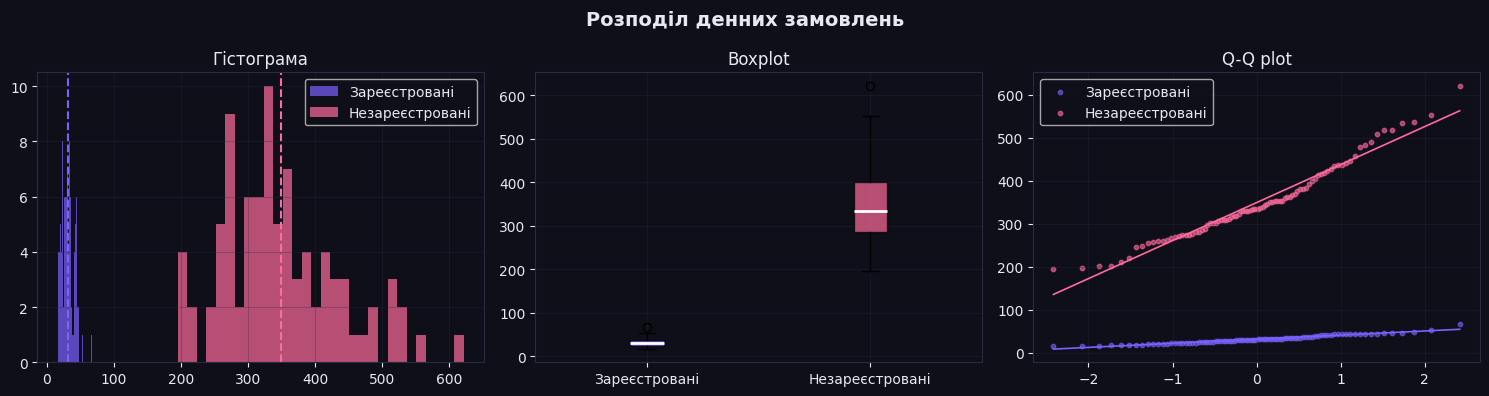

Shapiro-Wilk:
  Зареєстровані  : p=5.72e-03 → не нормальний
  Незареєстровані: p=1.33e-02 → не нормальний

Тест: Mann-Whitney U
  stat=0.0000, p=2.18e-30
  Cohen's d=-5.047 (великий ефект)

Різниця ЗНАЧУЩА (α=0.05)
   Замовлення зареєстрованих нижчі, ніж незареєстрованих
   Різниця середніх: -317.91


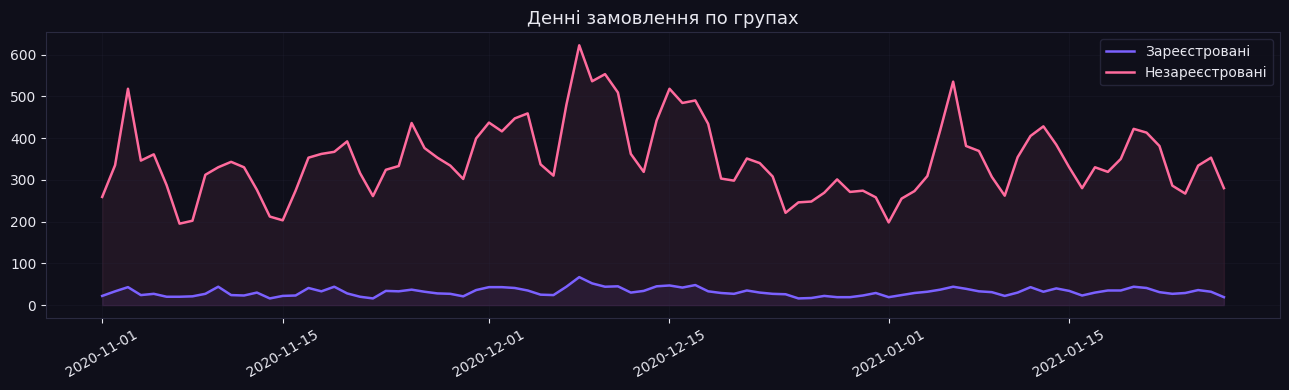

In [ ]:
from google.colab import auth
auth.authenticate_user()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from google.cloud import bigquery

client = bigquery.Client(project='data-analytics-mate')

# Денні продажі по групах
df = client.query("""
    SELECT
        s.date,
        CASE WHEN a.account_id IS NOT NULL THEN 'registered' ELSE 'unregistered' END AS user_type,
        COUNT(o.item_id) AS daily_orders
    FROM `data-analytics-mate.DA.session` s
    LEFT JOIN `data-analytics-mate.DA.account_session` a USING (ga_session_id)
    LEFT JOIN `data-analytics-mate.DA.order` o USING (ga_session_id)
    WHERE o.item_id IS NOT NULL
    GROUP BY 1, 2
""").to_dataframe()

df['date'] = pd.to_datetime(df['date'])

reg   = df[df['user_type'] == 'registered']['daily_orders']
unreg = df[df['user_type'] == 'unregistered']['daily_orders']

# Базова статистика
stats_df = pd.DataFrame({
    'Зареєстровані':   reg.describe(),
    'Незареєстровані': unreg.describe()
}).T
stats_df['skew'] = [reg.skew(), unreg.skew()]
stats_df['kurt'] = [reg.kurtosis(), unreg.kurtosis()]
print(stats_df.round(2).to_string())

# Візуалізація розподілів
C_REG, C_UNREG, C_BG = '#7B61FF', '#FF6B9D', '#0F0F1A'
plt.rcParams.update({'figure.facecolor': C_BG, 'axes.facecolor': C_BG,
                     'text.color': '#E8E8F0', 'axes.labelcolor': '#E8E8F0',
                     'xtick.color': '#E8E8F0', 'ytick.color': '#E8E8F0',
                     'axes.edgecolor': '#2A2A40', 'grid.color': '#2A2A40'})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Розподіл денних замовлень', fontsize=14, fontweight='bold')

for data, color, label in [(reg, C_REG, 'Зареєстровані'), (unreg, C_UNREG, 'Незареєстровані')]:
    axes[0].hist(data, bins=30, color=color, alpha=0.7, label=label)
    axes[0].axvline(data.mean(), color=color, ls='--', lw=1.5)
axes[0].set_title('Гістограма'); axes[0].legend(); axes[0].grid(alpha=0.3)

bp = axes[1].boxplot([reg, unreg], patch_artist=True,
                     labels=['Зареєстровані', 'Незареєстровані'],
                     medianprops=dict(color='white', lw=2))
for patch, c in zip(bp['boxes'], [C_REG, C_UNREG]):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_title('Boxplot'); axes[1].grid(alpha=0.3)

for data, color, label in [(reg, C_REG, 'Зареєстровані'), (unreg, C_UNREG, 'Незареєстровані')]:
    (osm, osr), (slope, intercept, _) = stats.probplot(data, dist='norm')
    axes[2].scatter(osm, osr, color=color, s=10, alpha=0.6, label=label)
    axes[2].plot(osm, slope*np.array(osm)+intercept, color=color, lw=1.2)
axes[2].set_title('Q-Q plot'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Нормальність (Shapiro-Wilk) + вибір тесту
def shapiro(s, name):
    _, p = stats.shapiro(s.sample(min(len(s), 4999), random_state=42))
    print(f"  {name}: p={p:.2e} → {'нормальний' if p > 0.05 else 'не нормальний'}")
    return p > 0.05

print('Shapiro-Wilk:')
reg_norm   = shapiro(reg,   'Зареєстровані  ')
unreg_norm = shapiro(unreg, 'Незареєстровані')

if reg_norm and unreg_norm:
    test_name, stat, p = 't-тест Велша', *stats.ttest_ind(reg, unreg, equal_var=False)
else:
    test_name, stat, p = 'Mann-Whitney U', *stats.mannwhitneyu(reg, unreg, alternative='two-sided')

d = (reg.mean() - unreg.mean()) / np.sqrt((reg.std()**2 + unreg.std()**2) / 2)
magnitude = 'малий' if abs(d) < 0.2 else 'середній' if abs(d) < 0.5 else 'великий'

print(f"\nТест: {test_name}")
print(f"  stat={stat:.4f}, p={p:.2e}")
print(f"  Cohen's d={d:.3f} ({magnitude} ефект)")
print(f"\n{'Різниця ЗНАЧУЩА' if p < 0.05 else 'Різниця НЕ значуща'} (α=0.05)")
if p < 0.05:
    direction = 'вищі' if reg.mean() > unreg.mean() else 'нижчі'
    print(f"   Замовлення зареєстрованих {direction}, ніж незареєстрованих")
    print(f"   Різниця середніх: {reg.mean() - unreg.mean():.2f}")

# Динаміка замовлень по датах
fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor(C_BG); ax.set_facecolor(C_BG)

for utype, color, label in [('registered', C_REG, 'Зареєстровані'), ('unregistered', C_UNREG, 'Незареєстровані')]:
    s = df[df['user_type'] == utype].sort_values('date')
    ax.plot(s['date'], s['daily_orders'], color=color, lw=1.8, label=label)
    ax.fill_between(s['date'], s['daily_orders'], color=color, alpha=0.08)

ax.set_title('Денні замовлення по групах', fontsize=13)
ax.legend(facecolor=C_BG, edgecolor='#2A2A40', labelcolor='#E8E8F0')
ax.grid(alpha=0.2); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

Розподіли денних продажів у двох групах суттєво відрізняються та не відповідають нормальному закону розподілу (Shapiro-Wilk: p=0.0057 та p=0.013), що підтверджується формою гістограм і відхиленнями Q-Q plot.

Незареєстровані користувачі демонструють значно вищі значення продажів (mean=349) порівняно із зареєстрованими (mean=31.6), при цьому розподіли повністю не перетинаються, що вказує на виражену різницю між групами.

Для перевірки статистичної значущості використано непараметричний тест Mann–Whitney U як коректний метод для ненормальних розподілів. Результати тесту показали U=0 та p=2.18e-30, що свідчить про наявність статистично значущої різниці між групами. Розмір ефекту є екстремально високим (Cohen's d = −5.047).

Отримані результати підтверджують, що незареєстровані користувачі генерують суттєво більший обсяг продажів у порівнянні з зареєстрованими, і ця різниця є стабільною в часі без ознак перекриття розподілів.

In [ ]:
# Сесії за каналами трафіку
df_ch = client.query("""
    SELECT
        s.date,
        sp.channel,
        COUNT(DISTINCT s.ga_session_id) AS daily_sessions
    FROM `data-analytics-mate.DA.session` s
    LEFT JOIN `data-analytics-mate.DA.session_params` sp USING (ga_session_id)
    WHERE sp.channel IS NOT NULL
    GROUP BY 1, 2
""").to_dataframe()

df_ch['date'] = pd.to_datetime(df_ch['date'])

print(df_ch['channel'].value_counts())
print(f"\nУнікальних каналів: {df_ch['channel'].nunique()}")
print(df_ch.head())

channel
Paid Search       92
Organic Search    92
Direct            92
Undefined         92
Social Search     92
Name: count, dtype: int64

Унікальних каналів: 5
        date         channel  daily_sessions
0 2020-11-01     Paid Search             706
1 2020-11-01  Organic Search             920
2 2020-11-01          Direct             608
3 2020-11-01       Undefined             128
4 2020-11-01   Social Search             214


Розподіл кількості сесій між каналами трафіку є статистично неоднорідним. Органічний пошук стабільно формує найбільший обсяг трафіку та суттєво перевищує інші джерела залучення.

Direct і Paid Search займають проміжну позицію, тоді як Social та Undefined демонструють мінімальний внесок у загальний обсяг сесій. Це вказує на виражену концентрацію трафіку в одному основному каналі та нерівномірну ефективність інших джерел.

  continent  total_sessions  organic_sessions  organic_share
0    Europe           65135             23195         0.3561
1  Americas          193179             68671         0.3555

Європа:  23,195 / 65,135 = 35.61%
Америка: 68,671 / 193,179 = 35.55%

Z-тест для двох пропорцій:
  z=0.2895, p=7.72e-01

Різниця НЕ значуща (α=0.05)


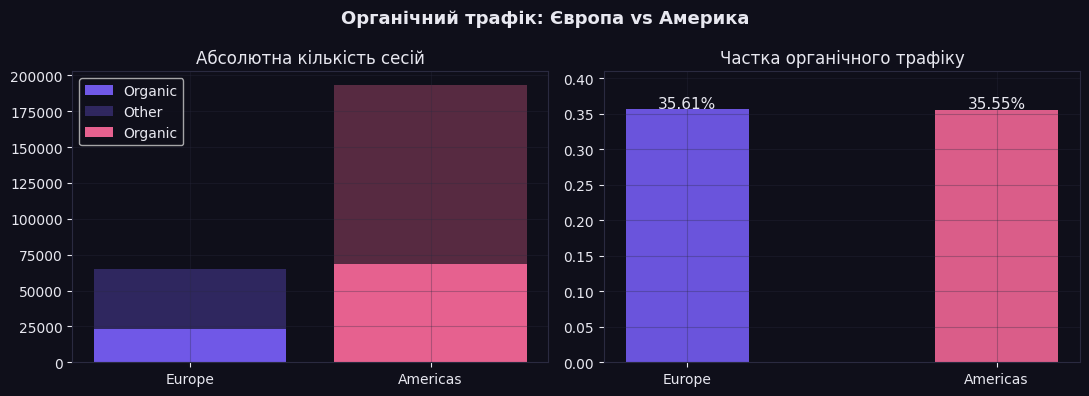

In [ ]:
# Вхідні дані: сесії по континентах
df_geo = client.query("""
    SELECT
        sp.continent,
        COUNT(*)                                                      AS total_sessions,
        COUNTIF(sp.channel = 'Organic Search')                       AS organic_sessions
    FROM `data-analytics-mate.DA.session_params` sp
    WHERE sp.continent IN ('Europe', 'Americas')
    GROUP BY 1
""").to_dataframe()

df_geo['organic_share'] = (df_geo['organic_sessions'] / df_geo['total_sessions']).round(4)
print(df_geo.to_string())

# Z-тест для двох пропорцій
from statsmodels.stats.proportion import proportions_ztest

europe   = df_geo[df_geo['continent'] == 'Europe'].iloc[0]
americas = df_geo[df_geo['continent'] == 'Americas'].iloc[0]

count = np.array([europe['organic_sessions'],   americas['organic_sessions']])
nobs  = np.array([europe['total_sessions'],      americas['total_sessions']])

stat, p = proportions_ztest(count, nobs)

print(f"\nЄвропа:  {europe['organic_sessions']:,} / {europe['total_sessions']:,} = {europe['organic_share']:.2%}")
print(f"Америка: {americas['organic_sessions']:,} / {americas['total_sessions']:,} = {americas['organic_share']:.2%}")
print(f"\nZ-тест для двох пропорцій:")
print(f"  z={stat:.4f}, p={p:.2e}")
print(f"\n{'Різниця ЗНАЧУЩА' if p < 0.05 else 'Різниця НЕ значуща'} (α=0.05)")
if p < 0.05:
    higher = 'Європа' if europe['organic_share'] > americas['organic_share'] else 'Америка'
    print(f"  Частка органічного трафіку вища у: {higher}")
    print(f"  Різниця часток: {abs(europe['organic_share'] - americas['organic_share']):.2%}")

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Органічний трафік: Європа vs Америка', fontsize=13, fontweight='bold')

# Stacked bar
for i, (row, color) in enumerate(zip(df_geo.itertuples(), ['#7B61FF', '#FF6B9D'])):
    axes[0].bar(row.continent, row.organic_sessions,   color=color,   alpha=0.9, label='Organic')
    axes[0].bar(row.continent, row.total_sessions - row.organic_sessions,
                bottom=row.organic_sessions, color=color, alpha=0.3, label='Other' if i == 0 else '')
axes[0].set_title('Абсолютна кількість сесій'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Частки
bars = axes[1].bar(df_geo['continent'], df_geo['organic_share'],
                   color=['#7B61FF', '#FF6B9D'], alpha=0.85, width=0.4)
for bar, val in zip(bars, df_geo['organic_share']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.2%}', ha='center', fontsize=11, color='#E8E8F0')
axes[1].set_title('Частка органічного трафіку')
axes[1].set_ylim(0, df_geo['organic_share'].max() * 1.15)
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

Для перевірки гіпотези щодо відмінностей у частці органічного трафіку між Європою та Америкою було використано z-тест для двох пропорцій. Результати аналізу не виявили статистично значущих відмінностей між регіонами (z = 0.29, p = 0.77). Частка органічного трафіку залишається практично однаковою в обох регіонах і становить 35.61% для Європи та 35.55% для Америки.

Отримані результати свідчать про те, що ефективність органічного каналу залучення є стабільною незалежно від географії ринку. Це дозволяє припустити, що органічний попит формується під впливом факторів, спільних для різних регіонів, а не локальних особливостей окремих ринків. З точки зору маркетингової стратегії органічний канал демонструє високу масштабованість та потенціал для подальшого розвитку без необхідності суттєвої регіональної адаптації.

## Business Insights & Recommendations

Аналіз показав, що бізнес характеризується високою концентрацією доходу на американському ринку, який виступає основним драйвером зростання за всіма ключовими показниками. Така структура забезпечує компанії стабільний обсяг продажів у короткостроковій перспективі, проте створює ризик надмірної залежності від одного регіону.

Будь-які зміни конкурентного середовища або споживчої поведінки на ринку США можуть мати непропорційно великий вплив на загальні результати компанії.При цьому аналіз міжнародних ринків виявив точки прихованого потенціалу. Тринідад і Тобаго демонструє найвищу конверсію в покупку, а Болгарія характеризується найбільшою цінністю одного замовлення. Це свідчить про наявність локальних ринків із високою ефективністю монетизації, які можуть забезпечити вищу віддачу від маркетингових інвестицій порівняно з ринками, орієнтованими виключно на масштаб.Продажі компанії значною мірою формуються меблевими категоріями високої вартості, насамперед сегментом диванів та крісел. Концентрація доходу в обмеженій кількості продуктових категорій підтверджує їхню стратегічну важливість для бізнесу та доцільність пріоритетного розподілу маркетингових і операційних ресурсів саме в цих напрямках.

Органічний трафік залишається основним джерелом продажів та забезпечує найбільший внесок у виручку компанії. Висока частка органічних замовлень свідчить про сильну присутність бренду в пошуковому середовищі та формує конкурентну перевагу завдяки нижчій вартості залучення клієнтів порівняно з платними каналами. Залежність результатів від органічного каналу водночас підкреслює важливість підтримки SEO-стратегії як одного з ключових факторів довгострокового зростання.Поведінка користувачів свідчить про переважання раціонального сценарію покупки. Більшість замовлень здійснюється через desktop-пристрої, які також демонструють найкращі показники конверсії. Це підтверджує, що процес вибору товарів потребує детального ознайомлення з продуктом і меншою мірою є імпульсною покупкою.Відсутність вираженої сезонності вказує на відносно стабільний попит протягом року та знижує ризики, пов’язані з нерівномірністю грошового потоку. Водночас майже повна відсутність повторних покупок обмежує можливості органічного зростання клієнтської бази та може свідчити про недовикористаний потенціал CRM-маркетингу, програм лояльності та механік повторного залучення клієнтів.

Найбільш неочікуваним результатом дослідження стала суттєво вища активність незареєстрованих користувачів порівняно із зареєстрованими. Отримані результати дозволяють припустити, що поточний процес створення акаунта або не формує достатньої цінності для користувача, або створює додаткові бар’єри на шляху до завершення покупки. Це є однією з найбільш перспективних зон для подальших продуктових експериментів та оптимізації конверсійної воронки.

У цілому компанія демонструє ознаки зрілого та стабільного бізнесу з передбачуваною структурою попиту, сильними позиціями в органічному каналі та чітким продуктовим ядром. Найбільший потенціал подальшого зростання пов’язаний із диверсифікацією географічної присутності, підвищенням ефективності зареєстрованих користувачів і розвитком стратегій утримання клієнтів.



Посилання на дашборди:
https://public.tableau.com/app/profile/anastasiia.postol/viz/SalesProducts_17817902257940/SalesProducts?publish=yes



https://public.tableau.com/app/profile/anastasiia.postol/viz/AudienceGeo/AudienceGeo?publish=yes
